## A kiterjesztett rprev implementáció teljesítményértékelése szintetikus adathalmazon

*Készült: 2026. március 1.*  
*Szerző: Radó László*

Ez a notebook a **„A Crouch-féle szimulációs prevalencia-becslés kiterjesztése folytonos időbeli modellezésre”** című szakdolgozat validációs anyaga.  
A dolgozat a Crouch-féle incidencia–túlélés alapú Monte Carlo szimulációs prevalenciabecslés elméleti keretére és az R csomagként telepíthető `rprev` referencia-implementációra épül. A központi feladat a referencia-eljárás több indexdátum együttes kezelésére szolgáló kiterjesztése, valamint ennek módszertani és numerikus validálása (lásd: dolgozat 3–5. fejezet).

A referencia csomag dokumentációja: https://cloud.r-project.org/web/packages/rprev/

A fentieknek megfelelően a **referencia** implementáció definíció szerint egyetlen indexdátumhoz ad prevalencia-becslést, ezért több indexdátum esetén az eredmény az rprev `prevalence()` függvényének többszörös egy-indexű függvényhívásainak sorozatából állítható elő. A **kiterjesztett implementáció** ezzel szemben több indexdátum együttes kezelésére készült, és a teljes indexrácsra konzisztens becslést ad egy közös futási keretben (lásd: 4. fejezet – referencia implementáció és a kiterjesztés tárgya; 5. fejezet – matematikai modell és csomagszintű illesztés).

### Validációs cél

Ez a notebook a dolgozat pontossági validációs részének empirikus megvalósítása. A kiértékelés saját generálású, regiszterjellegű, esetszintű szintetikus adatállományokon történik. Az adatgenerálási logikát a dolgozat `A` jelű melléklete rögzíti, ennek implementációja a `notebooks/synthetic_registry_generator.R` fájlban található, a jelen munkafüzet pedig ezt hívja meg a generáláshoz és az elemzéshez. A cél annak vizsgálata, hogy a prevalenciabecslő eljárás milyen pontossággal közelíti a valódi prevalenciát kontrollált, teljesen ismert eseménytörténetű adatkörnyezetben. A szintetikus adatkörnyezet előnye, hogy a teljes latens eseményfolyamat ismert, ezért a $\{P_{\mathrm{true}}(t_k)\}_{k=1}^K$ célmennyiség közvetlenül kiszámítható, és a becslés nem csupán egy megfigyelt regiszterkimenethez, hanem a valódi, teljes prevalenciához viszonyítható.

A munkafüzet ezért több, eltérő adatgenerálási beállítás mellett állít elő szintetikus regiszterjellegű adatokat, majd ezekben a környezetekben értékeli a becslési teljesítményt. A vizsgált szcenáriók között szerepelnek a modell szempontjából kedvezőbb, valamint szándékosan nem tökéletes specifikációs helyzetek is, hogy látható legyen, miként alakul az eljárás viselkedése eltérő incidencia-, túlélési és megfigyelési szerkezetek mellett.

### Szintetikus adatok és értékelési szempontok

A generálás eredménye esetszintű, regiszterjellegű szintetikus adatállományok családja, ahol ugyanabban a táblában egyszerre szerepelnek  
(i) a megfigyelt, cenzorálást és követésvesztést is tartalmazó regisztermezők, valamint  
(ii) a teljes, cenzorálatlan eseményfolyamatot rögzítő referencia-mezők.  
Ez teszi lehetővé annak elkülönített vizsgálatát, hogy a regiszterből közvetlenül számolható komponensek, a regisztráció kezdete diagnosztizált, valamint a követésből kiesett (LTFU) esetek miként befolyásolják a prevalenciabecslést.

A munkafüzetben először feltáró elemzést (EDA) végzünk annak bemutatására, hogy a generált adathalmazok milyen incidenciaszerkezettel, követési mintázattal és cenzorálási sajátosságokkal rendelkeznek. Ezt követően célzottan elemezzük az LTFU és a regisztráció kezdete előtti esetek hatását a regiszterből számolható prevalenciakomponensekre, majd a teljesítményértékelést a dolgozat 4.6 fejezetében rögzített kiértékelési protokoll szerint, a valódi prevalenciához viszonyított hibamutatókkal végezzük. A dolgozat specifikációjával összhangban a pontosságot a rácson vett maximális abszolút hiba ($MAE_{\max}$), az átlagos abszolút hiba ($MAE$), a négyzetes átlagos hiba ($MSE$), valamint az átlagos abszolút százalékos hiba ($MAPE$) mutatókkal jellemezzük.

### Notebook felépítése

1. Környezet és bemeneti komponensek inicializálása, majd a szintetikus adatgeneráló eljárás betöltése (`notebooks/synthetic_registry_generator.R`).
2. Több szintetikus adatállomány előállítása eltérő paraméterezés mellett, hogy a prevalenciabecslés teljesítményét különböző adatgenerálási helyzetekben vizsgálhassuk.
3. Feltáró elemzés annak bemutatására, hogy a generált adathalmazok milyen incidenciaszerkezettel, követési mintázattal és cenzorálási sajátosságokkal rendelkeznek.
4. Az LTFU és a regisztráció kezdete előtti esetek hatásának elemzése a regiszterből számolható prevalenciakomponensekre.
5. Az `rprev` becslési teljesítményének kiértékelése a valódi prevalenciához viszonyított hibamutatókkal több szcenárióban, beleértve a nem ideális modellilleszkedési helyzeteket is.

---
# Adatgenerálás, és feltáró elemzés


#### Környezet és bemeneti adatok inicializálása
- A projekt gyökérkönyvtárának azonosítása a `DESCRIPTION` fájl alapján egységestve az útvonalkezelést.
- A kiterjesztett `rprev` csomag helyi forráskódtárból történő betöltése.
- A szintetikus regiszteradatot előállító R-szkript (`notebooks/synthetic_registry_yearly.R`) betöltése.


In [35]:
# Projekt gyökérkönyvtárának meghatározása
project_root <- if (file.exists("DESCRIPTION")) {
  "."
} else if (file.exists("../DESCRIPTION")) {
  ".."
} else {
  stop("Could not find project root (DESCRIPTION).")
}

# A csomag lokális forráskódjának betöltése
suppressPackageStartupMessages(devtools::load_all(project_root, quiet = TRUE))
cat("Loaded rprev from: ", normalizePath(getNamespaceInfo("rprev", "path"), winslash = "/"), "\n", sep = "")

# Szintetikus, éves bontású regiszteradatot előállító szkript betöltése
source(file.path(project_root, "notebooks", "synthetic_registry_generator.R"))


Loaded rprev from: C:/Users/600972868/OneDrive - BT Plc/Desktop/Sajat Mappa/00 - BGE/Alkalmazott Matematika/Szakdolgozat/repo/rprev-ext


#### Verzióazonosítás (Git ág és commit)
- A Git-ág és a commit-azonosító kijelzése azonosítja az aktuális kódváltozatot.


In [36]:
# Git meta (branch + commit) kiírása
git_cmd <- function(cmd) {
  out <- tryCatch(
    system(cmd, intern = TRUE, ignore.stderr = TRUE),
    error = function(e) character(0)
  )
  if (length(out) == 0) NA_character_ else out[[1]]
}

# Git ág és commit azonosító lekérdezése a projekt gyökerére hivatkozva
branch <- git_cmd(paste("git -C", shQuote(project_root), "rev-parse --abbrev-ref HEAD"))
commit <- git_cmd(paste("git -C", shQuote(project_root), "rev-parse HEAD"))

cat("Git branch: ", branch, "\n", sep = "")
cat("Git commit: ", commit, "\n", sep = "")


Git branch: notebooks/performance-evaluation
Git commit: 023215653c67dd8996fb5fab64d54720085c23e3


#### Központi konfigurációs blokk
- A következő blokkban a notebook egészére érvényes alapbeállításokat rögzítjük: betöltjük a szükséges csomagokat, egységesítjük az ábrák szín- és méretbeállításait, valamint definiáljuk a közös plotting segédfüggvényeket.

In [37]:
# Központi notebook-konfiguráció (importok, színek, plot alapbeállítások)
options(stringsAsFactors = FALSE)

# A notebook egészében használt csomagok adatkezeléshez, ábrázoláshoz és layoutoláshoz
required_pkgs <- c("dplyr", "ggplot2", "survival", "knitr", "patchwork")
invisible(lapply(required_pkgs, function(pkg) {
  suppressPackageStartupMessages(require(pkg, character.only = TRUE))
}))

# Központi vizuális alapbeállítások az egységes ábrastílushoz
analysis_config <- list(
  # Gyakran újrahasznált elsődleges ábraszínek
  colors = list(
    main = "#00BFC4",
    alt = "#d48f90",
    neutral = "grey50"
  ),
  # Alap betűméretek a ggplot témákhoz
  base_size = list(
    standard = 14,
    large = 16,
    small = 13
  ),
  # Elem-specifikus betűméretek címekhez, tengelyekhez és jelmagyarázatokhoz
  text_size = list(
    plot_title = 16,
    plot_subtitle = 13,
    axis_title = 14,
    axis_text = 13,
    legend_title = 15,
    legend_text = 14,
    strip_text = 12
  ),
  # Gyakran használt ábraméretek hüvelykben
  plot_size = list(
    wide = c(14, 7),
    wide_tall = c(14, 8),
    box = c(18, 10),
    km = c(14, 10),
    compact = c(9, 7),
    timeseries = c(12, 6)
  ),
  # Névesített paletták egyes ábratípusokhoz
  palette = list(
    km_age_band = "Dark 3"
  )
)

# Segédfüggvény az IRkernel megjelenített ábraméretének beállításához
set_plot_size <- function(width, height) {
  options(repr.plot.width = width, repr.plot.height = height)
}


# Közös ggplot-téma a központi betűméret-beállításokkal
notebook_theme <- function(base_size = analysis_config$base_size$standard) {
  ggplot2::theme_minimal(base_size = base_size) +
    ggplot2::theme(
      plot.title = ggplot2::element_text(
        size = analysis_config$text_size$plot_title,
        face = "bold"
      ),
      plot.subtitle = ggplot2::element_text(
        size = analysis_config$text_size$plot_subtitle
      ),
      axis.title = ggplot2::element_text(
        size = analysis_config$text_size$axis_title
      ),
      axis.text = ggplot2::element_text(
        size = analysis_config$text_size$axis_text
      ),
      legend.title = ggplot2::element_text(
        size = analysis_config$text_size$legend_title
      ),
      legend.text = ggplot2::element_text(
        size = analysis_config$text_size$legend_text
      ),
      strip.text = ggplot2::element_text(
        size = analysis_config$text_size$strip_text
      )
    )
}


#### Szintetikus adatgenerálás paraméterezése
- Az alapparaméterezés rögzítése, majd az ettől eltérő szcenáriók felülíró listáinak megadása.
- A szintetikus regiszteradat előállítása és gyors ellenőrzése


In [38]:
# Szintetikus adatgenerálás közös alap paraméterbeállításai
params <- list(
  # Időpontok és időablakok
  t_orig = "1990-01-01",
  t_min = "2000-01-01",
  t_max = "2025-01-01",
  t_end = "2026-12-31",

  # Éves incidenciatrend paraméterei
  inc_lam0 = 950,
  inc_g = 0.00,
  inc_sdlog = 0.00,
  strict_calendar_bounds = TRUE,

  # Kovariánsok generálása
  p_x1 = 0.42,
  beta_a_x1 = c(3.5, 3.0),
  beta_b_x1 = c(3.0, 3.5),
  x2_range = c(20, 90),
  x3_mu = c(-0.2, 0.5, 0.03),
  x3_sd = 1.2,

  # Túlélési modell paraméterei
  gg_lam = 2400,
  gg_k   = 2.2,
  gg_b   = c(-1.3, 0.035, 0.7),
  gg_q   = 0.2,

  # Cenzorálási arány (LTFU)
  p_ltfu = 0.0,

  # Reprodukálhatóság
  seed = 20260213
)

# Különböző paraméterscenáriók definiálása, és szcenáriónkénti felülírások az alapparaméterekhez
# d1: idealis, d2: non-Weibull + x3, d3: non-Weibull + x3 + inhomogen, d4-a/b/c: homogen + LTFU, d5: non-Weibull + x3 + inhomogen + LTFU 1%
scenario_overrides <- list(
  d1 = list(
    gg_q = 1.0,
    gg_b = c(-1.3, 0.035, 0.0),
    x3_mu = c(-0.2, 0.0, 0.0)
  ),
  d2 = list(
    gg_q = 0.05,
    gg_b = c(-1.3, 0.035, 1.7),
    x3_mu = c(-0.2, 0.5, 0.03)
  ),
  d3 = list(
    gg_q = 0.05,
    gg_b = c(-1.3, 0.035, 1.7),
    x3_mu = c(-0.2, 0.5, 0.03),
    inc_g = -0.01
  ),
  `d4-a` = list(
    gg_q = 0.05,
    gg_b = c(-1.3, 0.035, 1.7),
    x3_mu = c(-0.2, 0.5, 0.03),
    p_ltfu = 0.01
  ),
  `d4-b` = list(
    gg_q = 0.05,
    gg_b = c(-1.3, 0.035, 1.7),
    x3_mu = c(-0.2, 0.5, 0.03),
    p_ltfu = 0.05
  ),
  `d4-c` = list(
    gg_q = 0.05,
    gg_b = c(-1.3, 0.035, 1.7),
    x3_mu = c(-0.2, 0.5, 0.03),
    p_ltfu = 0.10
  ),
  d5 = list(
    gg_q = 0.05,
    gg_b = c(-1.3, 0.035, 1.7),
    x3_mu = c(-0.2, 0.5, 0.03),
    inc_g = -0.01,
    p_ltfu = 0.01
  )

)

# Szenárióparaméterek előállítása az alapbeállítások felülírásával
build_params <- function(defaults, overrides) {
  modifyList(defaults, overrides)
}

# Szintetikus regiszteradat előállítása minden scenárióra, név szerint eltárolva
synthetic_registry_list <- setNames(
  lapply(names(scenario_overrides), function(scn) {
    scenario_params <- build_params(params, scenario_overrides[[scn]])
    do.call(generate_synthetic_registry_yearly, scenario_params)
  }),
  names(scenario_overrides)
)

# Scenáriók összevonása egy táblába, scenárióazonosító oszloppal
synthetic_registry_all <- do.call(
  rbind,
  lapply(names(synthetic_registry_list), function(scn) {
    x <- synthetic_registry_list[[scn]]
    x$scenario_id <- scn
    x
  })
)
rownames(synthetic_registry_all) <- NULL

# Visszafelé kompatibilitás a későbbi cellákhoz (alap scenárió)
synthetic_registry <- synthetic_registry_list[["d2"]]

# Elemszám és első sorok megjelenítése
cat("Generált scenáriók:", paste(names(synthetic_registry_list), collapse = ", "), "\n")
scenario_counts <- data.frame(
  scenario = names(synthetic_registry_list),
  rows = vapply(synthetic_registry_list, nrow, integer(1)),
  stringsAsFactors = FALSE
)
print(scenario_counts, row.names = FALSE)
head(synthetic_registry, 5)

# write.csv(synthetic_registry, "prevalence_summary.csv", row.names = FALSE)


Generált scenáriók: d1, d2, d3, d4-a, d4-b, d4-c, d5 
 scenario  rows
       d1 23693
       d2 23693
       d3 21053
     d4-a 23693
     d4-b 23693
     d4-c 23693
       d5 21053


,case_id_id,diagnosis_date_D,covariate_binary_x1,covariate_scaled_x2,covariate_hidden_x3,last_followup_date_F,event_observed_delta,true_event_date_F_true,true_event_indicator_delta_true
,<int>,<date>,<int>,<dbl>,<dbl>,<date>,<int>,<date>,<int>
1,1,2013-01-04,0,76.22123,2.2099616,2013-08-01,1,2013-08-01,1
2,2,2019-07-11,0,62.15612,2.0551941,2019-10-29,1,2019-10-29,1
3,3,2013-03-28,0,69.20825,2.1447607,2013-12-27,1,2013-12-27,1
4,4,2006-01-21,0,62.70321,0.4823187,2007-01-26,1,2007-01-26,1
5,5,2012-09-03,0,58.34325,1.7395451,2013-02-15,1,2013-02-15,1


#### Származtatott változók előállítása
- A kovariánsok egységes jelölésének kialakítása (x1–x3) és a bináris változó faktorosítása.
- Életkor- és időtartamváltozók képzése dátumkülönbségekből (follow-up és true túlélési idő).


In [39]:
# EDA munkatáblázat létrehozása
df_eda_all <- synthetic_registry_all
df_eda_all$scenario_id <- df_eda_all$scenario_id

# Kovariánsok egységes jelölése
df_eda_all$x1 <- df_eda_all$covariate_binary_x1
df_eda_all$x2 <- df_eda_all$covariate_scaled_x2
df_eda_all$x3 <- df_eda_all$covariate_hidden_x3

# Bináris kovariáns faktorosítása olvasható címkékkel
df_eda_all$x1_fac <- factor(df_eda_all$x1, levels = c(0, 1), labels = c("X1=0", "X1=1"))

# Valós eseménykori életkor előállítása (diagnózis kori életkor + túlélési idő években)
df_eda_all$age_at_death_true <- df_eda_all$x2 +
  as.numeric(as.Date(df_eda_all$true_event_date_F_true) - as.Date(df_eda_all$diagnosis_date_D)) / 365.25

# Követési idő napokban (utolsó ismert kontaktus - diagnózis)
df_eda_all$followup_days <- as.numeric(df_eda_all$last_followup_date_F - df_eda_all$diagnosis_date_D)

# Valós túlélési idő napokban (valódi eseményidő - diagnózis)
df_eda_all$true_survival_days <- as.numeric(df_eda_all$true_event_date_F_true - df_eda_all$diagnosis_date_D)

# Scenáriók beállítása az EDA-hoz
df_eda_d1_idealis <- df_eda_all[df_eda_all$scenario_id == "d1", ]
df_eda_d2_nonweibull_x3 <- df_eda_all[df_eda_all$scenario_id == "d2", ]
df_eda_d3_nonweibull_x3_inhomogen <- df_eda_all[df_eda_all$scenario_id == "d3", ]
df_eda_d4_a_homogen_ltfu_1 <- df_eda_all[df_eda_all$scenario_id == "d4-a", ]
df_eda_d4_b_homogen_ltfu_5 <- df_eda_all[df_eda_all$scenario_id == "d4-b", ]
df_eda_d4_c_homogen_ltfu_10 <- df_eda_all[df_eda_all$scenario_id == "d4-c", ]
df_eda_d5_inhomogen_ltfu_1 <- df_eda_all[df_eda_all$scenario_id == "d5", ]
df_eda <- df_eda_d2_nonweibull_x3


#### Szintetikus adatok CSV exportja
- A szcenáriónként előállított adatállományokat külön CSV-fájlokba írjuk ki, hogy egy későbbi, külön notebook közvetlenül ezekből tudjon dolgozni.

In [40]:
# Kimeneti mappa létrehozása
csv_dir <- file.path(project_root, "notebooks", "synthetic_registry_csv")
dir.create(csv_dir, showWarnings = FALSE)

# Szcenáriónkénti CSV-k kiírása
invisible(lapply(names(synthetic_registry_list), function(scn) {
  write.csv(
    synthetic_registry_list[[scn]],
    file.path(csv_dir, paste0(scn, ".csv")),
    row.names = FALSE
  )
}))

names(synthetic_registry_list)


[1] "d1"   "d2"   "d3"   "d4-a" "d4-b" "d4-c" "d5"

#### Szintetikus adatok visszaolvasása CSV exportból
- A korábban exportált, előre rögzített nevű CSV-fájlokat ugyanabba a listastruktúrába olvassuk vissza.

In [41]:
# CSV-fájlnevek rögzítése
csv_files <- c(
  d1 = "d1.csv",
  d2 = "d2.csv",
  d3 = "d3.csv",
  `d4-a` = "d4-a.csv",
  `d4-b` = "d4-b.csv",
  `d4-c` = "d4-c.csv",
  d5 = "d5.csv"
)

# Oszloptípusok rögzítése
date_cols <- c("diagnosis_date_D", "last_followup_date_F", "true_event_date_F_true")
integer_cols <- c("case_id_id", "covariate_binary_x1", "event_observed_delta", "true_event_indicator_delta_true")
numeric_cols <- c("covariate_scaled_x2", "covariate_hidden_x3")

# Szcenáriónkénti CSV-k visszaolvasása
synthetic_registry_list <- setNames(
  lapply(names(csv_files), function(scn) {
    df <- read.csv(
      file.path(csv_dir, csv_files[[scn]]),
      stringsAsFactors = FALSE
    )

    # Oszloptípusok visszaállítása
    df[date_cols] <- lapply(df[date_cols], as.Date)
    df[integer_cols] <- lapply(df[integer_cols], as.integer)
    df[numeric_cols] <- lapply(df[numeric_cols], as.numeric)

    df
  }),
  names(csv_files)
)

# Összefűzött objektumok újraépítése
synthetic_registry_all <- do.call(
  rbind,
  lapply(names(synthetic_registry_list), function(scn) {
    x <- synthetic_registry_list[[scn]]
    x$scenario_id <- scn
    x
  })
)
rownames(synthetic_registry_all) <- NULL
synthetic_registry <- synthetic_registry_list[[1]]

names(synthetic_registry_list)


[1] "d1"   "d2"   "d3"   "d4-a" "d4-b" "d4-c" "d5"

#### Leíró statisztikák
- Az x1–x3 kovariánsok, a valós túlélési idő, a követési idő és a valós eseménykori életkor alapstatisztikáinak áttekintése.


In [42]:
# Leíró statisztikák táblázata a kiválasztott változókra (több adathalmazra)
summarize_eda_stats <- function(
  data_list,
  vars = c("x1", "x2", "x3", "true_survival_days", "followup_days", "age_at_death_true"),
  digits = 1
) {
  # Summary-táblák előállítása minden adathalmazra
  out <- lapply(names(data_list), function(nm) {
    as.data.frame(sapply(data_list[[nm]][vars], summary))
  })
  names(out) <- names(data_list)

  # Táblák kiírása scenáriónként
  for (nm in names(out)) {
    cat("\n", nm, "\n", sep = "")
    print(knitr::kable(out[[nm]], digits = digits))
  }
    out
}

# Alap scenárió összegzése (listaformában)
sum_tab <- summarize_eda_stats(list(
  "d1: idealis" = df_eda_d1_idealis,
  "d2: non-Weibull + x3" = df_eda_d2_nonweibull_x3,
  "d3: non-Weibull + x3 + inhomogen" = df_eda_d3_nonweibull_x3_inhomogen,
  "d4-a: homogen + LTFU 1%" = df_eda_d4_a_homogen_ltfu_1,
  "d4-b: homogen + LTFU 5%" = df_eda_d4_b_homogen_ltfu_5,
  "d4-c: homogen + LTFU 10%" = df_eda_d4_c_homogen_ltfu_10,
  "d5: non-Weibull + x3 + inhomogen + LTFU 1%" = df_eda_d5_inhomogen_ltfu_1
), digits = 1)



d1: idealis


|        |  x1|   x2|   x3| true_survival_days| followup_days| age_at_death_true|
|:-------|---:|----:|----:|------------------:|-------------:|-----------------:|
|Min.    | 0.0| 21.9| -4.7|               20.0|          20.0|              23.7|
|1st Qu. | 0.0| 45.8| -1.0|              646.0|         646.0|              49.8|
|Median  | 0.0| 55.5| -0.2|             1031.0|        1006.0|              58.8|
|Mean    | 0.4| 55.5| -0.2|             1216.5|        1172.6|              58.8|
|3rd Qu. | 1.0| 65.2|  0.6|             1585.0|        1514.0|              67.9|
|Max.    | 1.0| 89.1|  4.4|             7215.0|        7215.0|              90.9|

d2: non-Weibull + x3


|        |  x1|   x2|   x3| true_survival_days| followup_days| age_at_death_true|
|:-------|---:|----:|----:|------------------:|-------------:|-----------------:|
|Min.    | 0.0| 21.9| -3.1|                3.0|           3.0|              23.6|
|1st Qu. | 0.0| 45.8|  0.8|              157.0|         157

#### Diagnóziskori életkor eloszlása nemenként
- A diagnóziskori életkor eloszlásának összevetése nemek szerint.
- A csoport-mediánok kijelzése a középértékek gyors összehasonlításához.


In [43]:
# Diagnóziskori életkor hisztogramja nemenként (több adathalmazra)
plot_age_dx_hist_by_sex <- function(data_list, bins = 40) {

  # Ábrák előállítása scenáriónként, név szerinti listában
  out <- lapply(names(data_list), function(nm) {

    # Ábrához szükséges változók előállítása és tisztítása (életkor, nem)
    df_plot <- data_list[[nm]] %>%
      dplyr::transmute(
        age_at_dx = x2,
        sex = factor(x1, levels = c(0, 1), labels = c("Nő", "Férfi"))
      ) %>%
      dplyr::filter(is.finite(age_at_dx), !is.na(sex))

    # Medián életkor számítása nemenként, feliratok előkészítésével
    med <- df_plot %>%
      dplyr::group_by(sex) %>%
      dplyr::summarise(med = median(age_at_dx, na.rm = TRUE), .groups = "drop") %>%
      dplyr::arrange(sex) %>%
      dplyr::mutate(
        label = paste0(sex, ": medián = ", round(med, 1), " év"),
        vj = 1 + 1.2 * (dplyr::row_number() - 1)
      )

    # Ábra: hisztogram nemenként, medián vonalakkal és feliratokkal
    ggplot(df_plot, aes(x = age_at_dx, fill = sex)) +
      geom_histogram(
        aes(y = after_stat(density)),
        bins = bins, position = "identity", alpha = 0.45
      ) +
      geom_vline(
        data = med, aes(xintercept = med, color = sex),
        linewidth = 1.1, show.legend = FALSE
      ) +
      geom_label(
        data = med,
        aes(x = Inf, y = Inf, label = label, color = sex, vjust = vj),
        inherit.aes = FALSE,
        hjust = 1.02, label.size = 0, fill = "white",
        alpha = 0.85, size = 5, show.legend = FALSE
      ) +
      coord_cartesian(clip = "off") +
      notebook_theme(base_size = analysis_config$base_size$standard) +
      labs(
        title = paste0("Diagnóziskori életkor eloszlása nemenként - ", nm),
        x = "Életkor a diagnózisnál (év)",
        y = "Sűrűség",
        fill = "Nem"
      )
  })

  # Kimenet: név szerinti ábralista
  names(out) <- names(data_list)
  out
}

# Ábraméret beállítása
set_plot_size(analysis_config$plot_size$wide[1], analysis_config$plot_size$wide[2])

# Ábrák előállítása két scenárióra
age_dx_hist_plots <- plot_age_dx_hist_by_sex(
  list(
    "d1: idealis" = df_eda_d1_idealis,
    "d2: non-Weibull + x3" = df_eda_d2_nonweibull_x3,
    "d3: non-Weibull + x3 + inhomogen" = df_eda_d3_nonweibull_x3_inhomogen,
    "d4-a: homogen + LTFU 1%" = df_eda_d4_a_homogen_ltfu_1,
    "d4-b: homogen + LTFU 5%" = df_eda_d4_b_homogen_ltfu_5,
    "d4-c: homogen + LTFU 10%" = df_eda_d4_c_homogen_ltfu_10,
    "d5: non-Weibull + x3 + inhomogen + LTFU 1%" = df_eda_d5_inhomogen_ltfu_1
  ),
  bins = 40
)

# Ábrák megjelenítése
invisible(lapply(names(age_dx_hist_plots), function(nm) age_dx_hist_plots[[nm]]))


#### Diagnózis esetszámok év szerint
- A diagnózis évének képzése és az éves esetszámok összesítése.
- Nemlineáris trend illesztése (LOESS) az idősor áttekintéséhez.


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


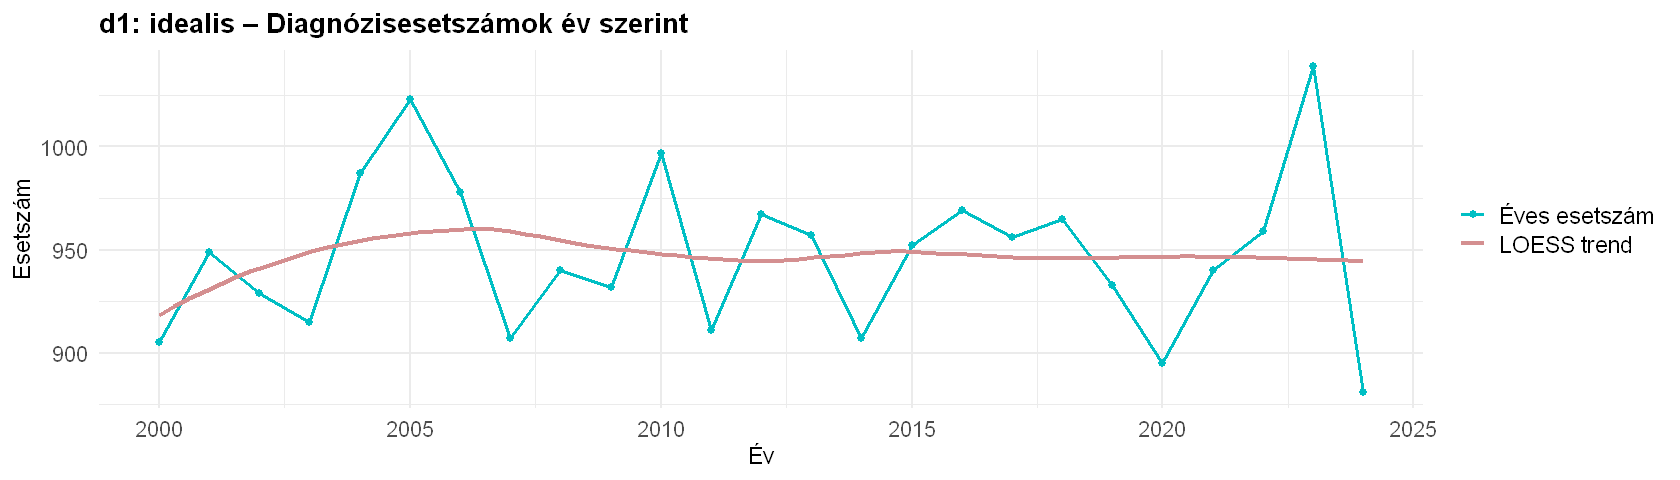

`geom_smooth()` using formula = 'y ~ x'


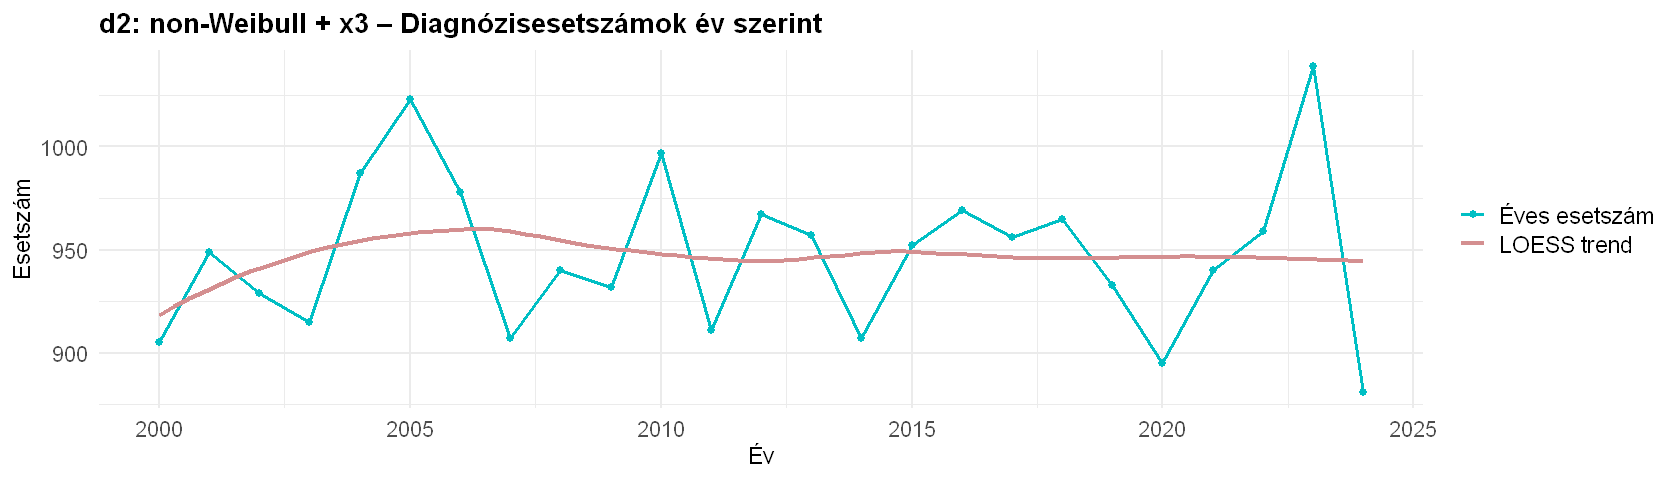

`geom_smooth()` using formula = 'y ~ x'


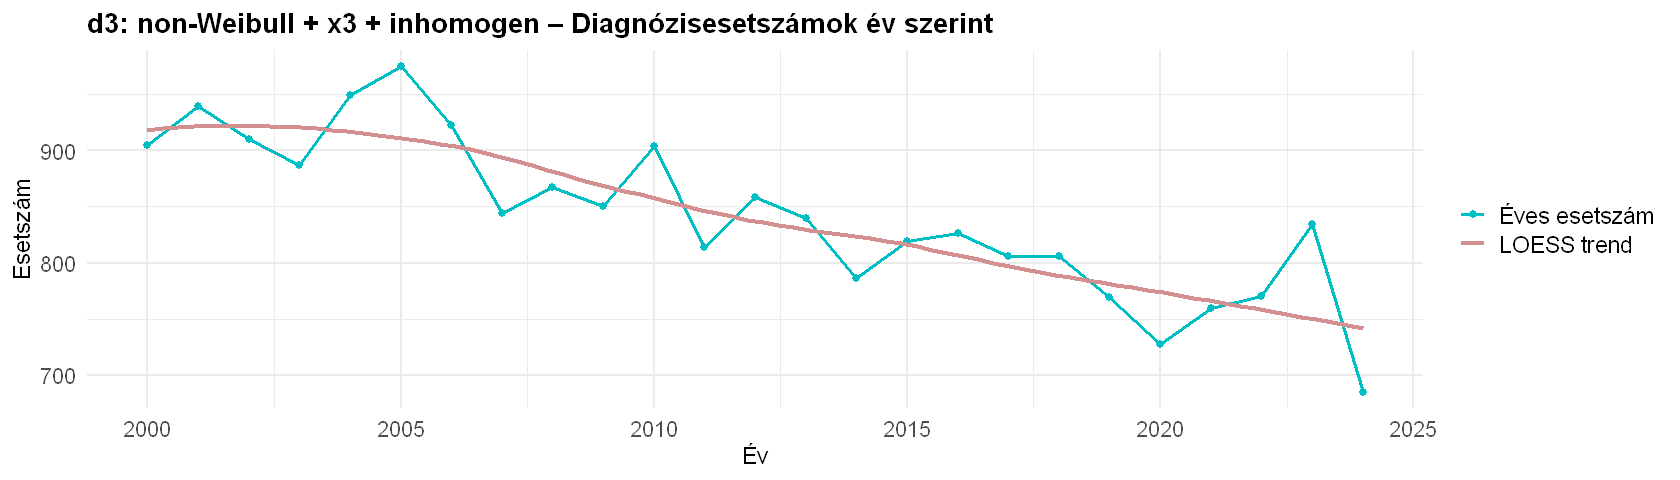

`geom_smooth()` using formula = 'y ~ x'


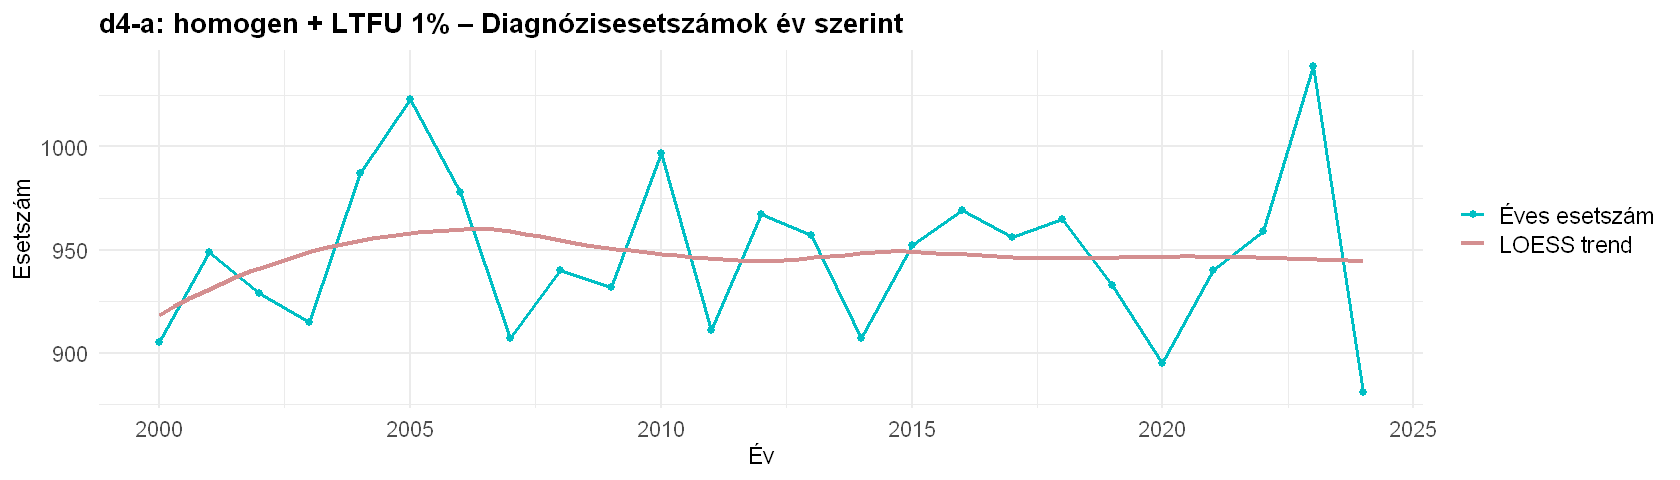

`geom_smooth()` using formula = 'y ~ x'


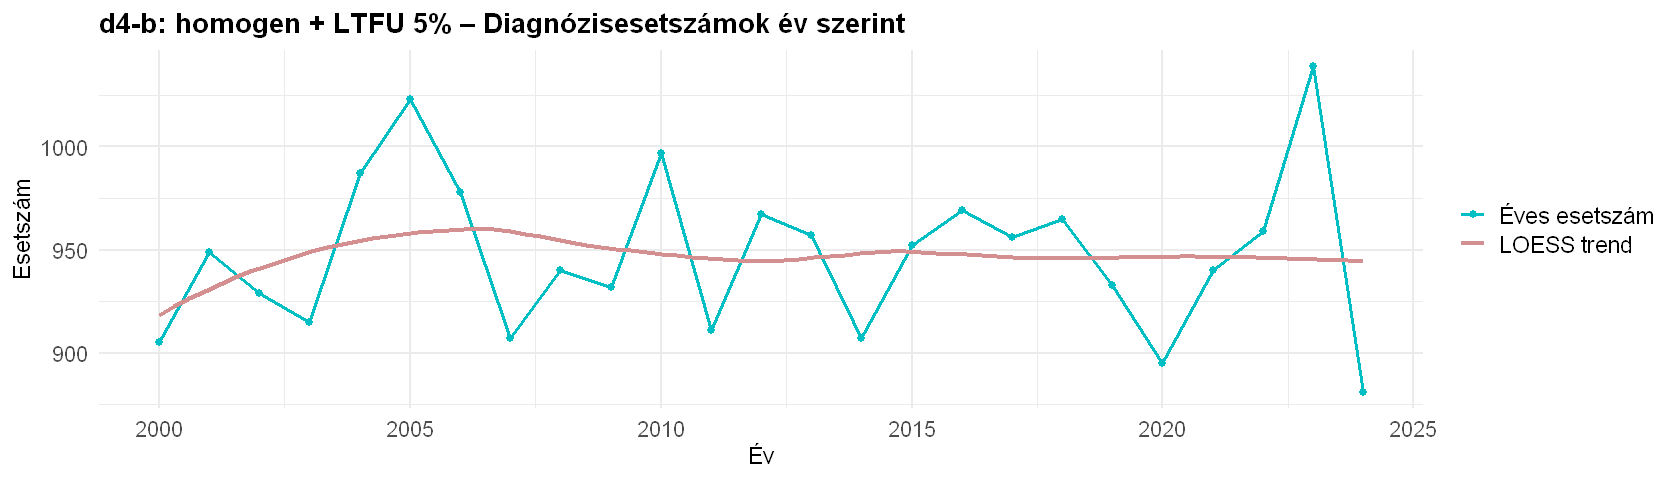

`geom_smooth()` using formula = 'y ~ x'


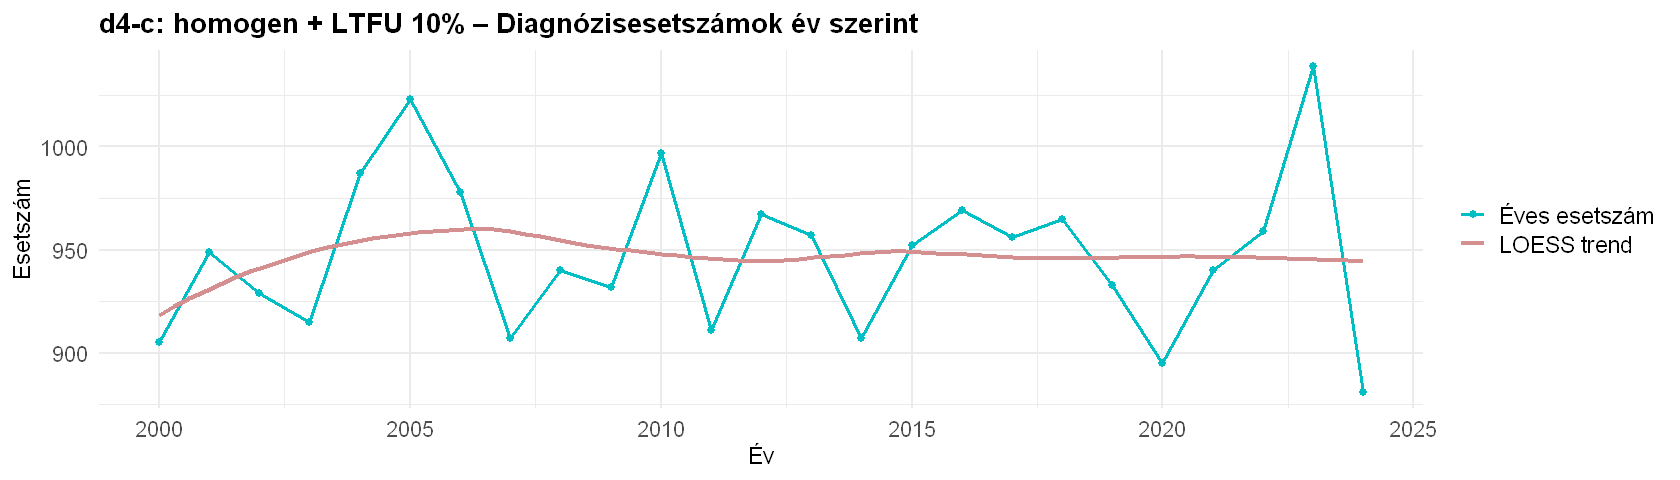

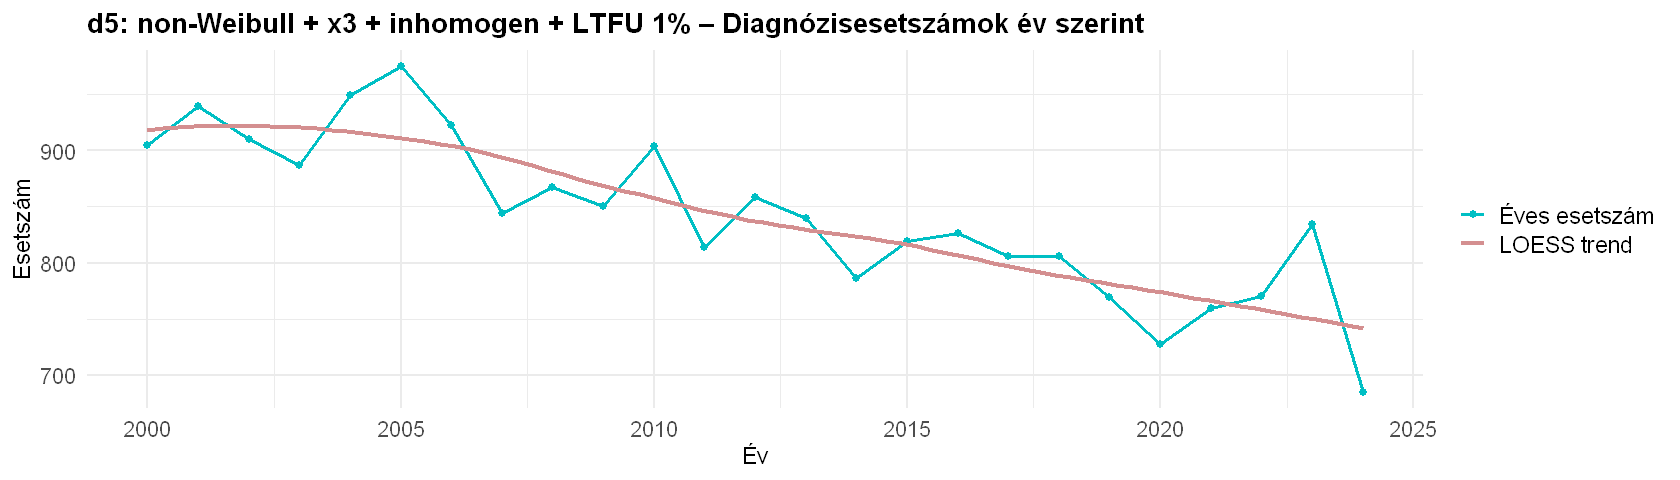

In [44]:
# Éves diagnózisszámok ábrázolása (több adathalmazra)
plot_yearly_diagnosis_counts <- function(data_list) {

  # Ábrák előállítása scenáriónként
  out <- lapply(names(data_list), function(nm) {

    # Diagnózis évének képzése és az éves esetszámok összesítése
    inc_counts <- data_list[[nm]] %>%
      transmute(year = as.integer(format(diagnosis_date_D, "%Y"))) %>%
      count(year, name = "n") %>%
      arrange(year)

    # Ábra: éves esetszám + nemlineáris (LOESS) trend
    p <- ggplot(inc_counts, aes(x = year)) +
      geom_line(aes(y = n, color = "Éves esetszám"), linewidth = 1) +
      geom_point(aes(y = n, color = "Éves esetszám"), size = 2) +
      geom_smooth(aes(y = n, color = "LOESS trend"),
                  method = "loess", se = FALSE, linewidth = 1.2) +
      scale_color_manual(values = c("Éves esetszám" = analysis_config$colors$main, "LOESS trend" = analysis_config$colors$alt)) +
      notebook_theme(base_size = analysis_config$base_size$standard) +
      labs(
        title = paste0(nm, " – Diagnózisesetszámok év szerint"),
        x = "Év",
        y = "Esetszám",
        color = NULL
      )

    print(p)
    p
  })

  # Kimenet: név szerinti ábralista
  names(out) <- names(data_list)
  out
}

set_plot_size(14,4)

incidence_plots <- plot_yearly_diagnosis_counts(
  list(
    "d1: idealis" = df_eda_d1_idealis,
    "d2: non-Weibull + x3" = df_eda_d2_nonweibull_x3,
    "d3: non-Weibull + x3 + inhomogen" = df_eda_d3_nonweibull_x3_inhomogen,
    "d4-a: homogen + LTFU 1%" = df_eda_d4_a_homogen_ltfu_1,
    "d4-b: homogen + LTFU 5%" = df_eda_d4_b_homogen_ltfu_5,
    "d4-c: homogen + LTFU 10%" = df_eda_d4_c_homogen_ltfu_10,
    "d5: non-Weibull + x3 + inhomogen + LTFU 1%" = df_eda_d5_inhomogen_ltfu_1
  )
)

invisible(lapply(names(incidence_plots), function(nm) incidence_plots[[nm]]))


#### Valós túlélési idők boxplot diagramjai
- A valós túlélési idő eloszlásának áttekintése összesen és X1 szerint.
- A csoportkülönbségek gyors vizuális ellenőrzése dobozdiagrammal.


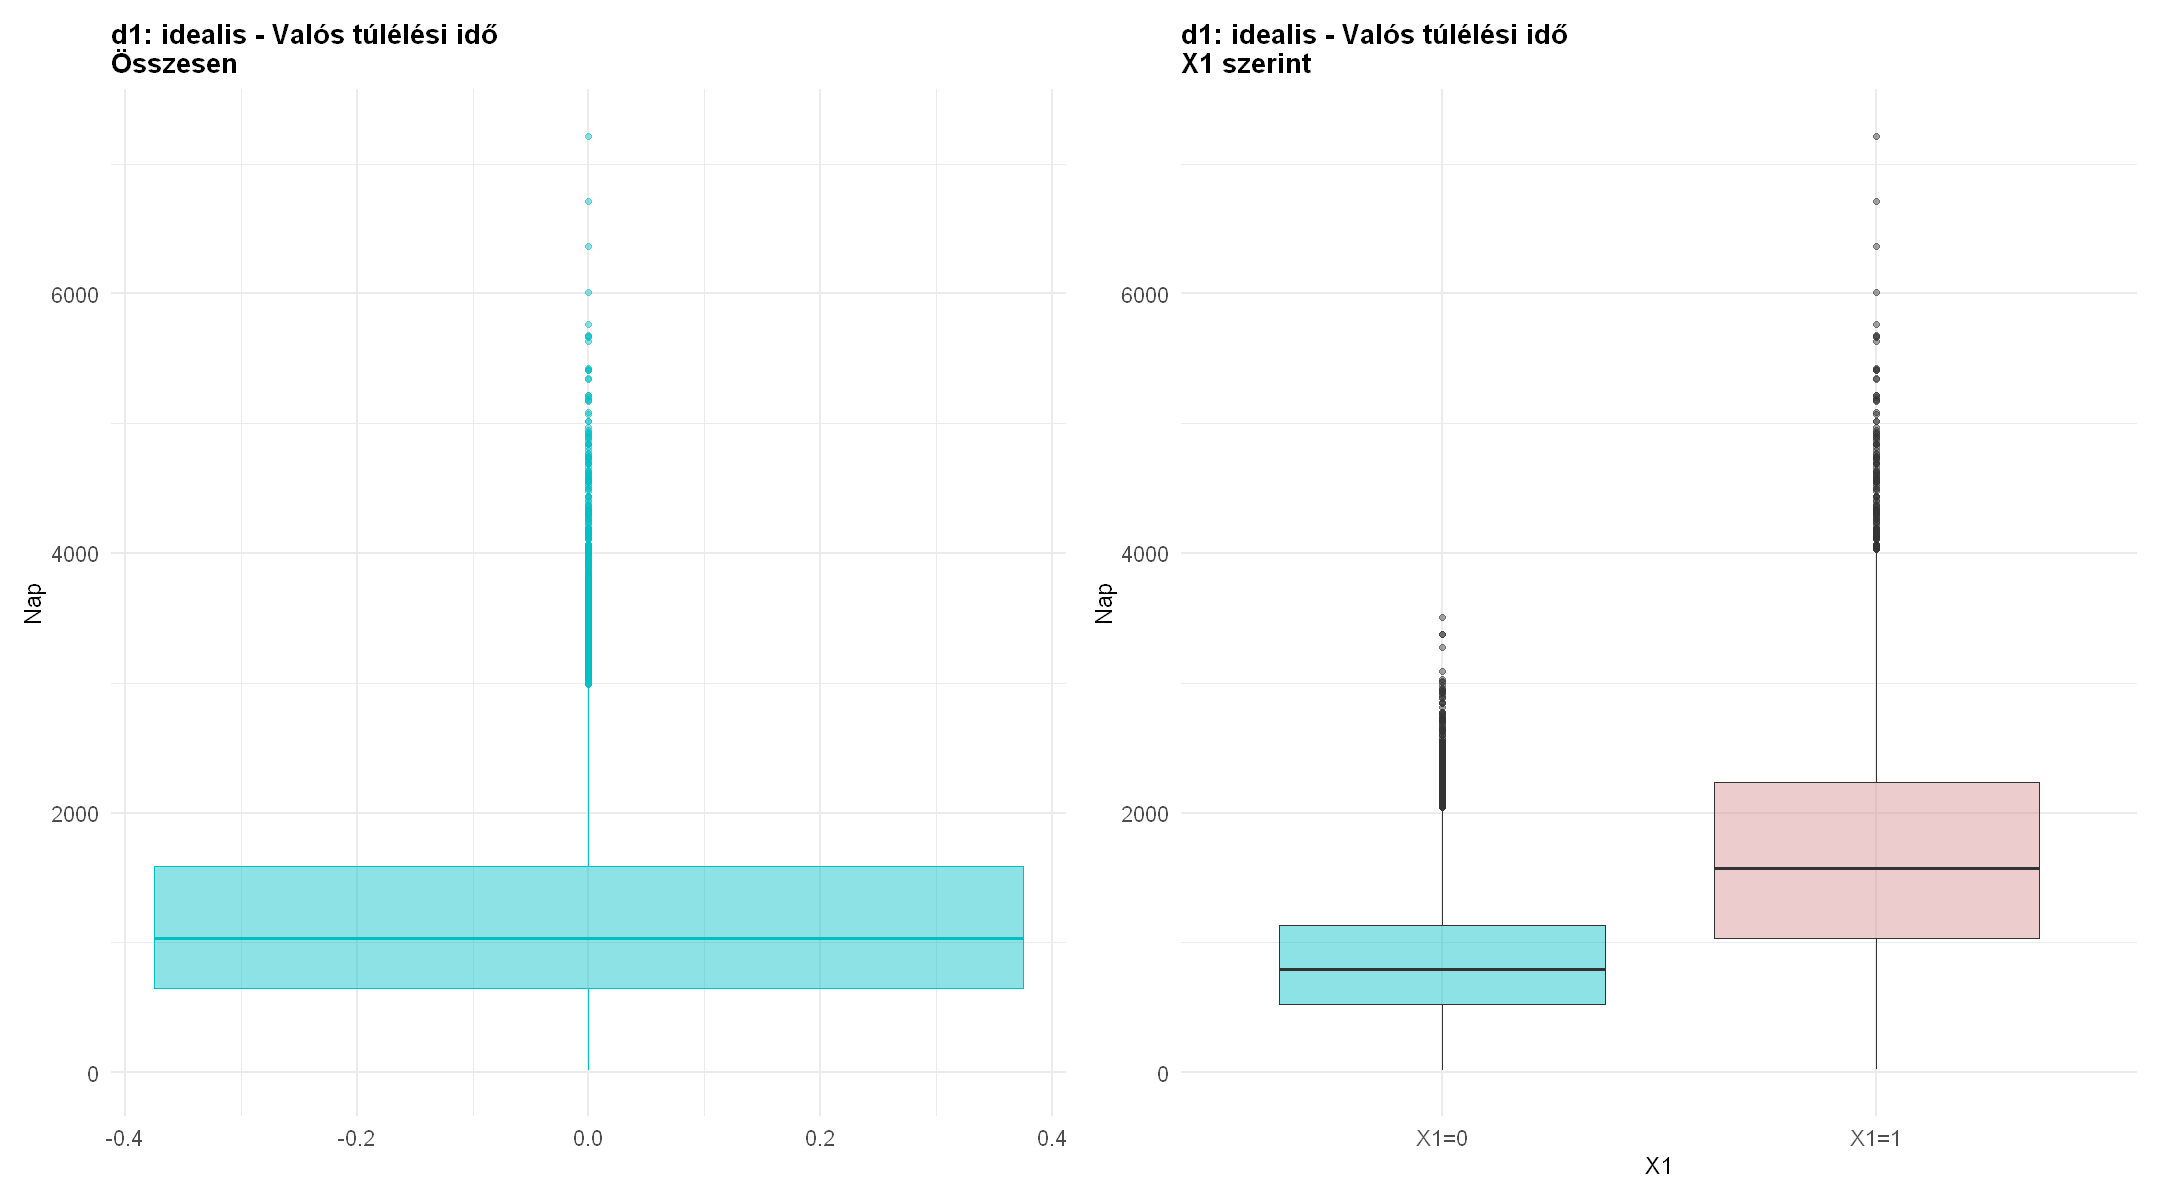

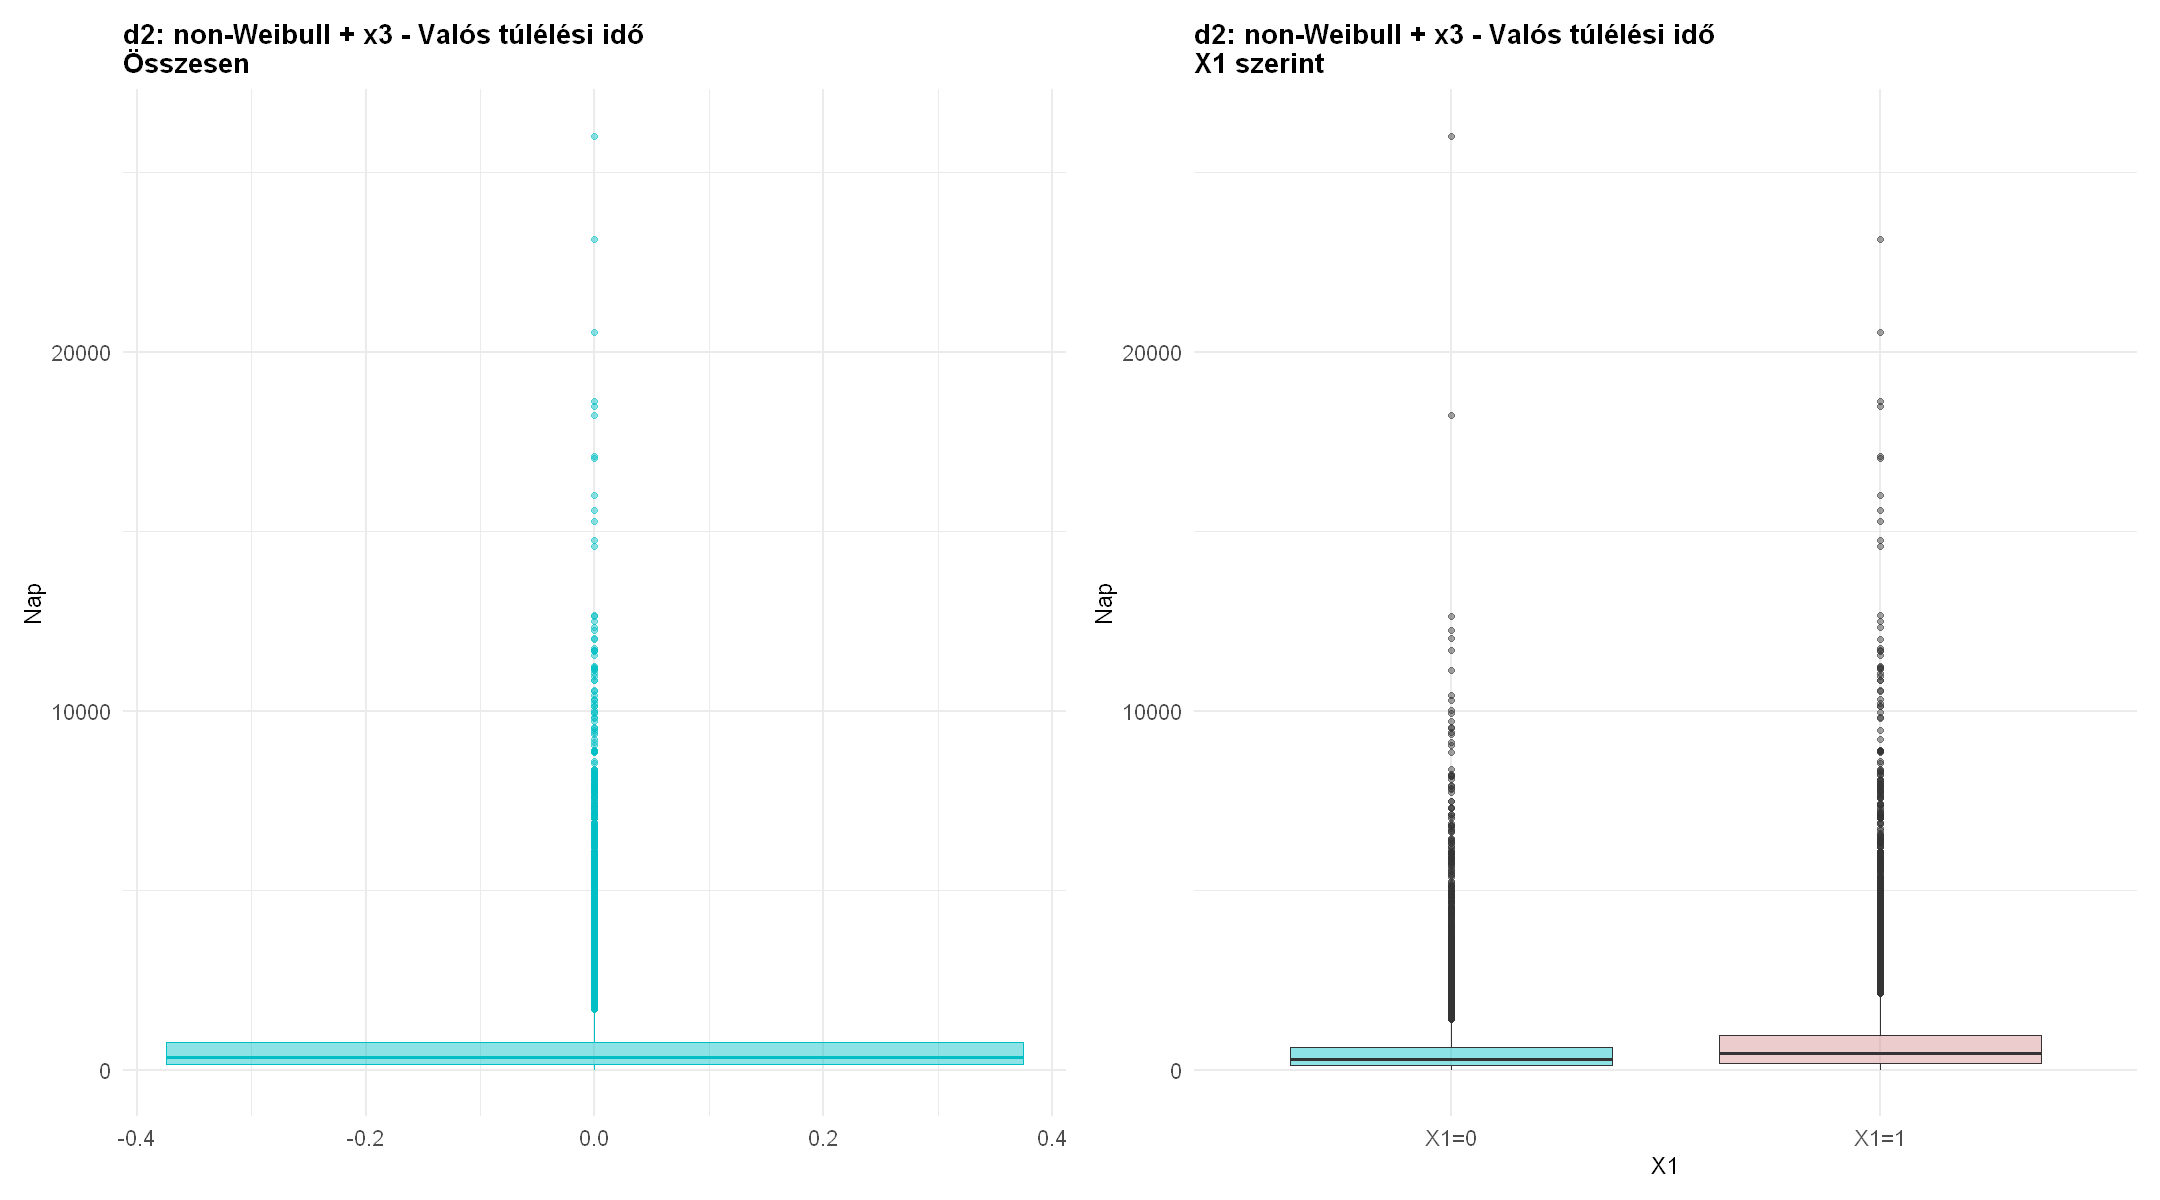

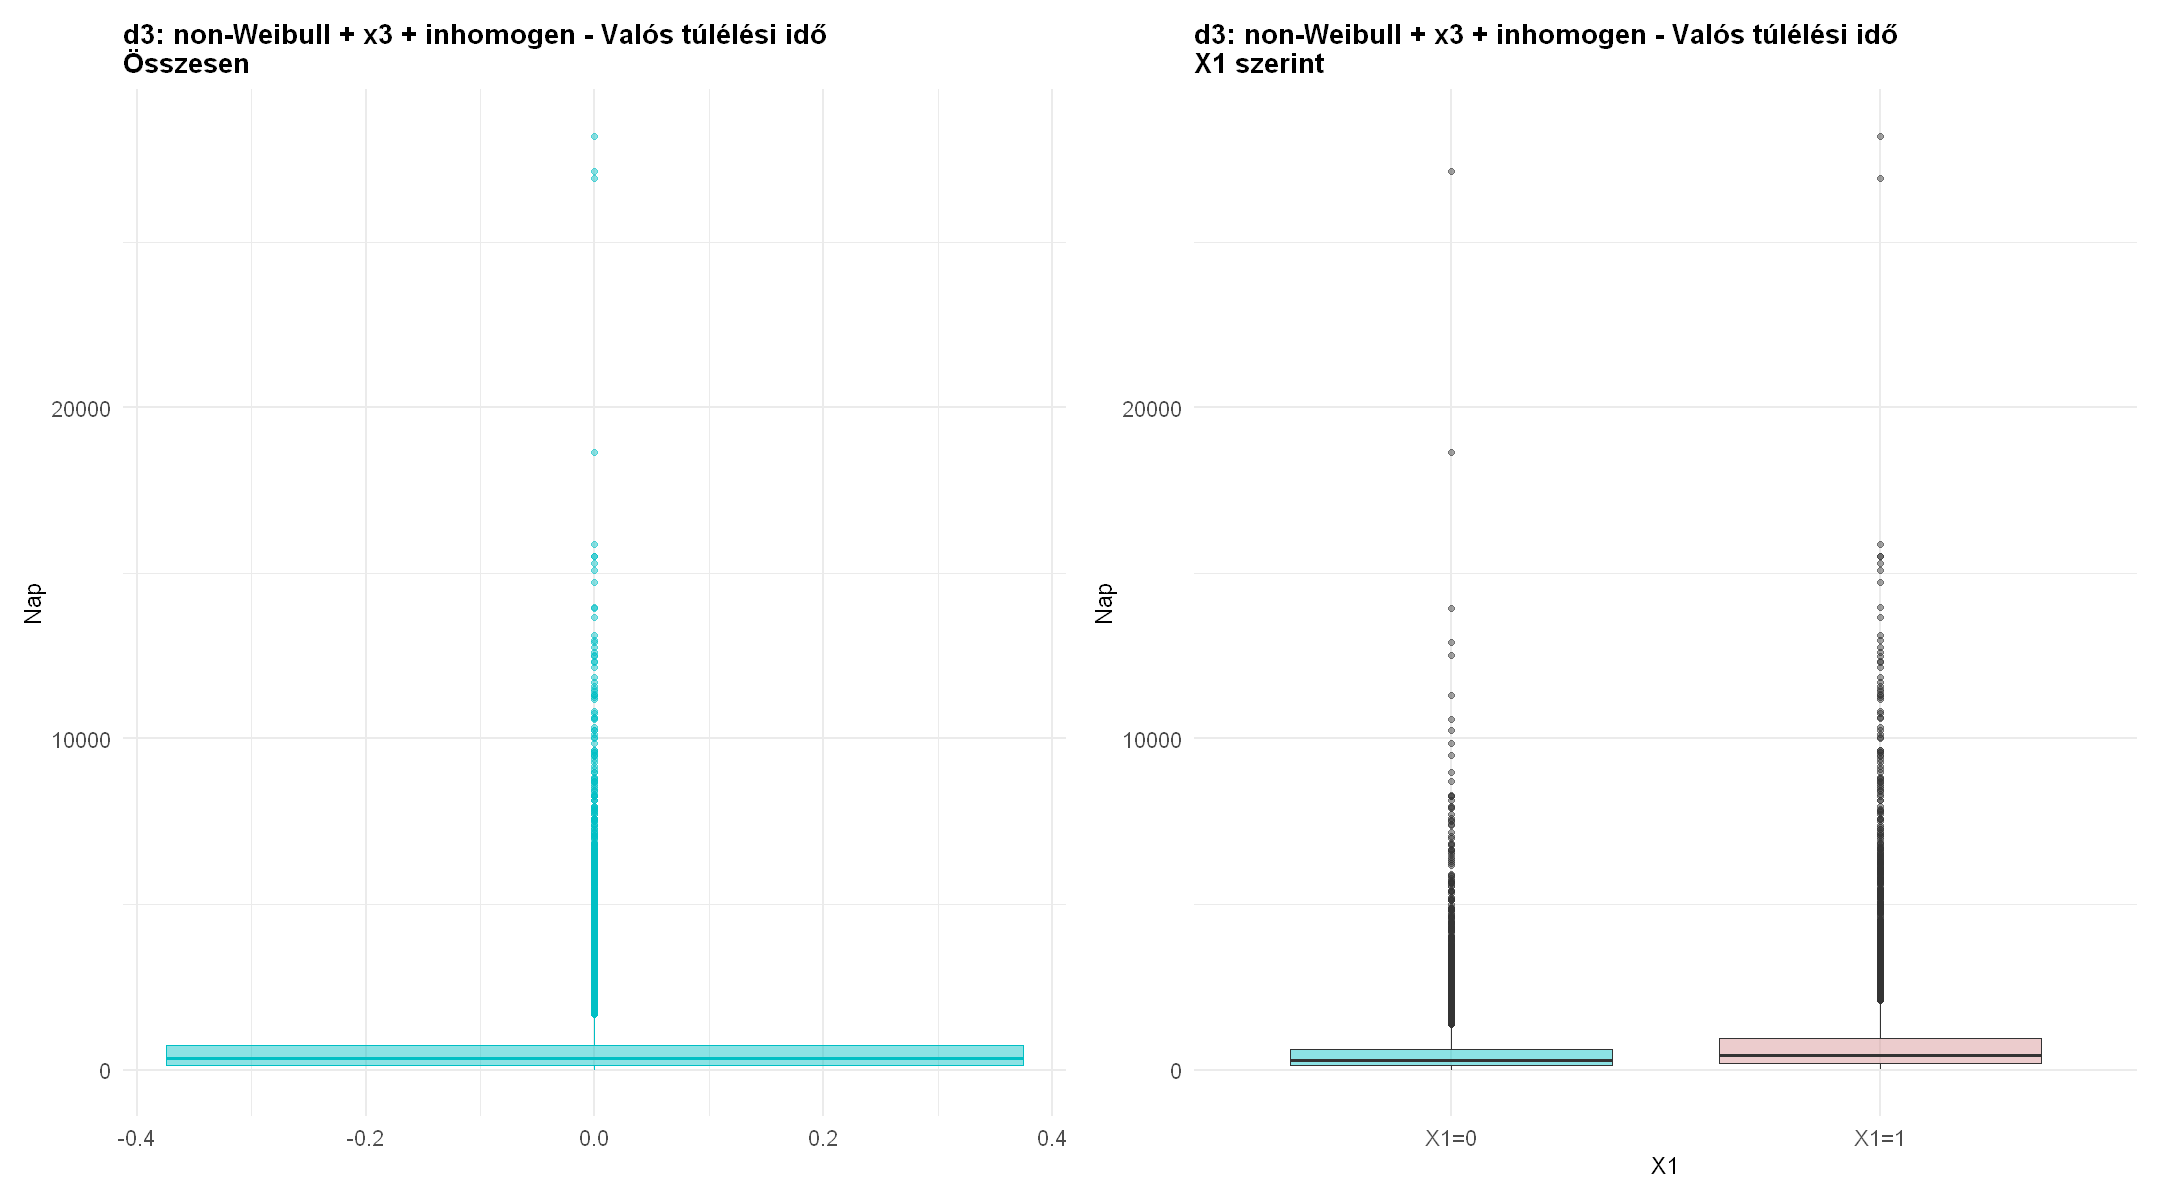

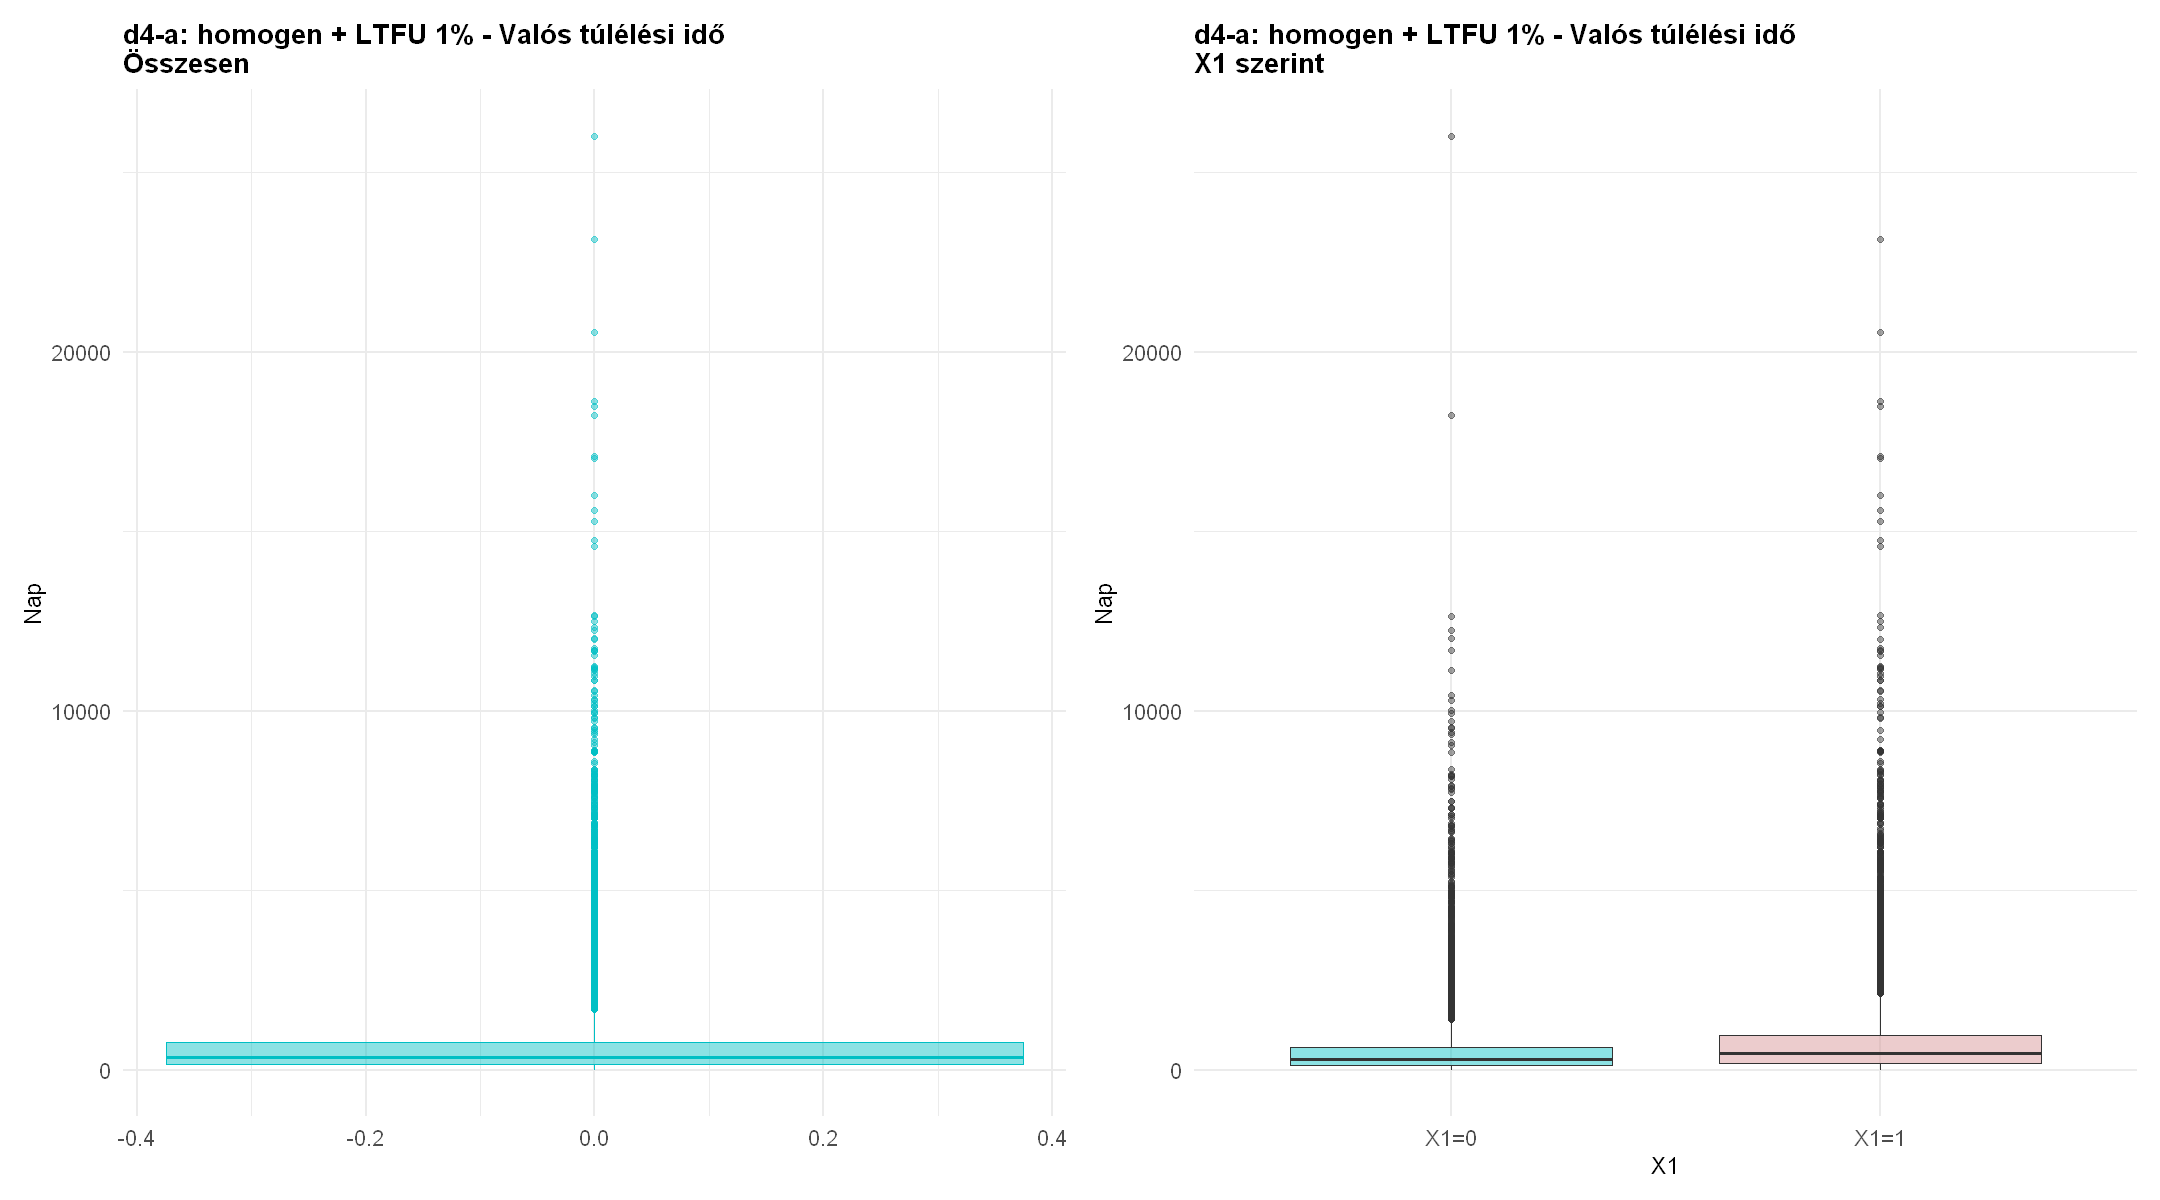

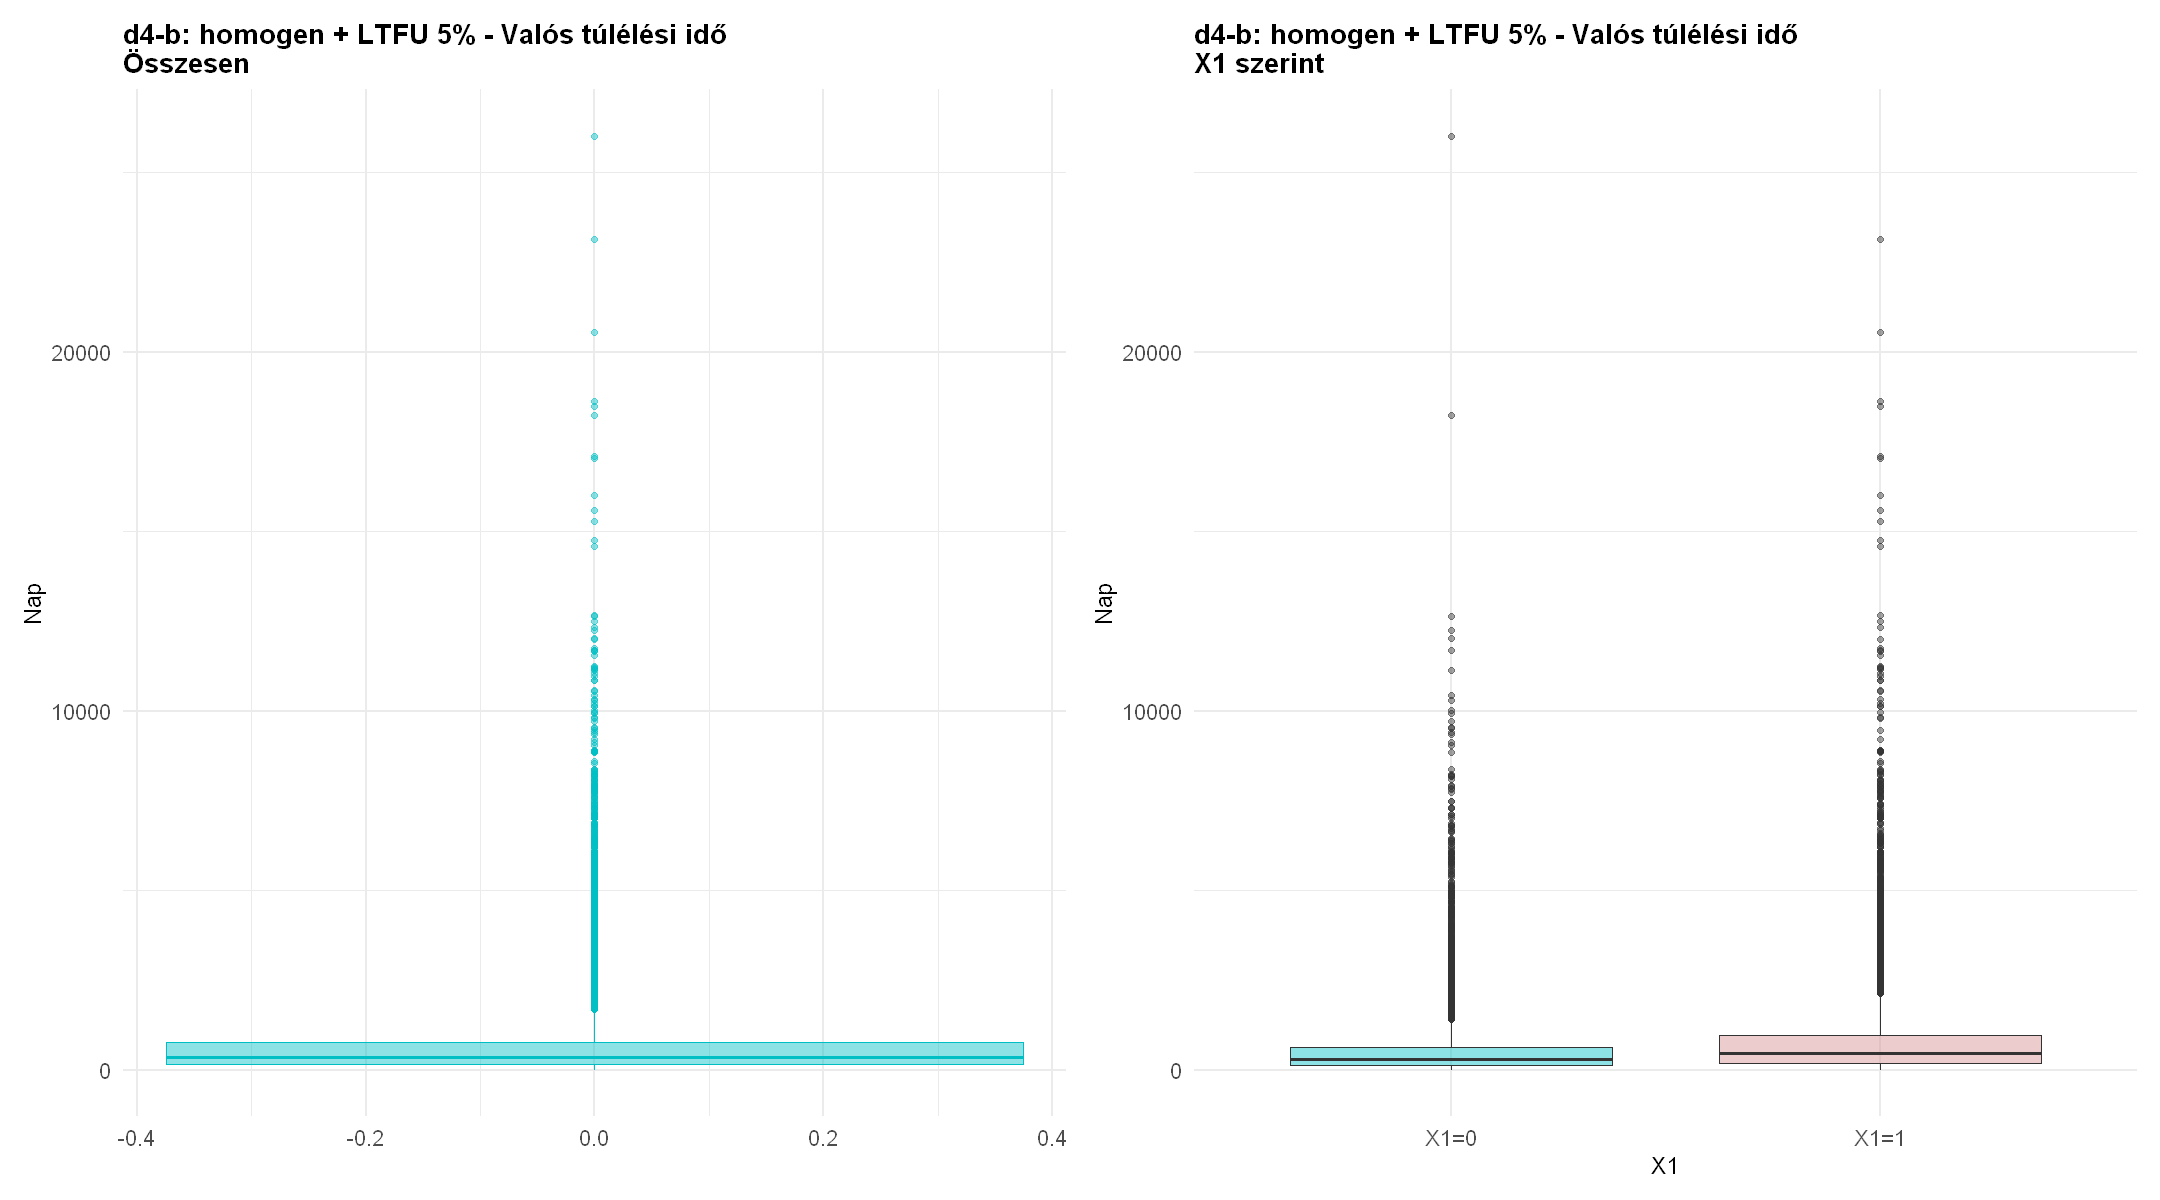

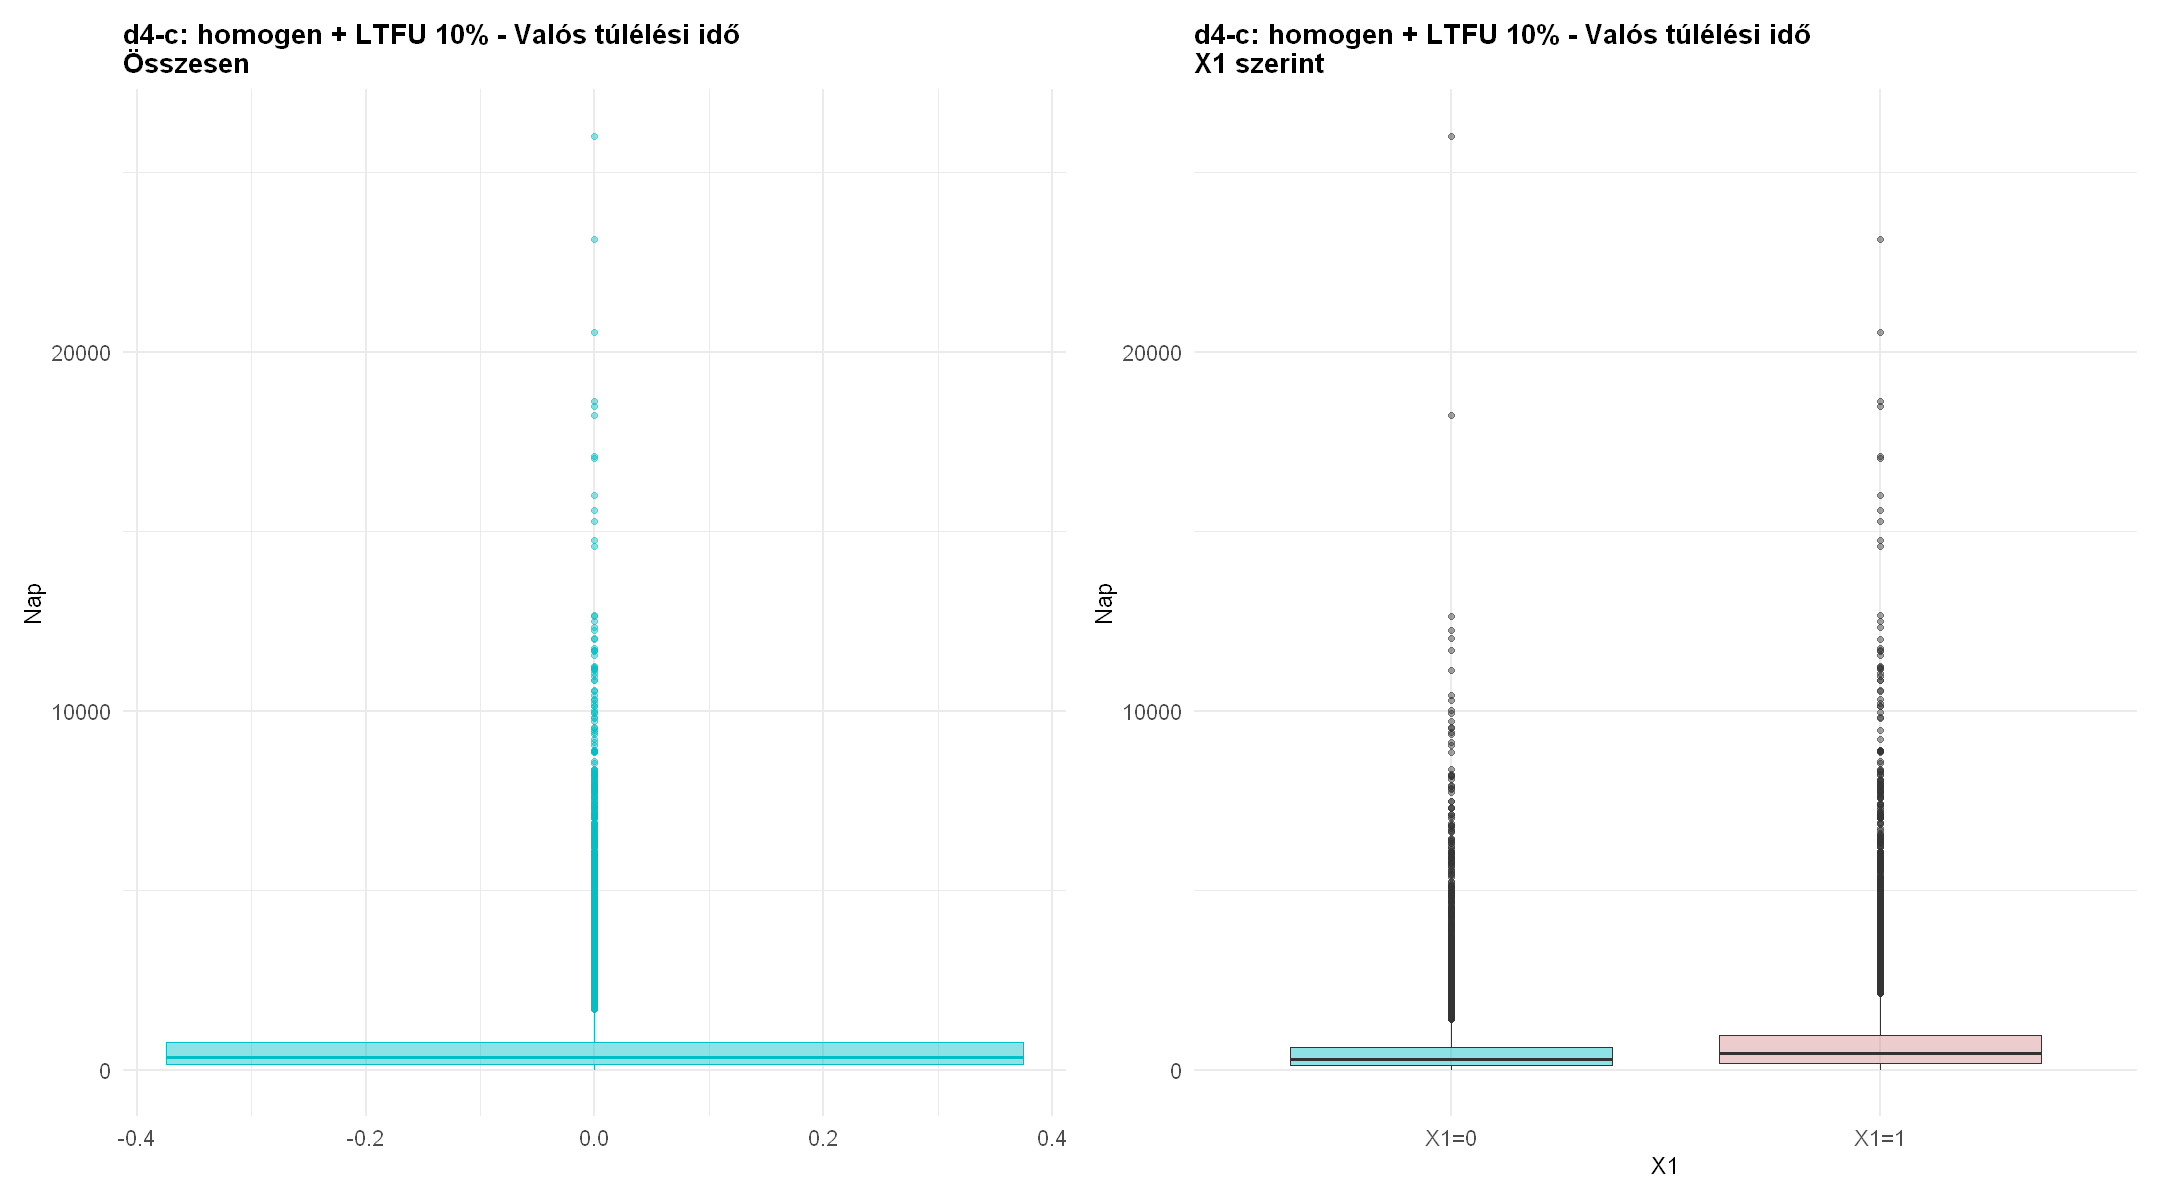

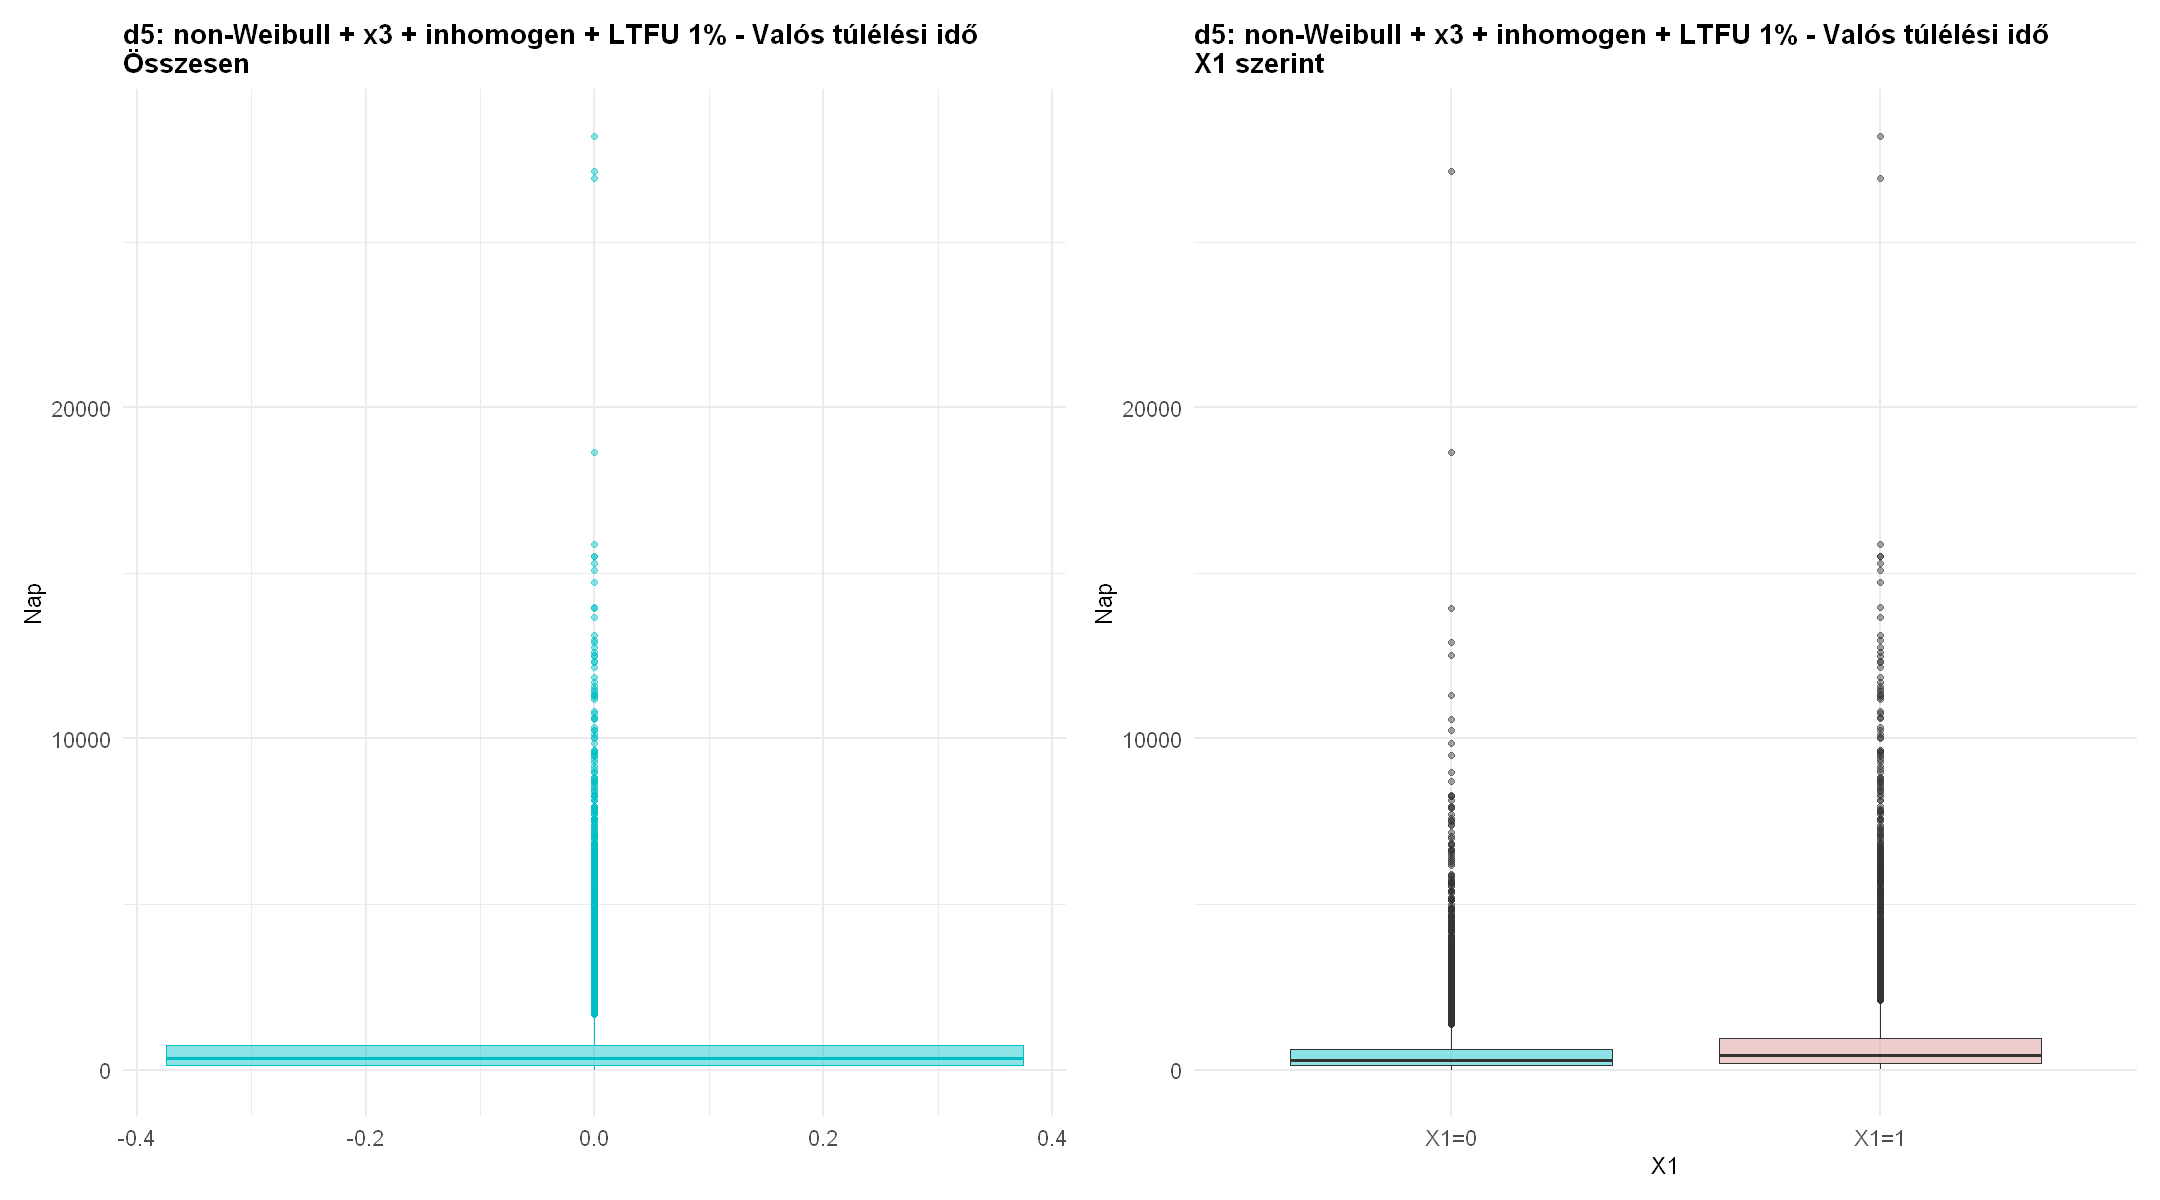

In [45]:
plot_true_survival_boxplots <- function(data_list) {
  set_plot_size(analysis_config$plot_size$box[1], analysis_config$plot_size$box[2])

  col_main <- analysis_config$colors$main
  col_alt  <- analysis_config$colors$alt

  out <- lapply(names(data_list), function(nm) {

    # X1 faktorosítása az ábrázoláshoz
    df_plot <- data_list[[nm]] %>%
      dplyr::mutate(x1_fac = factor(x1, levels = c(0, 1), labels = c("X1=0", "X1=1")))

    # Boxplot: valós túlélési idők összesen
    p_overall <- ggplot2::ggplot(df_plot, ggplot2::aes(y = true_survival_days)) +
      ggplot2::geom_boxplot(fill = col_main, color = col_main, alpha = 0.45) +
      notebook_theme(base_size = analysis_config$base_size$large) +
      ggplot2::labs(title = paste0(nm, " - Valós túlélési idő\nÖsszesen"), y = "Nap", x = NULL)

    # Boxplot: valós túlélési idők X1 szerint
    p_by_x1 <- ggplot2::ggplot(df_plot, ggplot2::aes(x = x1_fac, y = true_survival_days, fill = x1_fac)) +
      ggplot2::geom_boxplot(alpha = 0.45) +
      ggplot2::scale_fill_manual(values = c("X1=0" = col_main, "X1=1" = col_alt)) +
      notebook_theme(base_size = analysis_config$base_size$large) +
      ggplot2::theme(legend.position = "none") +
      ggplot2::labs(title = paste0(nm, " - Valós túlélési idő\nX1 szerint"), x = "X1", y = "Nap")

    # Megjelenítés: két ábra egymás mellett
    print(patchwork::wrap_plots(p_overall, p_by_x1, ncol = 2))

    list(p_overall = p_overall, p_by_x1 = p_by_x1)
  })

  names(out) <- names(data_list)
  out
}

survival_boxplots <- plot_true_survival_boxplots(
  list(
    "d1: idealis" = df_eda_d1_idealis,
    "d2: non-Weibull + x3" = df_eda_d2_nonweibull_x3,
    "d3: non-Weibull + x3 + inhomogen" = df_eda_d3_nonweibull_x3_inhomogen,
    "d4-a: homogen + LTFU 1%" = df_eda_d4_a_homogen_ltfu_1,
    "d4-b: homogen + LTFU 5%" = df_eda_d4_b_homogen_ltfu_5,
    "d4-c: homogen + LTFU 10%" = df_eda_d4_c_homogen_ltfu_10,
    "d5: non-Weibull + x3 + inhomogen + LTFU 1%" = df_eda_d5_inhomogen_ltfu_1
  )
)


#### Valós túlélési idők eloszlása X1 szerint
- A valós túlélési idők eloszlásának összevetése X1 csoportok szerint.
- Mediánok kijelzése és log skála használata a ferdeség kezelésére.


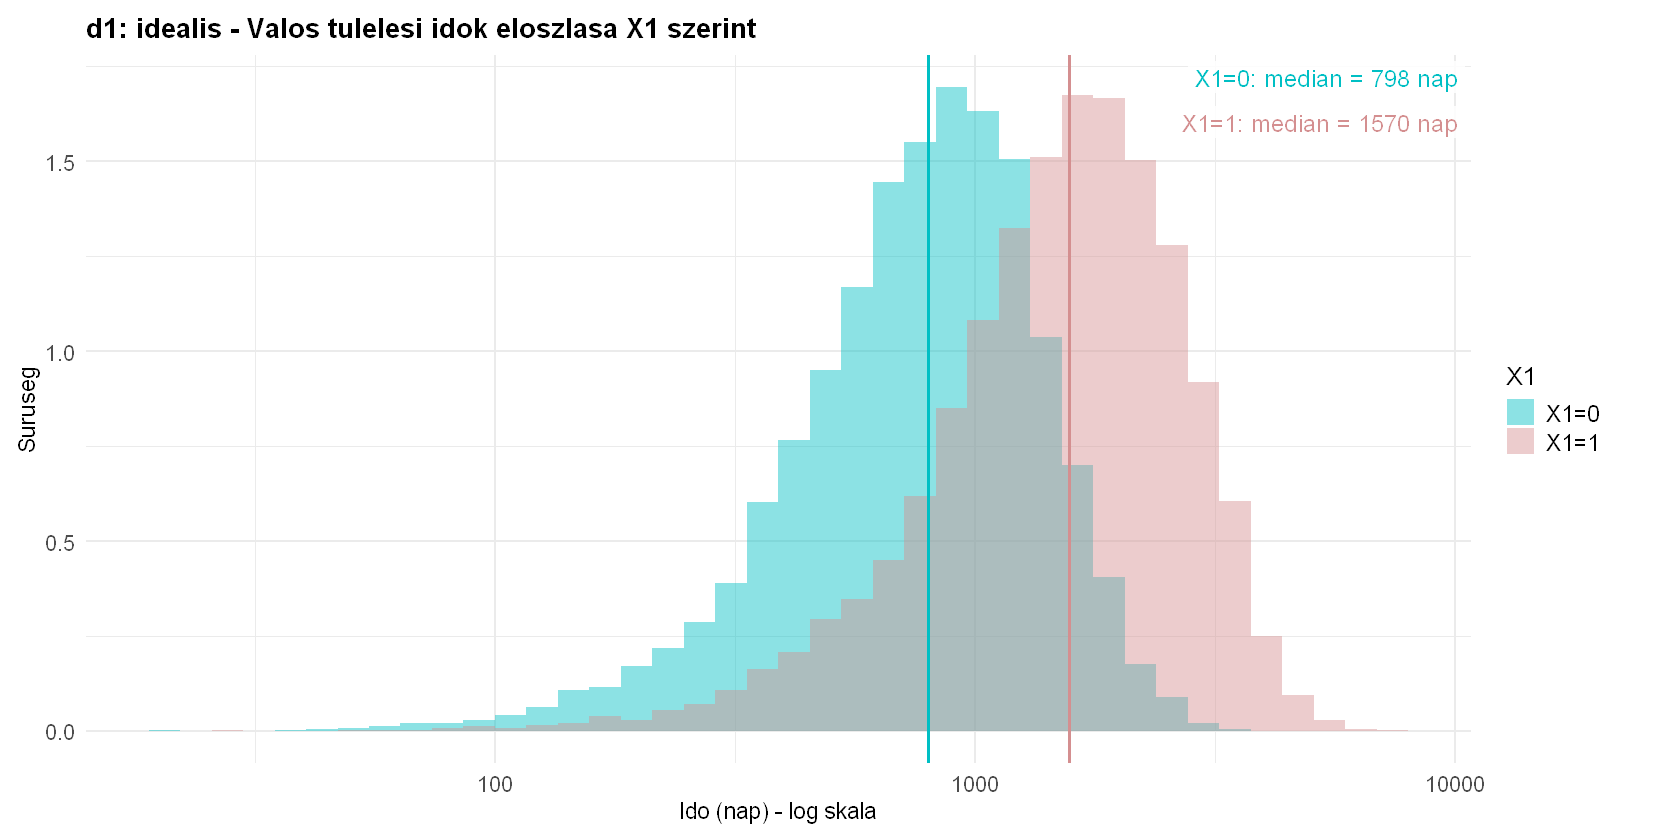

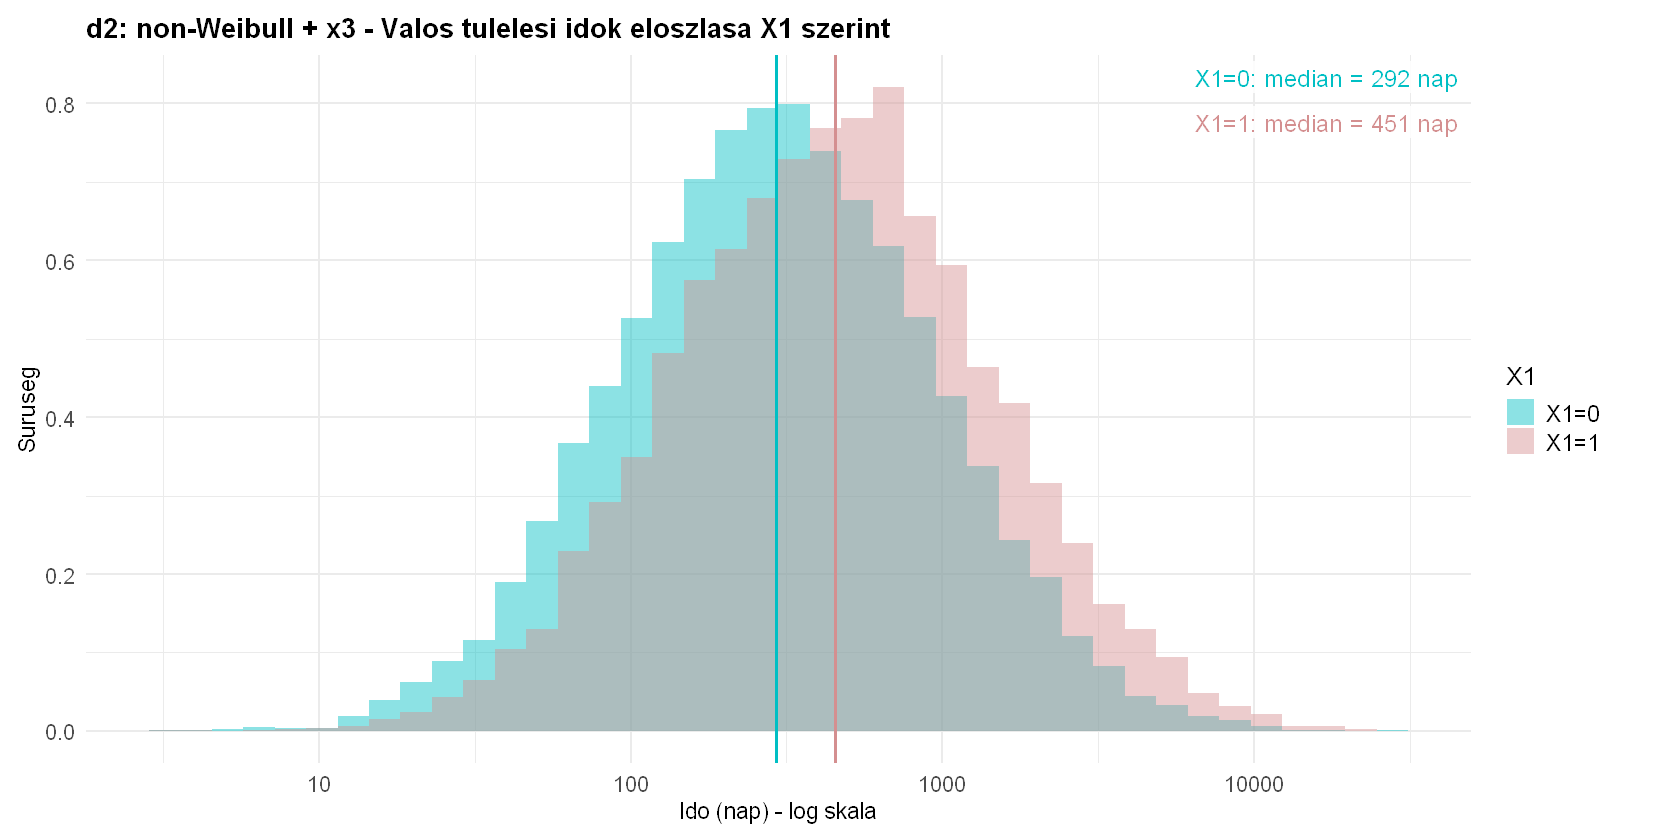

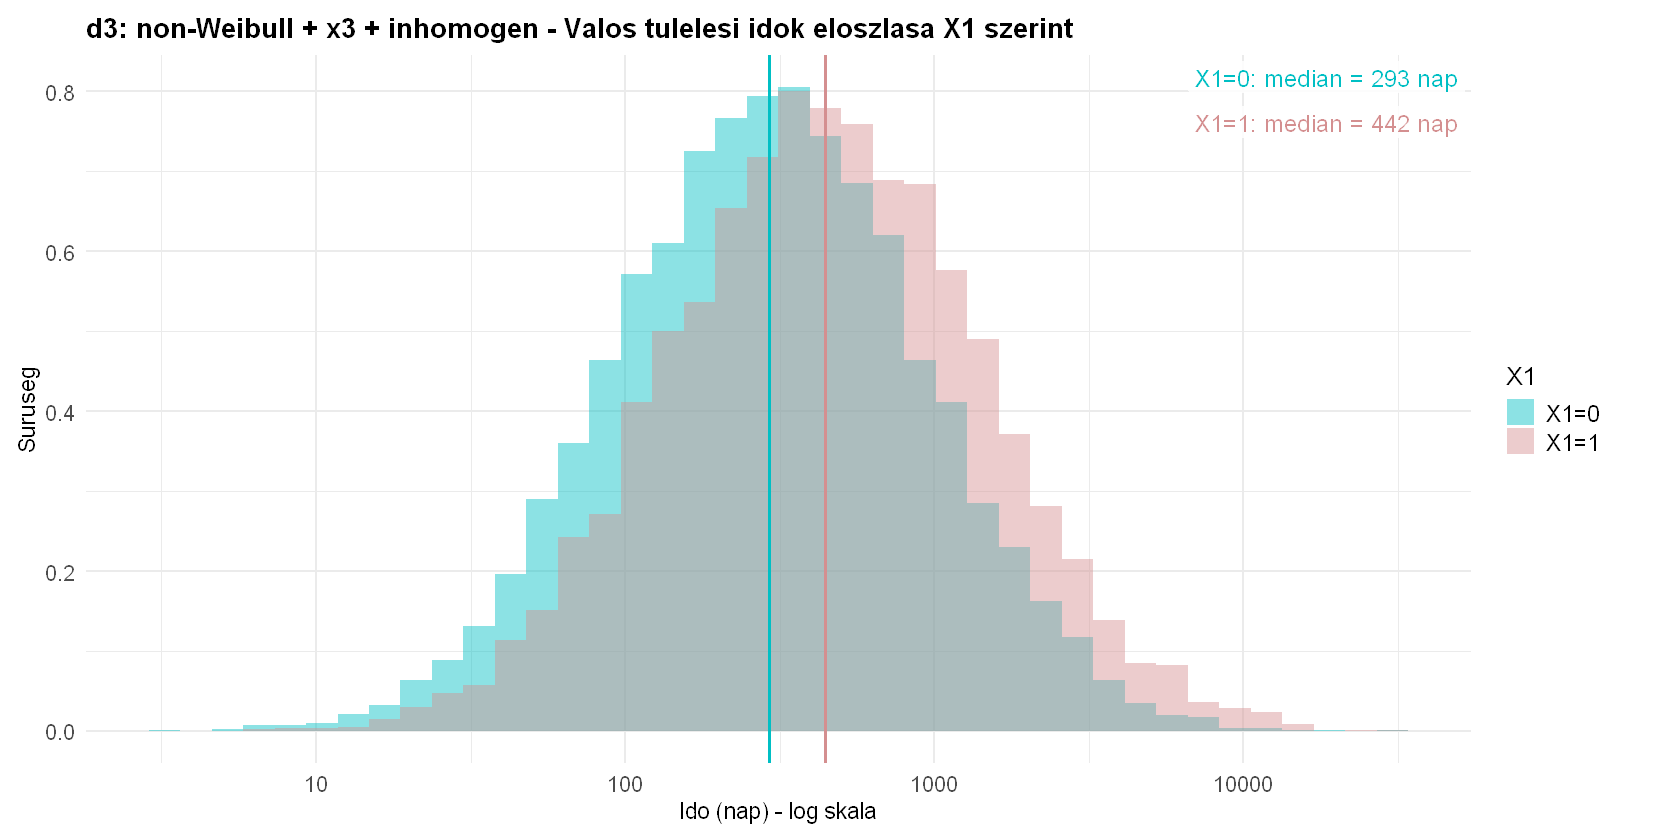

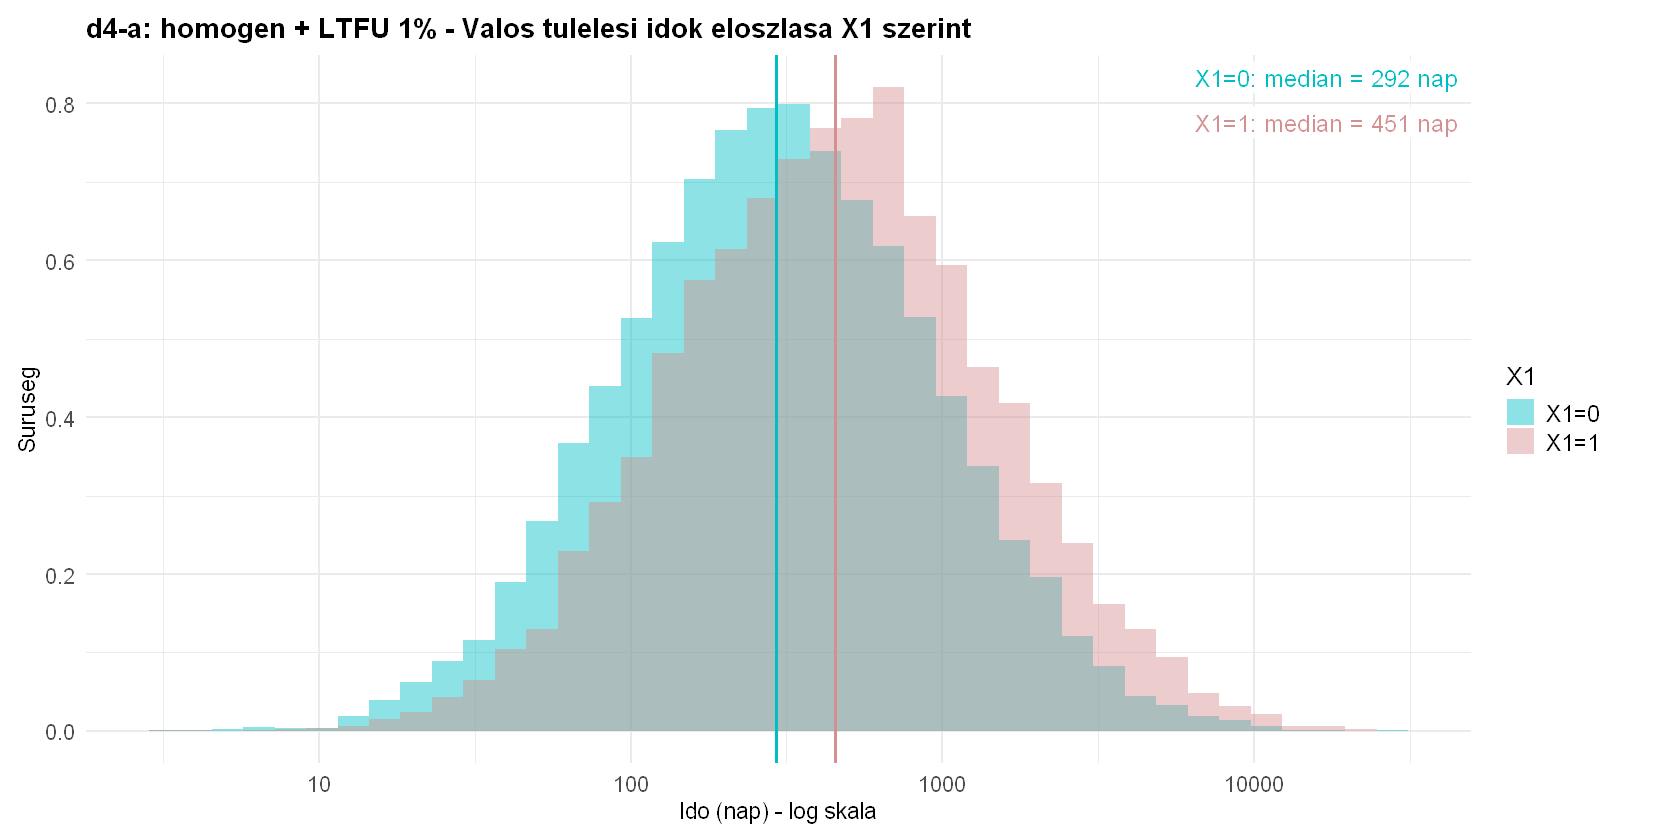

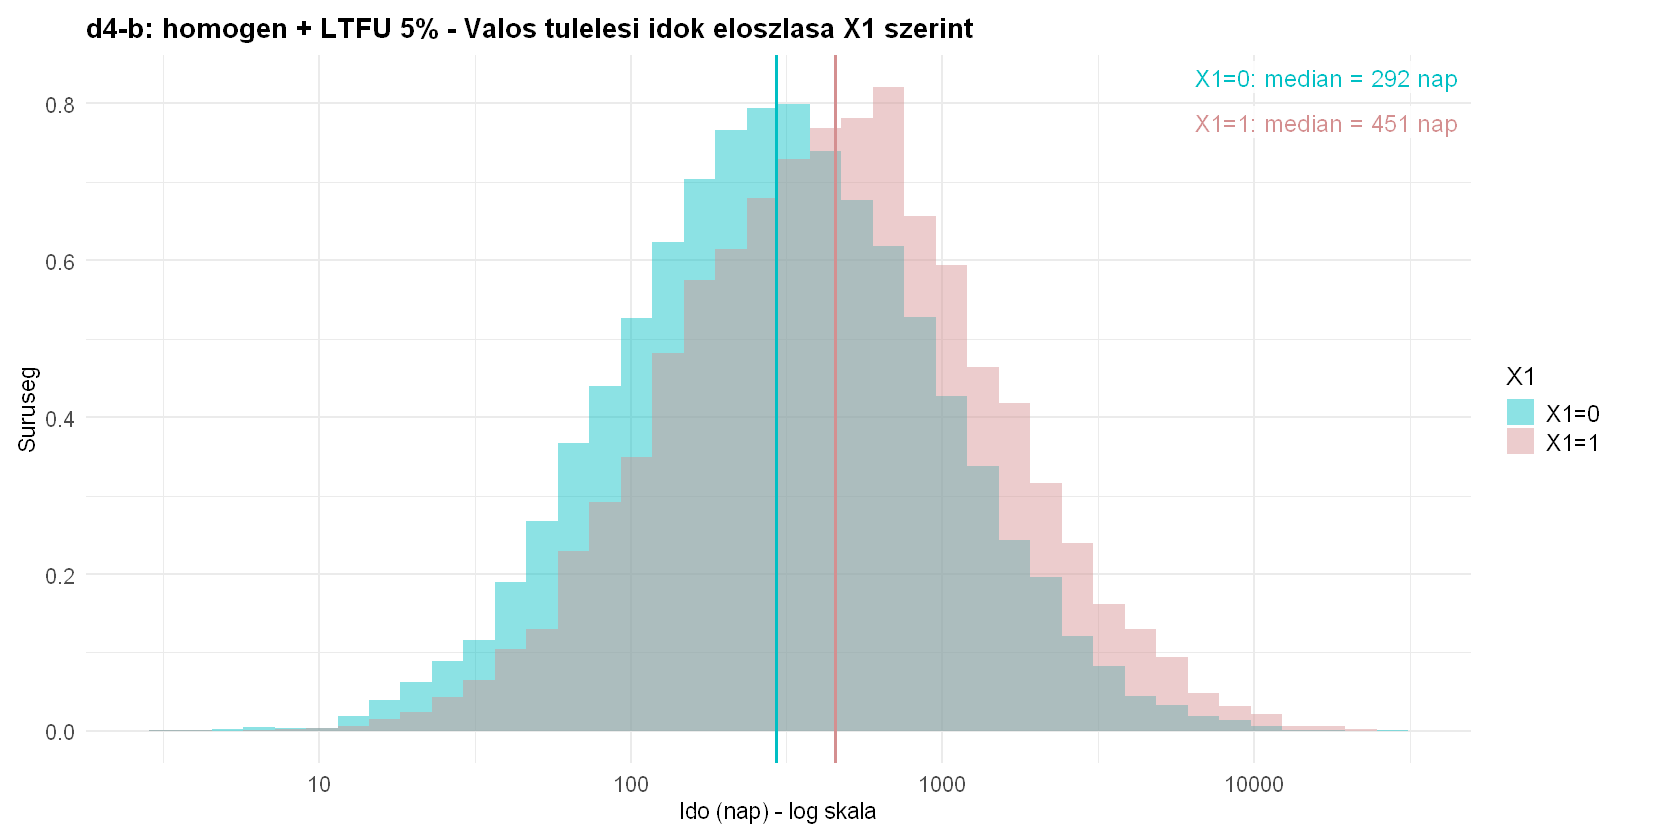

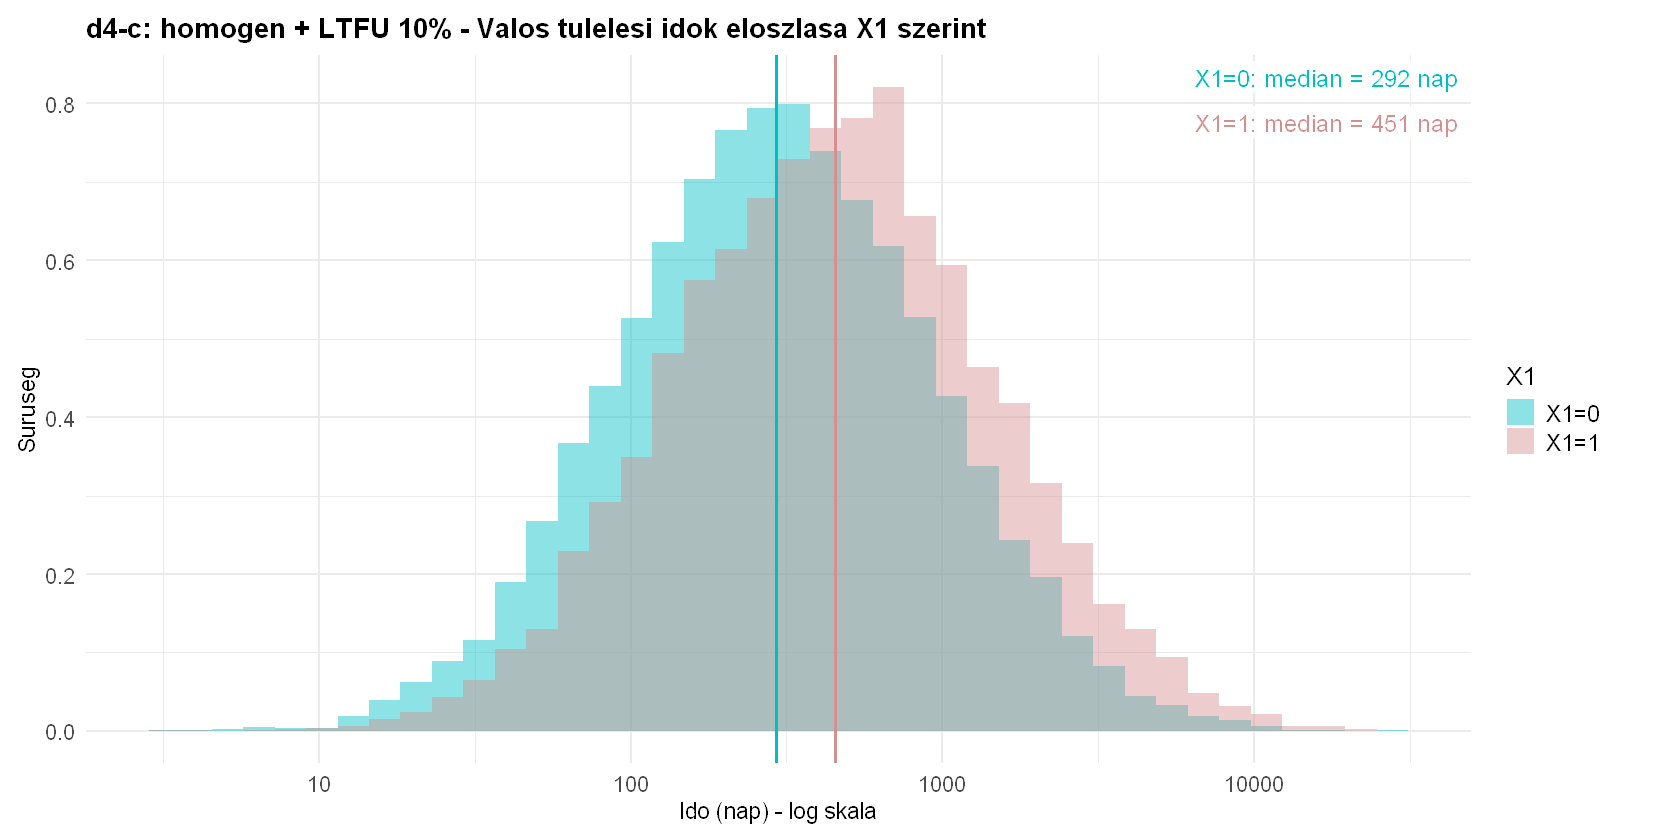

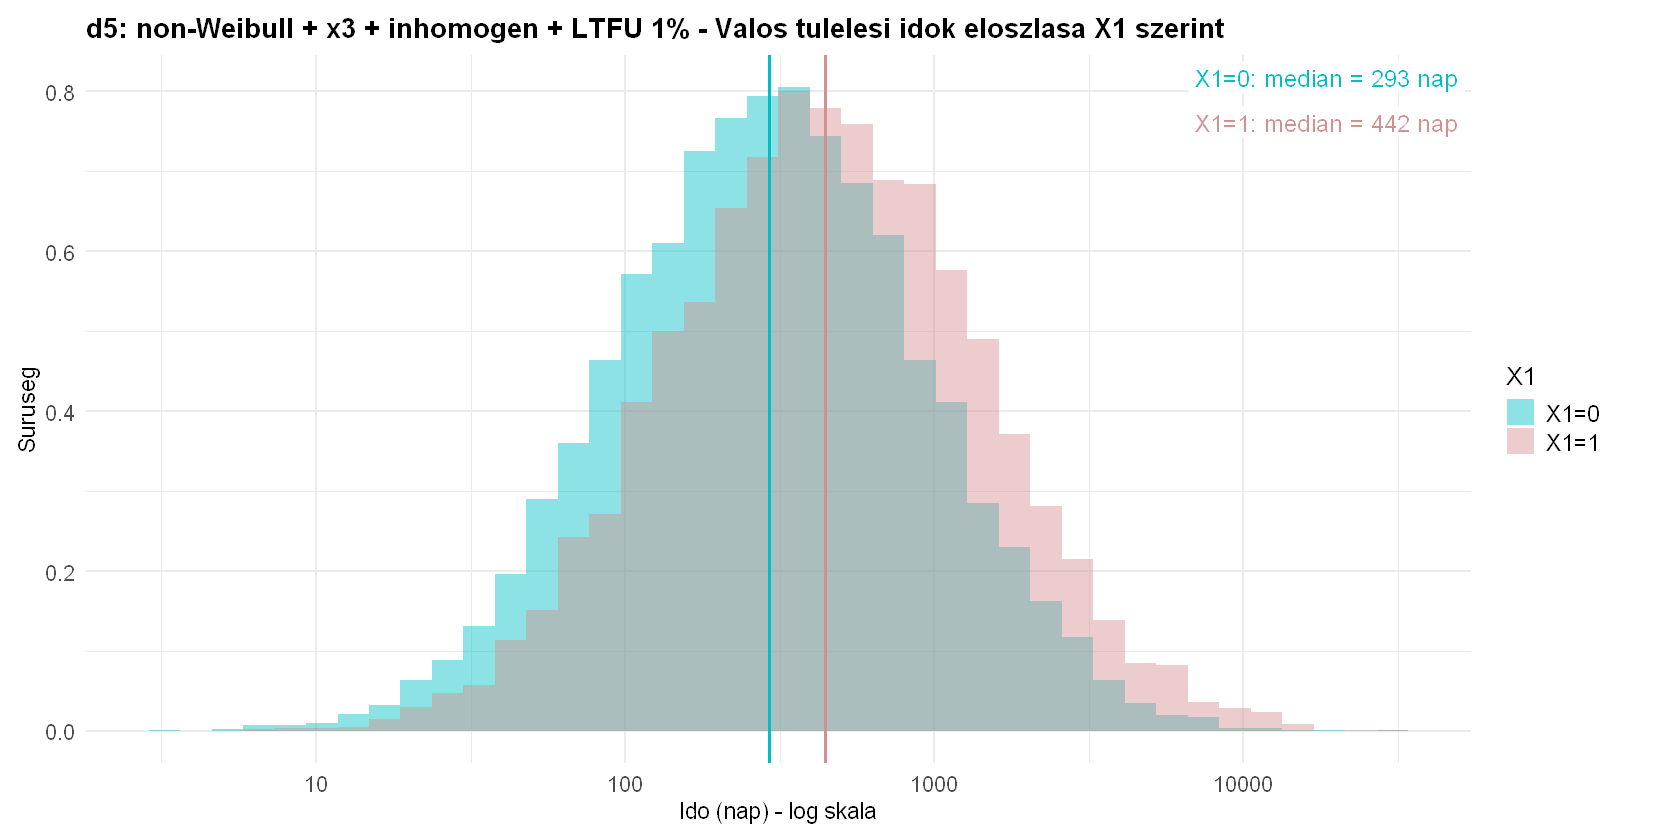

In [46]:
plot_true_survival_hist_by_x1 <- function(data_list, use_log_scale = TRUE) {
  set_plot_size(analysis_config$plot_size$wide[1], analysis_config$plot_size$wide[2])

  # Színkódok rögzítése az X1 csoportokhoz
  col_main <- analysis_config$colors$main
  col_alt  <- analysis_config$colors$alt

  # Ábrák előállítása scenáriónként
  plots <- lapply(names(data_list), function(nm) {

    # Ábrához szükséges változók előállítása és érvényes sorok szűrése
    df_plot <- data_list[[nm]] %>%
      dplyr::transmute(
        nap = true_survival_days,
        x1 = factor(x1, levels = c(0, 1), labels = c("X1=0", "X1=1"))
      ) %>%
      dplyr::filter(is.finite(nap), nap > 0, !is.na(x1))

    # Medián túlélési idők számítása X1 szerint, feliratozáshoz
    med <- df_plot %>%
      dplyr::group_by(x1) %>%
      dplyr::summarise(med = median(nap), .groups = "drop") %>%
      dplyr::mutate(
        label = paste0(x1, ": median = ", round(med, 0), " nap"),
        vj = ifelse(x1 == "X1=0", 1.2, 2.6)
      )

    # Ábra: hisztogram X1 szerint, medián vonalakkal és feliratokkal
    p <- ggplot2::ggplot(df_plot, ggplot2::aes(x = nap, fill = x1)) +
      ggplot2::geom_histogram(
        ggplot2::aes(y = after_stat(density)),
        bins = 40, position = "identity", alpha = 0.45
      ) +
      ggplot2::geom_vline(
        data = med, ggplot2::aes(xintercept = med, color = x1),
        linewidth = 1.1, show.legend = FALSE
      ) +
      ggplot2::geom_label(
        data = med,
        ggplot2::aes(x = Inf, y = Inf, label = label, color = x1, vjust = vj),
        inherit.aes = FALSE,
        hjust = 1.02,
        label.size = 0, fill = "white", alpha = 0.85, size = 5,
        show.legend = FALSE
      ) +
      ggplot2::scale_fill_manual(values = c("X1=0" = col_main, "X1=1" = col_alt)) +
      ggplot2::scale_color_manual(values = c("X1=0" = col_main, "X1=1" = col_alt)) +
      ggplot2::coord_cartesian(clip = "off") +
      notebook_theme(base_size = analysis_config$base_size$standard) +
      ggplot2::theme(plot.margin = ggplot2::margin(10, 40, 10, 10)) +
      ggplot2::labs(
        title = paste0(nm, " - Valos tulelesi idok eloszlasa X1 szerint"),
        x = ifelse(use_log_scale, "Ido (nap) - log skala", "Ido (nap)"),
        y = "Suruseg",
        fill = "X1"
      )

    # Logaritmikus tengely opcionálisan
    if (use_log_scale) p <- p + ggplot2::scale_x_log10()

    # Ábra megjelenítése és visszaadása
    print(p)
    p
  })

  # Kimenet: név szerinti ábralista
  names(plots) <- names(data_list)
  plots
}

survival_hist_plots <- plot_true_survival_hist_by_x1(
  list(
    "d1: idealis" = df_eda_d1_idealis,
    "d2: non-Weibull + x3" = df_eda_d2_nonweibull_x3,
    "d3: non-Weibull + x3 + inhomogen" = df_eda_d3_nonweibull_x3_inhomogen,
    "d4-a: homogen + LTFU 1%" = df_eda_d4_a_homogen_ltfu_1,
    "d4-b: homogen + LTFU 5%" = df_eda_d4_b_homogen_ltfu_5,
    "d4-c: homogen + LTFU 10%" = df_eda_d4_c_homogen_ltfu_10,
    "d5: non-Weibull + x3 + inhomogen + LTFU 1%" = df_eda_d5_inhomogen_ltfu_1
  ),
  use_log_scale = TRUE
)


#### Kaplan–Meier görbék életkori sávok szerint
- A valós túlélési idők Kaplan–Meier becslése 10 éves diagnóziskori életkori sávokra bontva.
- A túlélési görbék összevetése az életkor szerinti különbségek gyors áttekintéséhez.


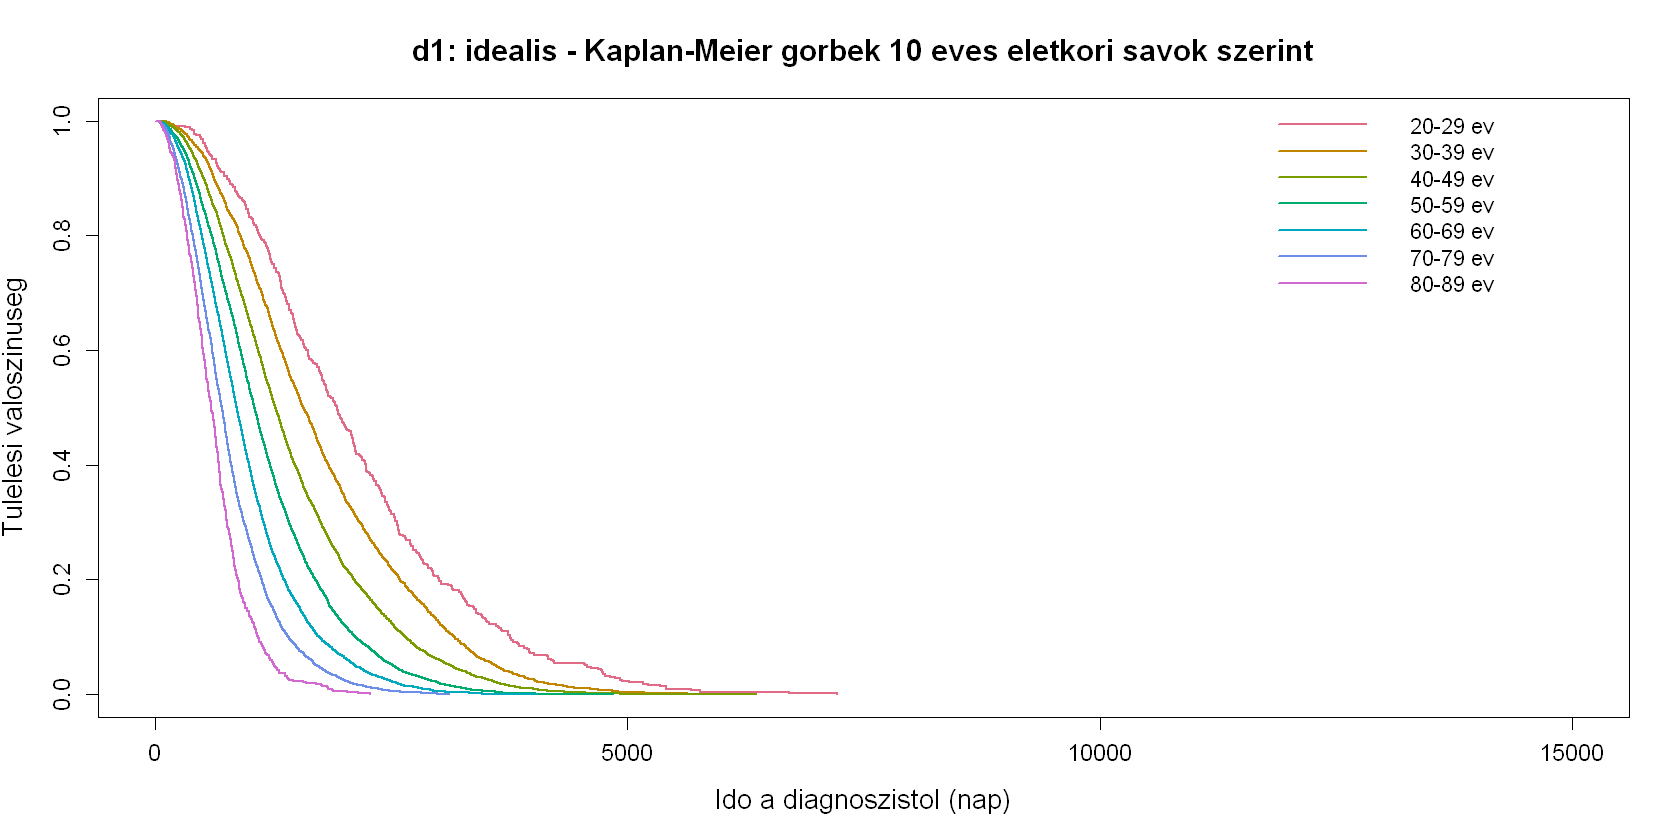

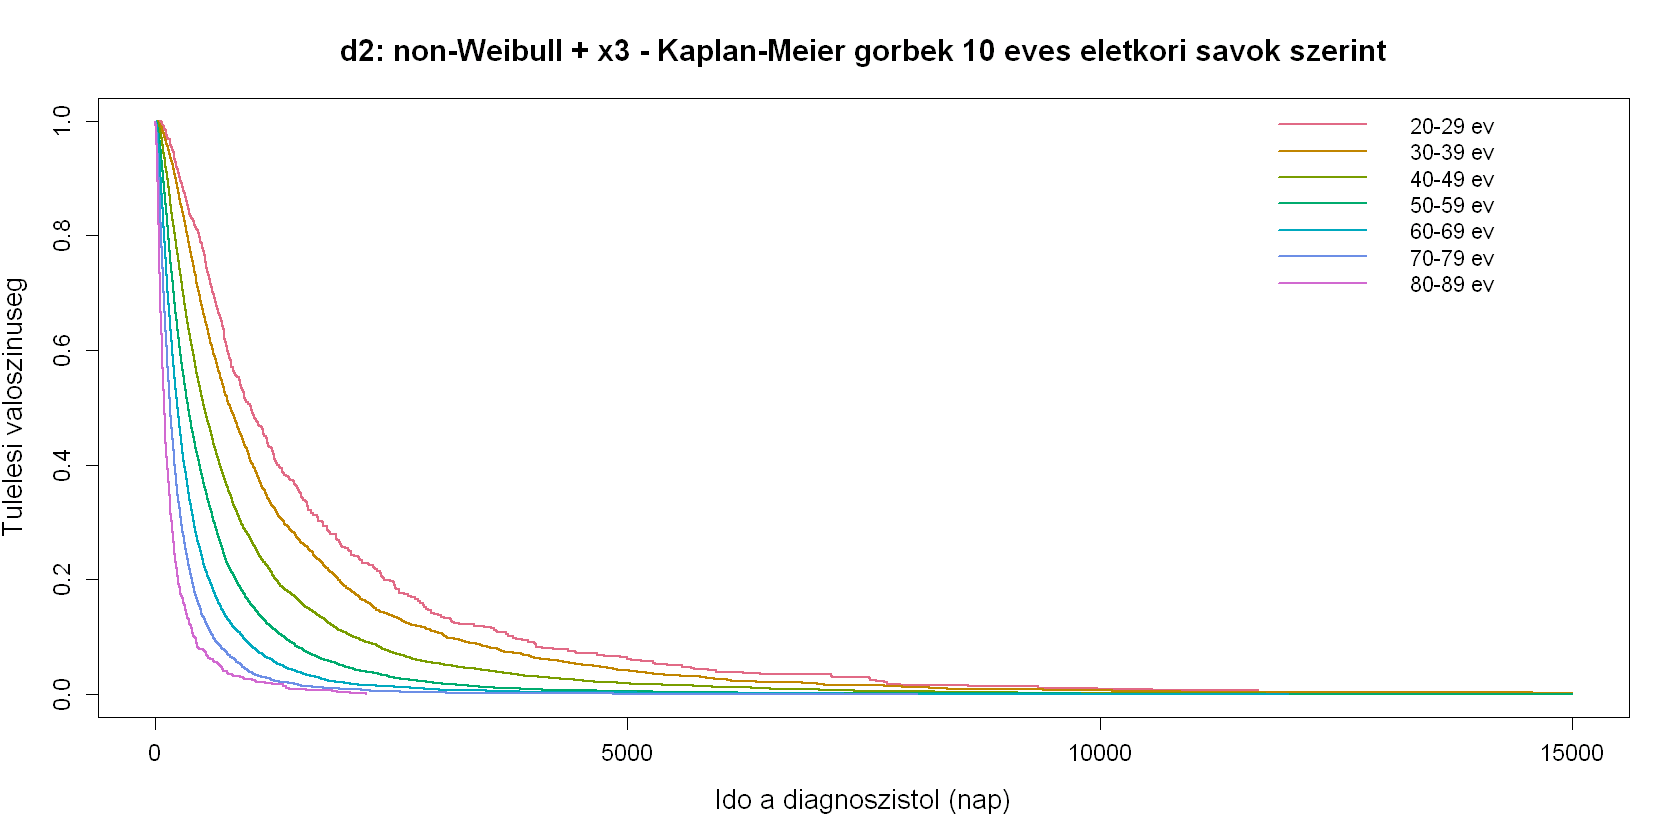

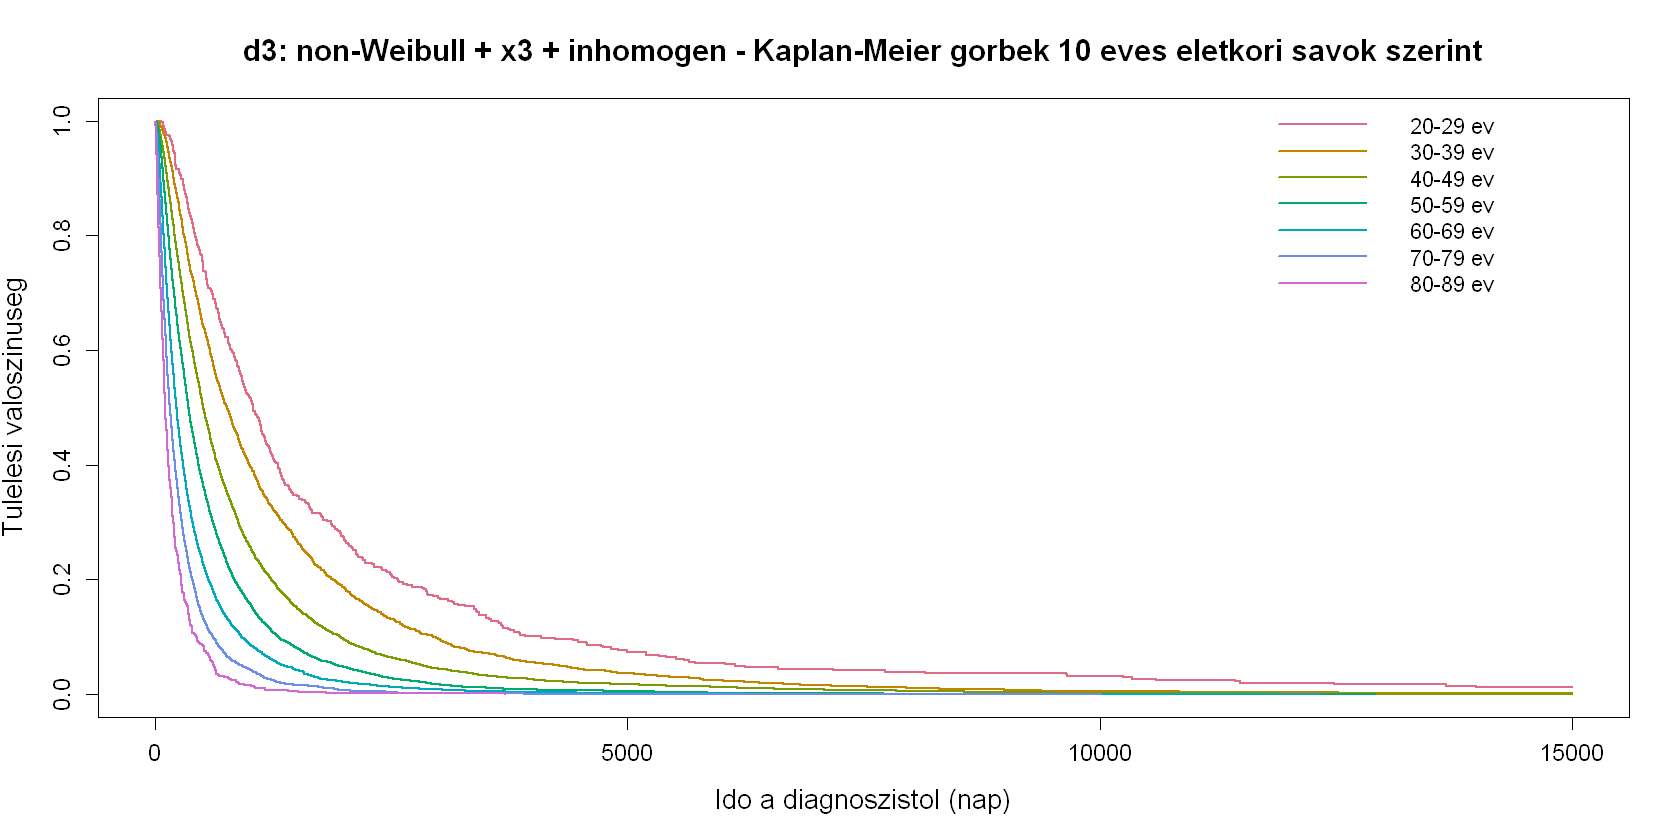

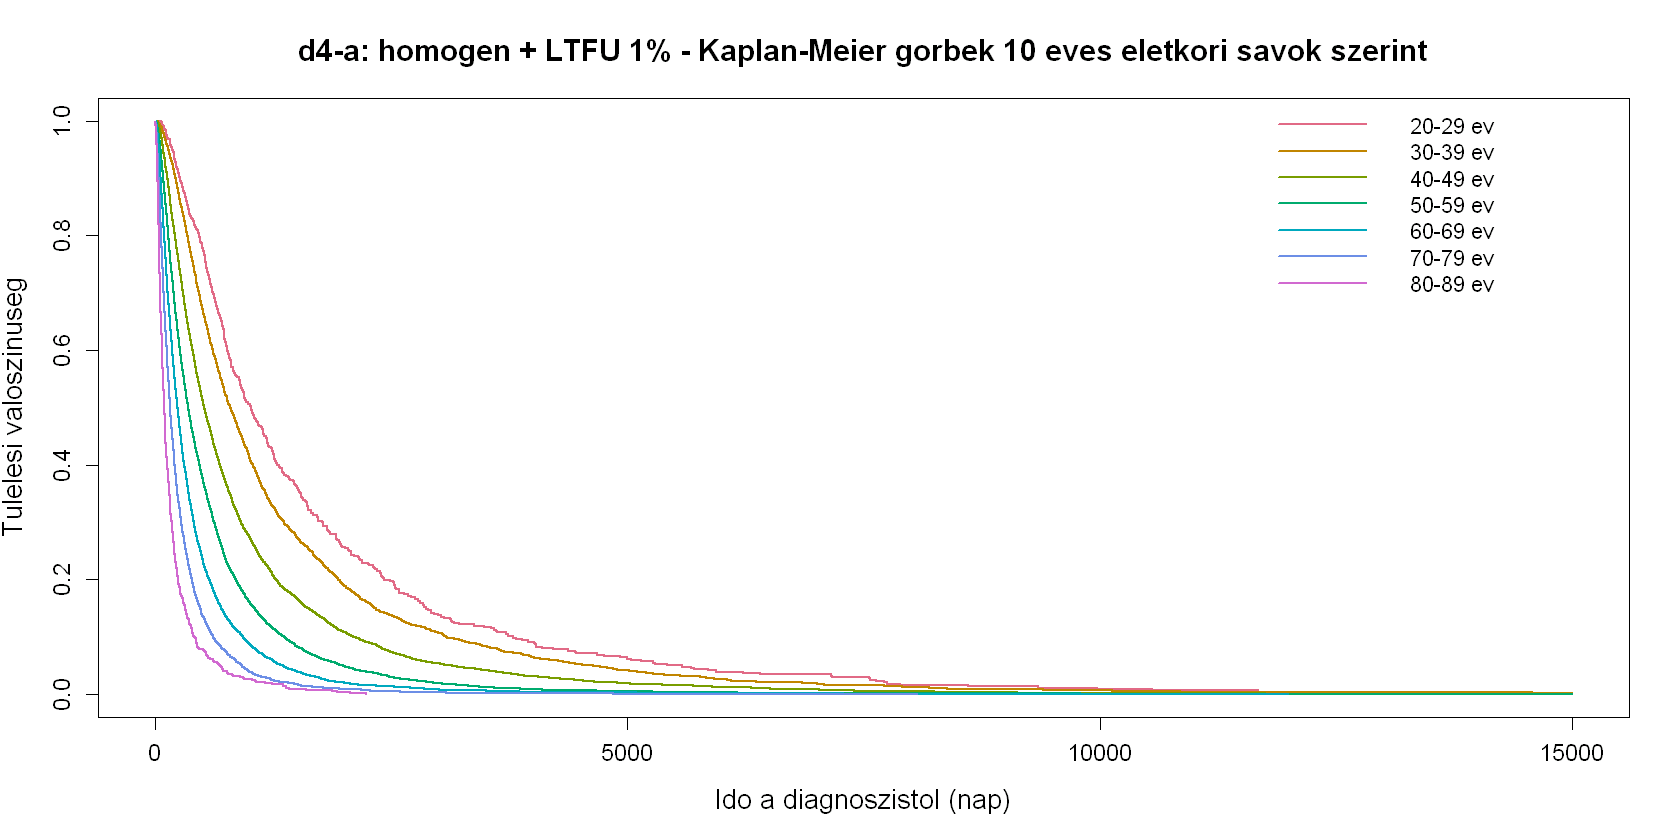

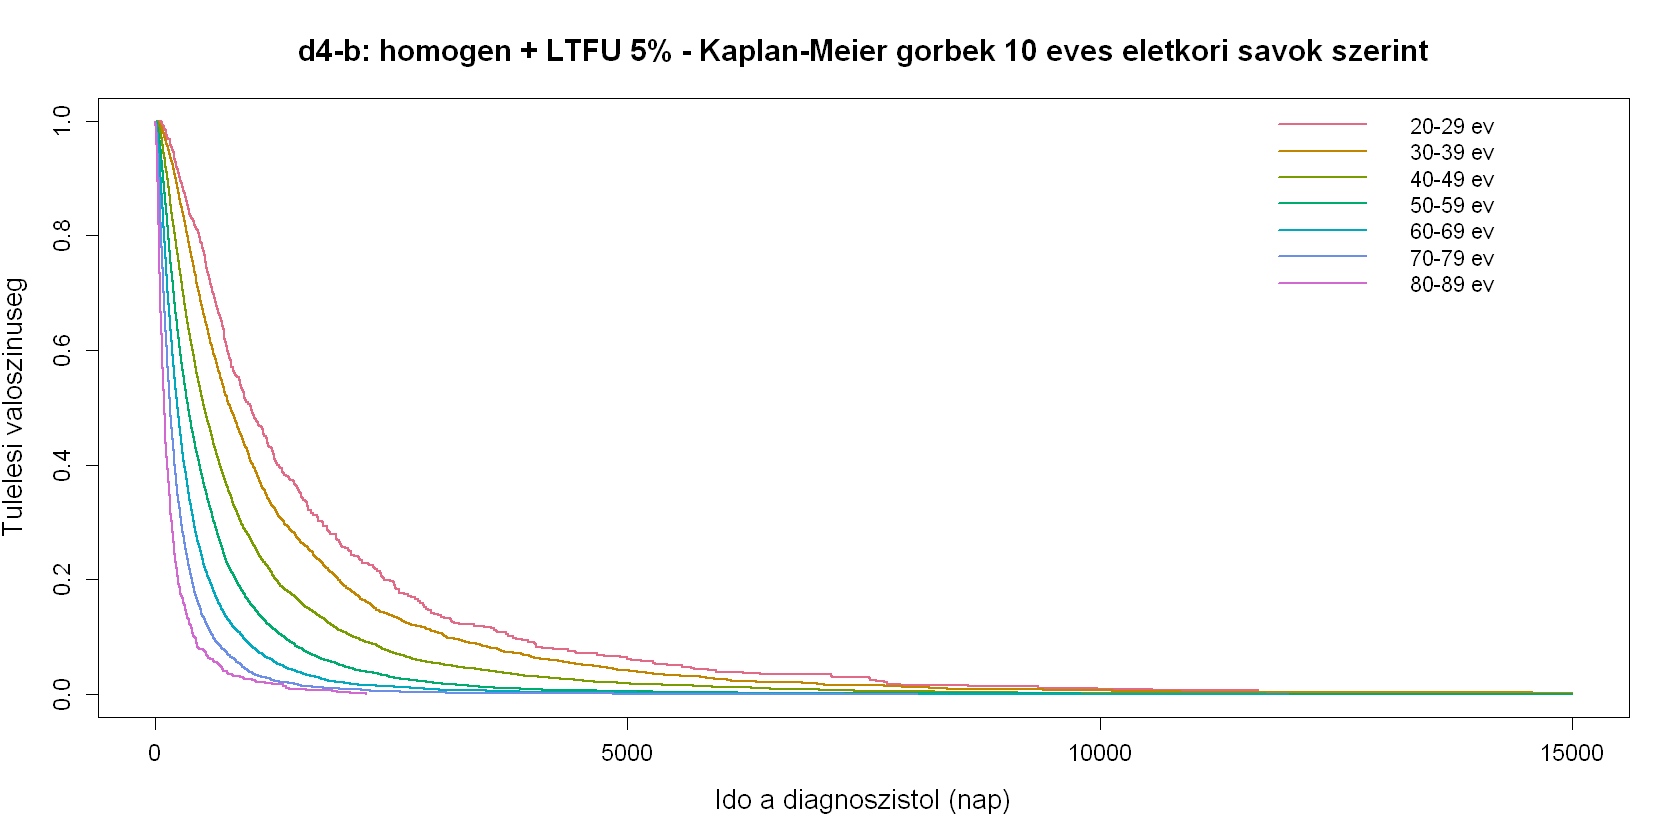

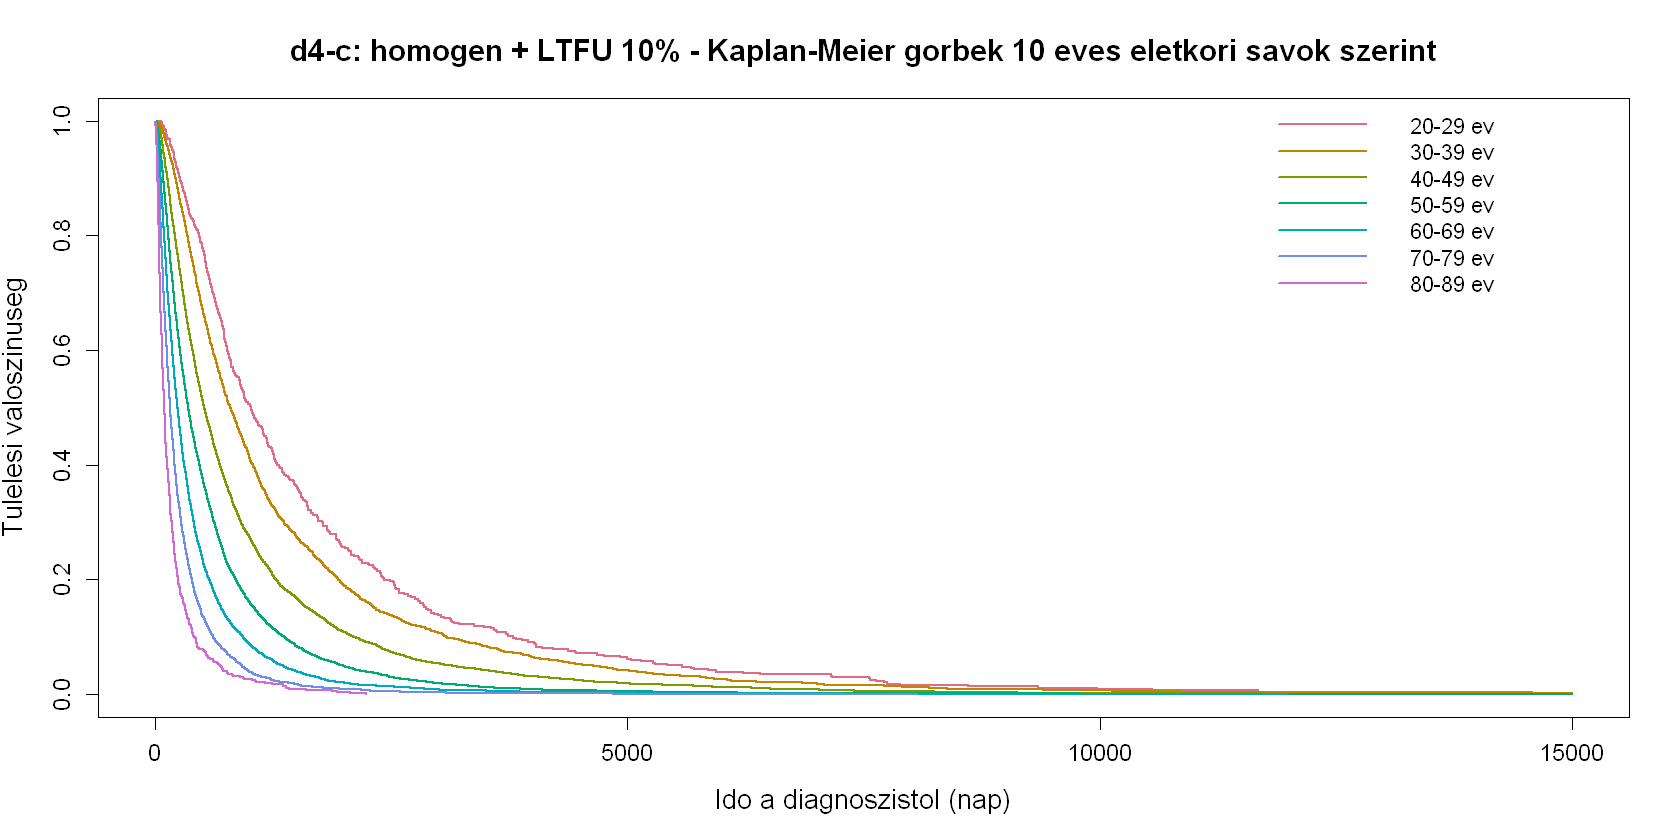

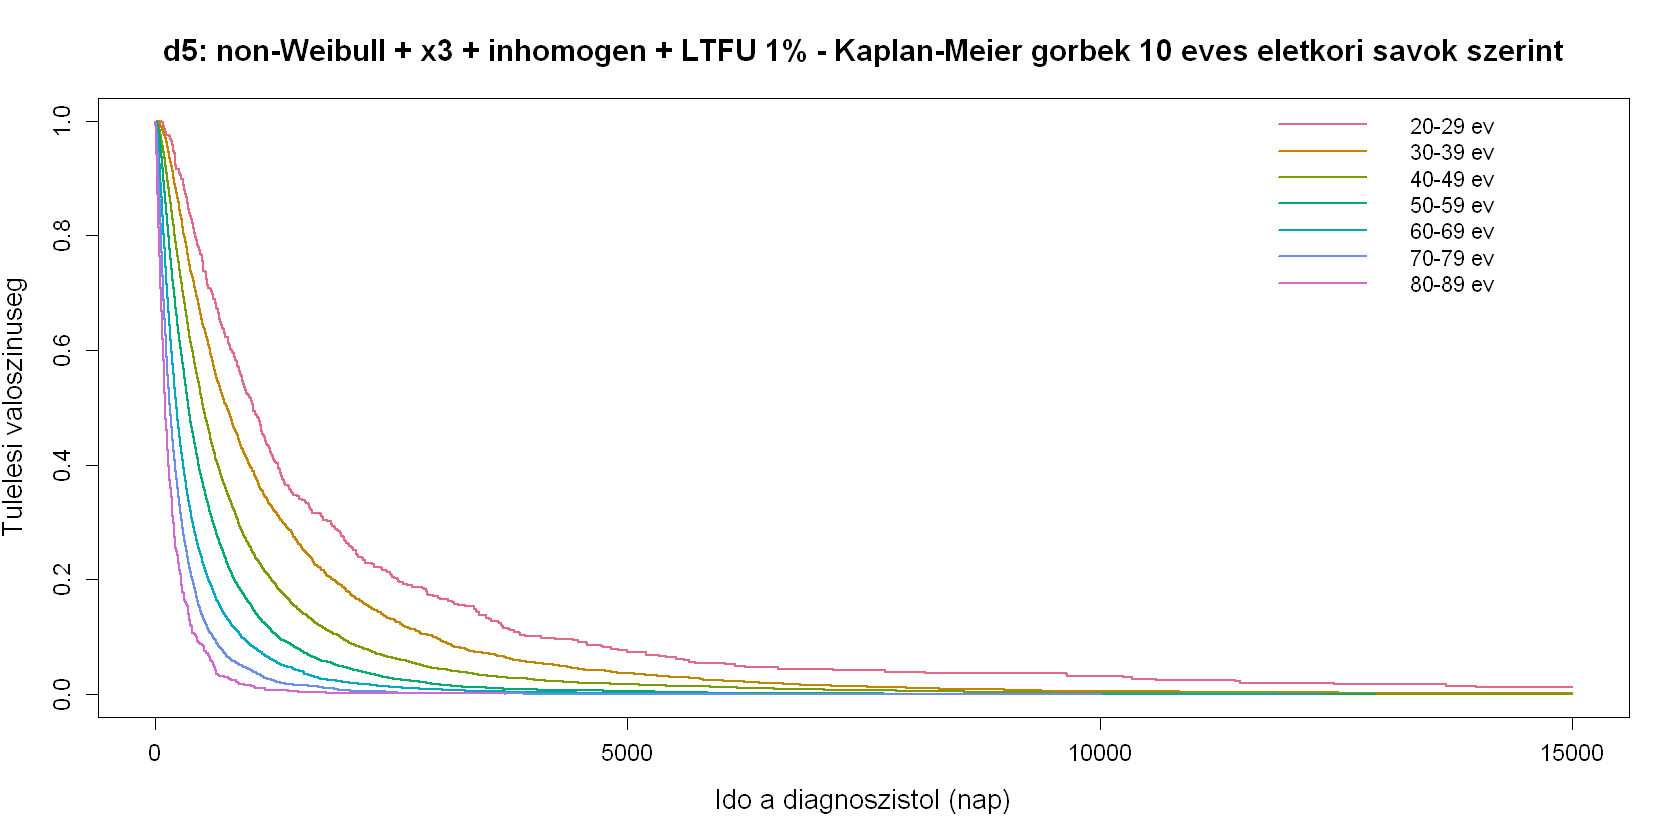

In [47]:
plot_km_by_age_band <- function(data_list, band_width = 10, x_max = 15000) {
  set_plot_size(14, 7)

  cex_main <- 1.5
  cex_lab <- 1.35
  cex_axis <- 1.2
  cex_legend <- 1.1

  # KM illesztések előállítása scenáriónként (és közben ábrázolás)
  fits <- lapply(names(data_list), function(nm) {
    df <- data_list[[nm]]

    # Diagnóziskori életkor változó kiválasztása (ha nincs külön oszlop, x2-t használjuk)
    age_col <- if ("age_at_dx" %in% names(df)) "age_at_dx" else "x2"

    # KM-hez szükséges adatkeret: életkor, valós túlélési idő, valós eseményindikátor
    d <- data.frame(
      age = df[[age_col]],
      time = df$true_survival_days,
      event = df$true_event_indicator_delta_true
    )

    # Érvényes sorok szűrése (véges értékek, pozitív idő, nem hiányzó esemény)
    d <- d[is.finite(d$age) & is.finite(d$time) & d$time > 0 & !is.na(d$event), ]

    # Életkori sávok kialakítása (band_width éves, balról zárt intervallumok)
    breaks <- seq(
      floor(min(d$age) / band_width) * band_width,
      ceiling(max(d$age) / band_width) * band_width,
      by = band_width
    )
    labs <- paste0(breaks[-length(breaks)], "-", breaks[-1] - 1, " ev")
    d$age_band <- cut(d$age, breaks = breaks, right = FALSE, include.lowest = TRUE, labels = labs)

    # Kaplan-Meier illesztés életkori sávok szerint
    fit <- survival::survfit(survival::Surv(time, event) ~ age_band, data = d)

    # Színek automatikus hozzárendelése a sávokhoz
    cols <- grDevices::hcl.colors(nlevels(d$age_band), palette = analysis_config$palette$km_age_band)

    # Ábra: KM görbék és jelmagyarázat
    plot(
      fit, col = cols, lwd = 2,
      xlim = c(0, x_max),
      xlab = "Ido a diagnoszistol (nap)",
      ylab = "Tulelesi valoszinuseg",
      main = paste0(nm, " - Kaplan-Meier gorbek ", band_width, " eves eletkori savok szerint"),
      cex.main = cex_main,
      cex.lab = cex_lab,
      cex.axis = cex_axis
    )
    legend("topright", legend = levels(d$age_band), col = cols, lwd = 2, bty = "n", cex = cex_legend)

    fit
  })

  names(fits) <- names(data_list)
  fits
}

km_fits <- plot_km_by_age_band(
  list(
    "d1: idealis" = df_eda_d1_idealis,
    "d2: non-Weibull + x3" = df_eda_d2_nonweibull_x3,
    "d3: non-Weibull + x3 + inhomogen" = df_eda_d3_nonweibull_x3_inhomogen,
    "d4-a: homogen + LTFU 1%" = df_eda_d4_a_homogen_ltfu_1,
    "d4-b: homogen + LTFU 5%" = df_eda_d4_b_homogen_ltfu_5,
    "d4-c: homogen + LTFU 10%" = df_eda_d4_c_homogen_ltfu_10,
    "d5: non-Weibull + x3 + inhomogen + LTFU 1%" = df_eda_d5_inhomogen_ltfu_1
  ),
  band_width = 10,
  x_max = 15000
)


#### Spearman-korrelációk: valós túlélési idő és kovariánsok
- A `true_survival_days` és az x1–x3 kovariánsok páronkénti Spearman-korrelációjának kiszámítása.
- A korrelációs mátrix hőtérképes megjelenítése értékfeliratozással.


In [48]:
plot_correlation_heatmap <- function(data_list) {
  # Színskála szélső értékeinek beállítása
  col_pos <- analysis_config$colors$main
  col_neg <- analysis_config$colors$alt

  # Spearman-korreláció kiszámítása és hőtérkép előállítása scenáriónként
  out <- lapply(names(data_list), function(nm) {

    # Elemzéshez használt változók numerikus formára hozása
    corr_df <- data_list[[nm]] %>%
      transmute(
        true_survival_days = as.numeric(true_survival_days),
        x1 = as.numeric(x1),
        x2 = as.numeric(x2),
        x3 = as.numeric(x3)
      )

    # Korrelációs mátrix számítása (Spearman)
    corr_matrix <- stats::cor(corr_df, use = "complete.obs", method = "spearman")

    # Mátrix hosszú formára alakítása a hőtérképhez
    corr_long <- as.data.frame(as.table(corr_matrix))
    names(corr_long) <- c("var_row", "var_col", "corr")
    corr_long$var_row <- factor(corr_long$var_row, levels = rev(colnames(corr_matrix)))
    corr_long$var_col <- factor(corr_long$var_col, levels = colnames(corr_matrix))

    # Hőtérkép: korrelációk vizuális összefoglalása feliratozott cellákkal
    p <- ggplot(corr_long, aes(x = var_col, y = var_row, fill = corr)) +
      geom_tile(color = "white", linewidth = 0.4) +
      geom_text(aes(label = sprintf("%.2f", corr)), size = 4) +
      scale_fill_gradient2(
        low = col_neg, mid = "white", high = col_pos,
        midpoint = 0, limits = c(-1, 1),
        name = "Spearman\nkorreláció"
      ) +
      labs(
        title = paste0(nm, " - Korrelációs mátrix: valós túlélési idő és kovariánsok"),
        x = NULL,
        y = NULL
      ) +
      notebook_theme(base_size = analysis_config$base_size$small) +
      theme(
        axis.text.x = element_text(size = analysis_config$text_size$axis_text, angle = 30, hjust = 1),
        panel.grid = element_blank(),
        plot.title = element_text(size = analysis_config$text_size$plot_title, face = "bold")
      )

    # A korrelációs mátrix és az ábra együttes eltárolása
    list(matrix = corr_matrix, plot = p)
  })

  # Az eredmények név szerinti visszaadása
  names(out) <- names(data_list)
  out
}

# Kompakt ábraméret beállítása
set_plot_size(analysis_config$plot_size$compact[1], analysis_config$plot_size$compact[2])

# Korrelációs hőtérképek előállítása az összes EDA-szcenárióra
corr_out <- plot_correlation_heatmap(
  list(
    "d1: idealis" = df_eda_d1_idealis,
    "d2: non-Weibull + x3" = df_eda_d2_nonweibull_x3,
    "d3: non-Weibull + x3 + inhomogen" = df_eda_d3_nonweibull_x3_inhomogen,
    "d4-a: homogen + LTFU 1%" = df_eda_d4_a_homogen_ltfu_1,
    "d4-b: homogen + LTFU 5%" = df_eda_d4_b_homogen_ltfu_5,
    "d4-c: homogen + LTFU 10%" = df_eda_d4_c_homogen_ltfu_10,
    "d5: non-Weibull + x3 + inhomogen + LTFU 1%" = df_eda_d5_inhomogen_ltfu_1
  )
)

# Az elkészült ábrák külön megjelenítése
invisible(lapply(names(corr_out), function(nm) corr_out[[nm]]$plot))


#### LTFU-feltevések hatása a prevalencia-becslésre
- Az eredeti Crouch-féle megközelítés a követésből kiesett (LTFU) esetekre túlélést becsül, míg az `rprev` regiszterből közvetlenül számolt komponense a cenzorált eseteket élőként számolja be.
- Ebben a blokkban azt vizsgáljuk, hogy ez a módszertani eltérés mekkora torzítást okozhat a prevalencia-becslésben.
- Évenkénti indexdátumokra kiszámítjuk a valós prevalencia és két szélső LTFU-szcenárió (`cenzorált = él`, `cenzorált = halott`) szerinti prevalencia különbségét (Δ), majd az idősorokat vonaldiagramon vetjük össze.

In [49]:
plot_ltfu_impact <- function(data_list,
                             title = "LTFU feltetelezes hatasa a prevalencia becslesre",
                             subtitle = "Delta = becsult prevalencia - valos prevalencia (evenkenti indexdatum)",
                             max_age = 100,
                             col_alive = analysis_config$colors$alt,
                             col_dead  = analysis_config$colors$main) {

  set_plot_size(analysis_config$plot_size$timeseries[1], analysis_config$plot_size$timeseries[2])
  scenario_levels <- c("Cenzoralt = el (tulbecsles)", "Cenzoralt = halott (alulbecsles)")

  out <- lapply(names(data_list), function(nm) {
    df <- data_list[[nm]]

    # Alapváltozók
    d_diag <- as.Date(df$diagnosis_date_D)
    d_obs  <- as.Date(df$last_followup_date_F)
    d_true <- as.Date(df$true_event_date_F_true)
    age_at_dx <- as.numeric(df$x2)
    delta_obs <- as.integer(df$event_observed_delta)

    # Éves indexdátumok
    time_cfg <- attr(df, "time_config")
    start_date <- if (!is.null(time_cfg) && "t_min" %in% names(time_cfg)) as.Date(time_cfg$t_min) else min(d_diag, na.rm = TRUE)
    end_date <- if (!is.null(time_cfg) && "t_end" %in% names(time_cfg)) as.Date(time_cfg$t_end) else max(c(d_obs, d_true), na.rm = TRUE)
    index_dates <- seq(
      as.Date(sprintf("%s-01-01", format(start_date, "%Y"))),
      as.Date(sprintf("%s-01-01", format(end_date, "%Y"))),
      by = "year"
    )

    # Delta számítása
    delta_mat <- sapply(index_dates, function(idx) {
      keep <- d_diag <= idx & (age_at_dx + as.numeric(idx - d_diag) / 365.25 <= max_age)
      true_prev <- sum(keep & d_true > idx, na.rm = TRUE)

      c(
        alive = sum(keep & !(delta_obs == 1L & d_obs <= idx), na.rm = TRUE) - true_prev,
        dead  = sum(keep & (d_obs > idx), na.rm = TRUE) - true_prev
      )
    })

    # Ábrázolási tábla
    plot_df <- data.frame(
      index_date = rep(index_dates, 2),
      scenario = factor(rep(scenario_levels, each = length(index_dates)), levels = scenario_levels),
      delta = c(as.numeric(delta_mat["alive", ]), as.numeric(delta_mat["dead", ]))
    )

    # Ábra
    ggplot(plot_df, aes(x = index_date, y = delta, color = scenario)) +
      geom_hline(yintercept = 0, linetype = "dashed", color = analysis_config$colors$neutral) +
      geom_line(linewidth = 1.1) +
      geom_point(size = 2) +
      scale_color_manual(values = stats::setNames(c(col_alive, col_dead), scenario_levels)) +
      notebook_theme(base_size = analysis_config$base_size$standard) +
      labs(
        title = paste0(nm, " - ", title),
        subtitle = subtitle,
        x = "Indexdatum",
        y = "Delta (esetszam)",
        color = NULL
      )
  })

  names(out) <- names(data_list)
  out
}

# A függvény futtatása az összes EDA-szcenárióra
ltfu_plots <- plot_ltfu_impact(list(
  "d1: idealis" = df_eda_d1_idealis,
  "d2: non-Weibull + x3" = df_eda_d2_nonweibull_x3,
  "d3: non-Weibull + x3 + inhomogen" = df_eda_d3_nonweibull_x3_inhomogen,
  "d4-a: homogen + LTFU 1%" = df_eda_d4_a_homogen_ltfu_1,
  "d4-b: homogen + LTFU 5%" = df_eda_d4_b_homogen_ltfu_5,
  "d4-c: homogen + LTFU 10%" = df_eda_d4_c_homogen_ltfu_10,
  "d5: non-Weibull + x3 + inhomogen + LTFU 1%" = df_eda_d5_inhomogen_ltfu_1
))

invisible(lapply(names(ltfu_plots), function(nm) ltfu_plots[[nm]]))


#### Regiszter előtti diagnózisok hatása a prevalenciára
- A regiszteralapú prevalenciaszámítás érzékeny a megfigyelési időszak kezdetére, mert a regiszter indulása előtt diagnosztizált, de az indexdátumon még élő esetek hiányozhatnak a rendelkezésre álló adatokból.
- A szintetikus adatokban a teljes eseménytörténet ismert, ezért ennek a kiesésnek a hatása közvetlenül számszerűsíthető.
- Az ábrák azt mutatják meg évenkénti indexdátumokon, hogy a teljes és az első `missing_years` évvel megvágott állomány prevalenciája mennyiben tér el, vagyis mekkora alulbecslést okoz a regiszter előtti esetek elhagyása.
- Ezzel az is követhető, hogy a regiszter indulásától számítva hány év után válik ez a hatás elhanyagolhatóvá, és hogyan mérséklődik az indexdátum előrehaladtával.



|idx        | prev_full| prev_cut| delta|scenario                                   |
|:----------|---------:|--------:|-----:|:------------------------------------------|
|2005-01-01 |      2780|        5| -2775|d1: idealis                                |
|2006-01-01 |      2987|      996| -1991|d1: idealis                                |
|2007-01-01 |      3129|     1785| -1344|d1: idealis                                |
|2008-01-01 |      3076|     2252|  -824|d1: idealis                                |
|2009-01-01 |      3077|     2570|  -507|d1: idealis                                |
|2010-01-01 |      3080|     2769|  -311|d1: idealis                                |
|2011-01-01 |      3167|     2970|  -197|d1: idealis                                |
|2012-01-01 |      3190|     3073|  -117|d1: idealis                                |
|2013-01-01 |      3208|     3138|   -70|d1: idealis                                |
|2014-01-01 |      3190|     3149|   -41|d1: idealis

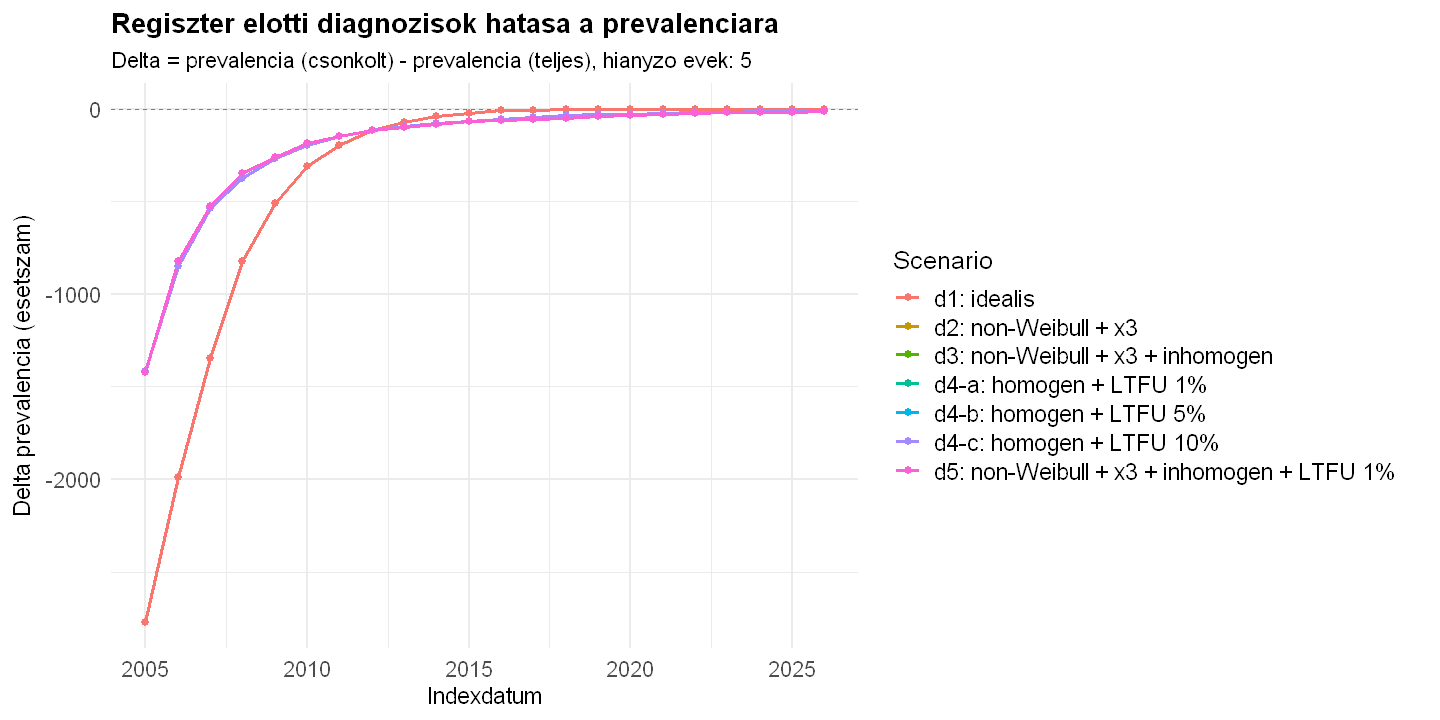

In [50]:
pre_registry_impact <- function(data_list, missing_years = 10, selected_datasets = names(data_list)) {
  # Idosoros abrazolashoz hasznalt plotmeret
  set_plot_size(analysis_config$plot_size$timeseries[1], analysis_config$plot_size$timeseries[2])

  # A kivalasztott scenariok egy kozos tablaba fuzese
  tab_all <- do.call(rbind, lapply(selected_datasets, function(nm) {
    df <- data_list[[nm]]

    d_diag <- as.Date(df$diagnosis_date_D)
    d_evt <- as.Date(df$true_event_date_F_true)
    d_fu <- as.Date(df$last_followup_date_F)
    cut_start <- as.Date(sprintf("%s-01-01", as.integer(format(min(d_diag, na.rm = TRUE), "%Y")) + missing_years))
    index_dates <- seq(cut_start, as.Date(sprintf("%s-01-01", format(max(d_fu, na.rm = TRUE), "%Y"))), by = "year")

    tab <- do.call(rbind, lapply(index_dates, function(idx) {
      prev_full <- sum(d_diag <= idx & d_evt > idx, na.rm = TRUE)
      prev_cut <- sum(d_diag >= cut_start & d_diag <= idx & d_evt > idx, na.rm = TRUE)
      data.frame(idx = idx, prev_full = prev_full, prev_cut = prev_cut, delta = prev_cut - prev_full)
    }))

    tab$scenario <- nm
    tab
  }))

  # Kozos abra a kivalasztott scenariokra
  p <- ggplot2::ggplot(tab_all, ggplot2::aes(x = idx, y = delta, color = scenario)) +
    ggplot2::geom_hline(yintercept = 0, linetype = "dashed", color = analysis_config$colors$neutral) +
    ggplot2::geom_line(linewidth = 1.1) +
    ggplot2::geom_point(size = 2) +
    notebook_theme(base_size = analysis_config$base_size$standard) +
    ggplot2::labs(
      title = "Regiszter elotti diagnozisok hatasa a prevalenciara",
      subtitle = paste0("Delta = prevalencia (csonkolt) - prevalencia (teljes), hianyzo evek: ", missing_years),
      x = "Indexdatum",
      y = "Delta prevalencia (esetszam)",
      color = "Scenario"
    )

  print(p)
  print(knitr::kable(tab_all, digits = 1))
  invisible(list(table = tab_all, plot = p))
}

# A vizsgalt scenariok kozos kiertekelese azonos vagasi szaballyal
pre_reg_impact_results <- pre_registry_impact(
  list(
    "d1: idealis" = df_eda_d1_idealis,
    "d2: non-Weibull + x3" = df_eda_d2_nonweibull_x3,
    "d3: non-Weibull + x3 + inhomogen" = df_eda_d3_nonweibull_x3_inhomogen,
    "d4-a: homogen + LTFU 1%" = df_eda_d4_a_homogen_ltfu_1,
    "d4-b: homogen + LTFU 5%" = df_eda_d4_b_homogen_ltfu_5,
    "d4-c: homogen + LTFU 10%" = df_eda_d4_c_homogen_ltfu_10,
    "d5: non-Weibull + x3 + inhomogen + LTFU 1%" = df_eda_d5_inhomogen_ltfu_1
  ),
  missing_years = 5,
  selected_datasets = c(
    "d1: idealis",
    "d2: non-Weibull + x3",
    "d3: non-Weibull + x3 + inhomogen",
    "d4-a: homogen + LTFU 1%",
    "d4-b: homogen + LTFU 5%",
    "d4-c: homogen + LTFU 10%",
    "d5: non-Weibull + x3 + inhomogen + LTFU 1%"
  )
)
# write.csv(pre_reg_impact_results$table, "prevalence_summary.csv", row.names = FALSE)


#### Prevalencia összegzése több indexdátumon és scenárión
- Indexdátum-sorozat képzése rögzített lépésközzel.
- A valós és megfigyelt prevalencia kiszámítása a szintetikus adathalmaz alapján minden scenárióra, több időhorizonton, majd az eredmények egy táblába fűzése.

In [51]:
# Indexdátumok képzése (rögzített hónaplépésközzel)
make_indexes <- function(start_date, end_date, step_months = 1) {
  seq.Date(as.Date(start_date), as.Date(end_date), by = paste(step_months, "months"))
}
index_date <- make_indexes("2010-01-01", "2020-01-01", 6)

# Prevalencia-számítási beállítások
population_size <- 10e3
num_years_to_estimate <- c(3, 5, 10)
print_big_tables <- TRUE

# Prevalencia összegzése scenáriónként, majd összevonás egy táblába
prevalence_summary_all <- do.call(
  rbind,
  lapply(names(synthetic_registry_list), function(nm) {
    x <- count_prevalence_at_index(
      synthetic_registry_list[[nm]],
      index_date = index_date,
      population_size = population_size,
      include_index_day = FALSE,
      num_years_to_estimate = num_years_to_estimate
    )
    x$scenario_id <- nm
    x
  })
)

# Táblázat megjelenítése (opcionális)
if (print_big_tables) print(prevalence_summary_all, row.names = FALSE)
# write.csv(prevalence_summary_all, "prevalence_summary.csv", row.names = FALSE)



|index_date | time_horizon_years|followup_basis | prevalent_cases| diagnosed_cases| prevalence_rate|scenario_id |
|:----------|------------------:|:--------------|---------------:|---------------:|---------------:|:-----------|
|2010-01-01 |                  3|true_F         |            2192|            2777|          0.2192|d1          |
|2010-01-01 |                  3|observed_F     |            2192|            2777|          0.2192|d1          |
|2010-01-01 |                  5|true_F         |            2767|            4776|          0.2767|d1          |
|2010-01-01 |                  5|observed_F     |            2767|            4776|          0.2767|d1          |
|2010-01-01 |                 10|true_F         |            3080|            9464|          0.3080|d1          |
|2010-01-01 |                 10|observed_F     |            3080|            9464|          0.3080|d1          |
|2010-07-01 |                  3|true_F         |            2195|            2799|   

#### `prevalence()` becslés futtatása több scenárióra
- A teljes szintetikus állományból képzett, csonkolt adatot regiszteradatként adjuk át a `prevalence()` függvénynek, így a regiszter indulása előtti, de az indexdátumon még prevalens esetek hiánya is megjelenik.
- A különböző generált adathalmazokon azonos indexdátumokon és időhorizontokon futtatjuk a becslést, majd az eredményt a teljes szintetikus állományból számolt referencia-prevalenciához viszonyítjuk.


In [52]:
# Minimális helyi definíciók, hogy ez a rövid cella önállóan is fusson
prep_prev_input_common <- function(df, missing_years = 10) {
  # A szintetikus állomány csonkolása és a prevalence() bemenetéhez szükséges mezők előállítása
  d <- as.Date(df$diagnosis_date_D)
  cut <- as.Date(sprintf("%04d-01-01", as.integer(format(min(d, na.rm = TRUE), "%Y")) + missing_years))
  x <- df[d >= cut, ]
  x$age <- x$covariate_scaled_x2
  x$time <- as.numeric(x$last_followup_date_F - x$diagnosis_date_D)
  x$status <- x$event_observed_delta
  x$covariate_hidden_x3 <- NULL
  x
}

# A futtatásba bevont szcenáriók
datasets_to_run <- intersect(names(synthetic_registry_list), c(
  "d1", "d2", "d3", "d4-a", "d4-b", "d4-c", "d5"
))

# Jelölt túlélési formulák és bootstrap-méretek
surv_formulas <- list(
  survival::Surv(time, status) ~ covariate_binary_x1 + age,
  survival::Surv(time, status) ~ age,
  survival::Surv(time, status) ~ covariate_binary_x1
)
boot_candidates <- c(200L, 100L, 50L, 20L)

# A prevalence() bemeneteinek előkészítése minden scenárióra
prev_input_list <- lapply(synthetic_registry_list, prep_prev_input_common, missing_years = 10)

# Kimeneti gyűjtő: prevalence() objektumok scenáriónként
prevalence_est_list <- setNames(vector("list", length(datasets_to_run)), datasets_to_run)

# Üres estimates-struktúra, ha egy illesztés sem sikerül
empty_est <- list(estimates = setNames(vector("list", length(num_years_to_estimate)), paste0("y", num_years_to_estimate)))

# Prevalenciabecslés futtatása minden scenárióra
for (nm in datasets_to_run) {
  d <- prev_input_list[[nm]]
  # Egyszerű szűrés a nyilván hibás sorok elhagyására
  d <- d[is.finite(d$time) & d$time > 0 & !is.na(d$status) & !is.na(d$age), ]

  cat("\n===", nm, "===\n")
  cat("Earliest Diag:", format(range(as.Date(d$diagnosis_date_D), na.rm = TRUE)), "\n")

  prev_fit <- NULL
  # Túlélési formulák és bootstrap-számok próbálása, amíg egy futás sikerül
  for (f in surv_formulas) {
    for (nb in boot_candidates) {
      prev_fit <- tryCatch(
        suppressWarnings(
          prevalence(
            index = index_date,
            num_years_to_estimate = num_years_to_estimate,
            data = d,
            inc_formula = diagnosis_date_D ~ 1,
            surv_formula = f,
            dist = "weibull",
            incident_column = "diagnosis_date_D",
            death_column = "last_followup_date_F",
            status_column = "status",
            age_column = "age",
            population_size = population_size,
            N_boot = nb
          )
        ),
        error = function(e) NULL
      )
      if (!is.null(prev_fit)) {
        cat("  surv_formula:", deparse(f), "| N_boot:", nb, "\n")
        break
      }
    }
    if (!is.null(prev_fit)) break
  }

  # Sikeres illesztés vagy üres helyettesítő objektum eltárolása
  prevalence_est_list[[nm]] <- if (is.null(prev_fit)) empty_est else prev_fit
  # A teljes prevalence()-kimenet kiíratása, ha ezt külön kértük
  if (print_big_tables && !is.null(prev_fit)) print(prev_fit)
}



=== d1 ===
Earliest Diag: 2010-01-01 2024-12-31 
  surv_formula: survival::Surv(time, status) ~ covariate_binary_x1 + age | N_boot: 200 
Estimated prevalence:
 index_date years absolute.prevalence  per100K per100K.upper per100K.lower
 2010-01-01     3             2256.40 22563.95      23488.46      21639.44
 2010-01-01     5             2827.09 28270.90      29368.79      27173.01
 2010-01-01    10             3124.93 31249.25      32444.45      30054.05
 2010-07-01     3             2247.26 22472.55      23750.99      21194.11
 2010-07-01     5             2819.80 28198.00      29620.96      26775.04
 2010-07-01    10             3116.49 31164.90      32694.40      29635.40
 2011-01-01     3             2307.85 23078.50      24430.80      21726.20
 2011-01-01     5             2880.64 28806.45      30306.85      27306.05
 2011-01-01    10             3175.88 31758.75      33358.66      30158.84
 2011-07-01     3             2261.59 22615.90      23897.37      21334.43
 2011-07-01    

#### Prevalencia-összegző tábla előállítása
- Az előző lépés becsléseit a teljes szintetikus állományból számolt valós, illetve a csonkolt regiszteradatból számolt megfigyelt prevalenciával közös összefoglaló táblába rendezzük.
- A táblában indexdátumonként és időhorizontonként kiszámítjuk a becslési eltéréseket abszolút és százalékos formában.


In [53]:
# Összesítő tábla: számlált és becsült prevalenciák összevetése
make_prevalence_summary_table <- function(prevalence_summary_all, prevalence_est_list, show_table = print_big_tables) {

  # Számlált prevalenciák: csak a szükséges oszlopok
  counted <- prevalence_summary_all[, c(
    "scenario_id", "index_date", "time_horizon_years", "followup_basis", "prevalent_cases"
  )]

  # Valós és megfigyelt prevalencia külön oszlopba rendezése
  counted_wide <- reshape(
    counted,
    idvar = c("scenario_id", "index_date", "time_horizon_years"),
    timevar = "followup_basis",
    direction = "wide"
  )
  names(counted_wide) <- sub("prevalent_cases.true_F", "true_prevalence", names(counted_wide), fixed = TRUE)
  names(counted_wide) <- sub("prevalent_cases.observed_F", "observed_prevalence", names(counted_wide), fixed = TRUE)

  # prevalence()-becslések kinyerése scenáriónként és horizontonként
  estimated_parts <- lapply(names(prevalence_est_list), function(nm) {
    est_obj <- prevalence_est_list[[nm]]$estimates
    do.call(rbind, lapply(names(est_obj), function(k) {
      x <- est_obj[[k]]
      if (is.null(x) || nrow(x) == 0) return(NULL)
      x$scenario_id <- nm
      x$time_horizon_years <- as.integer(gsub("[^0-9]", "", k))
      x
    }))
  })
  estimated_parts <- Filter(Negate(is.null), estimated_parts)
  if (length(estimated_parts) == 0) return(data.frame())

  estimated <- do.call(rbind, estimated_parts)

  # Becsült prevalencia és intervallumok egységes elnevezése
  estimated <- estimated[, c(
    "scenario_id", "index_date", "time_horizon_years",
    "absolute.prevalence", "per100K.lower", "per100K.upper"
  )]
  names(estimated) <- c(
    "scenario_id", "index_date", "time_horizon_years",
    "estimated_prevalence", "estimated_ci_lower", "estimated_ci_upper"
  )

  # Számlált és becsült prevalenciák összeillesztése
  summary_tbl <- merge(
    counted_wide,
    estimated,
    by = c("scenario_id", "index_date", "time_horizon_years"),
    all = FALSE
  )

  # Eltérések számítása abszolút és százalékos formában
  summary_tbl$delta_est_vs_observed <- summary_tbl$estimated_prevalence - summary_tbl$observed_prevalence
  summary_tbl$delta_est_vs_true <- summary_tbl$estimated_prevalence - summary_tbl$true_prevalence
  summary_tbl$delta_est_vs_observed_pct <- 100 * summary_tbl$delta_est_vs_observed / summary_tbl$observed_prevalence
  summary_tbl$delta_est_vs_true_pct <- 100 * summary_tbl$delta_est_vs_true / summary_tbl$true_prevalence

  # Rendezés és végső oszloprend
  summary_tbl <- summary_tbl[order(summary_tbl$scenario_id, summary_tbl$index_date, summary_tbl$time_horizon_years), ]
  summary_tbl <- summary_tbl[, c(
    "scenario_id", "index_date", "time_horizon_years",
    "true_prevalence", "observed_prevalence", "estimated_prevalence",
    "estimated_ci_lower", "estimated_ci_upper",
    "delta_est_vs_observed", "delta_est_vs_observed_pct",
    "delta_est_vs_true", "delta_est_vs_true_pct"
  )]

  # Tábla megjelenítése, ha ezt külön kértük
  if (show_table) print(knitr::kable(summary_tbl, digits = 2))

  summary_tbl
}

# Összegző tábla elkészítése az előző lépés becsléseiből
prevalence_comparison_tbl <- make_prevalence_summary_table(prevalence_summary_all, prevalence_est_list, show_table = print_big_tables)




|    |scenario_id |index_date | time_horizon_years| true_prevalence| observed_prevalence| estimated_prevalence| estimated_ci_lower| estimated_ci_upper| delta_est_vs_observed| delta_est_vs_observed_pct| delta_est_vs_true| delta_est_vs_true_pct|
|:---|:-----------|:----------|------------------:|---------------:|-------------------:|--------------------:|------------------:|------------------:|---------------------:|-------------------------:|-----------------:|---------------------:|
|2   |d1          |2010-01-01 |                  3|            2192|                2192|              2256.40|           21639.44|           23488.46|                 64.40|                      2.94|             64.40|                  2.94|
|3   |d1          |2010-01-01 |                  5|            2767|                2767|              2827.09|           27173.01|           29368.79|                 60.09|                      2.17|             60.09|                  2.17|
|1   |d1          |201

#### Indexdátumonkénti prevalencia-összevetés scenáriónként
- Az előző lépés összegző táblájára építve scenáriónként ábrázoljuk az egyes indexdátumokra számolt valós és becsült prevalenciát.
- Az ábrák nem ugyanazon esetek időbeli követését mutatják, hanem az indexdátumonként újraszámolt prevalenciák összevetését

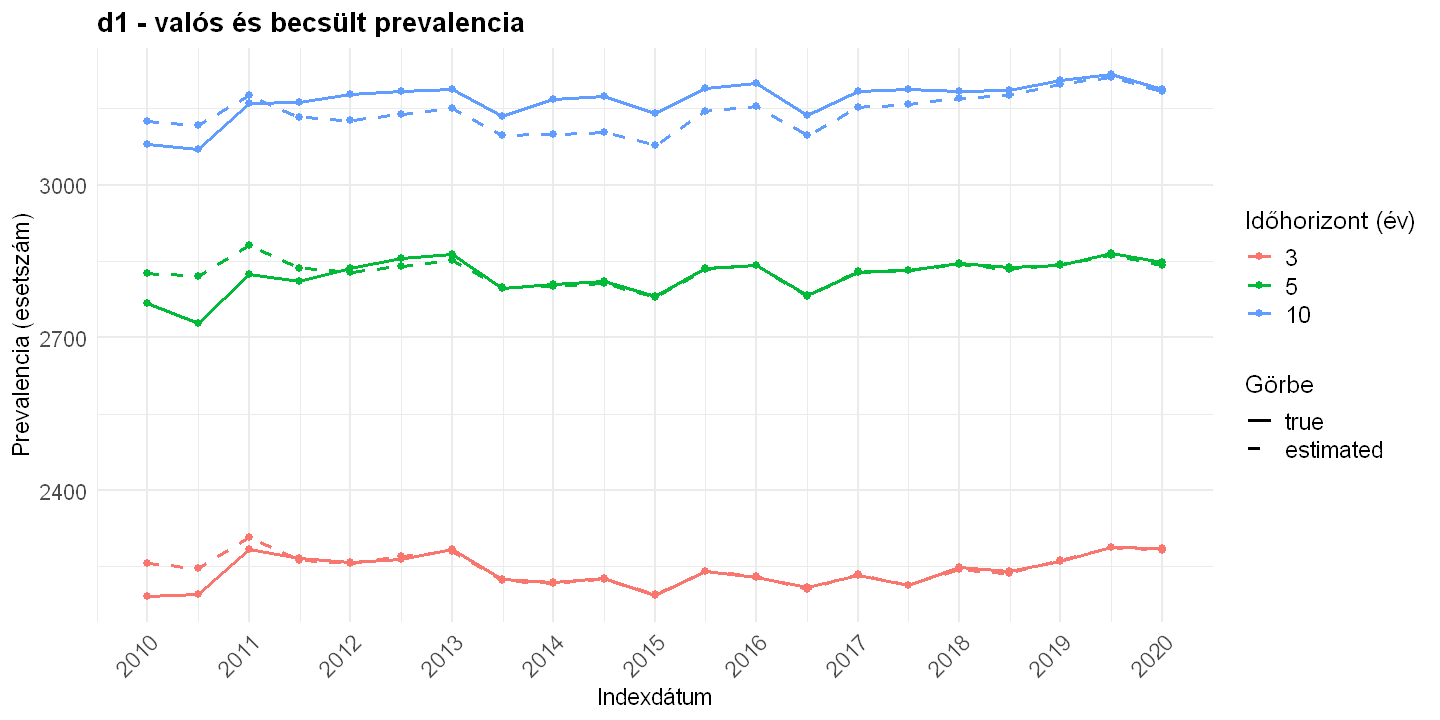

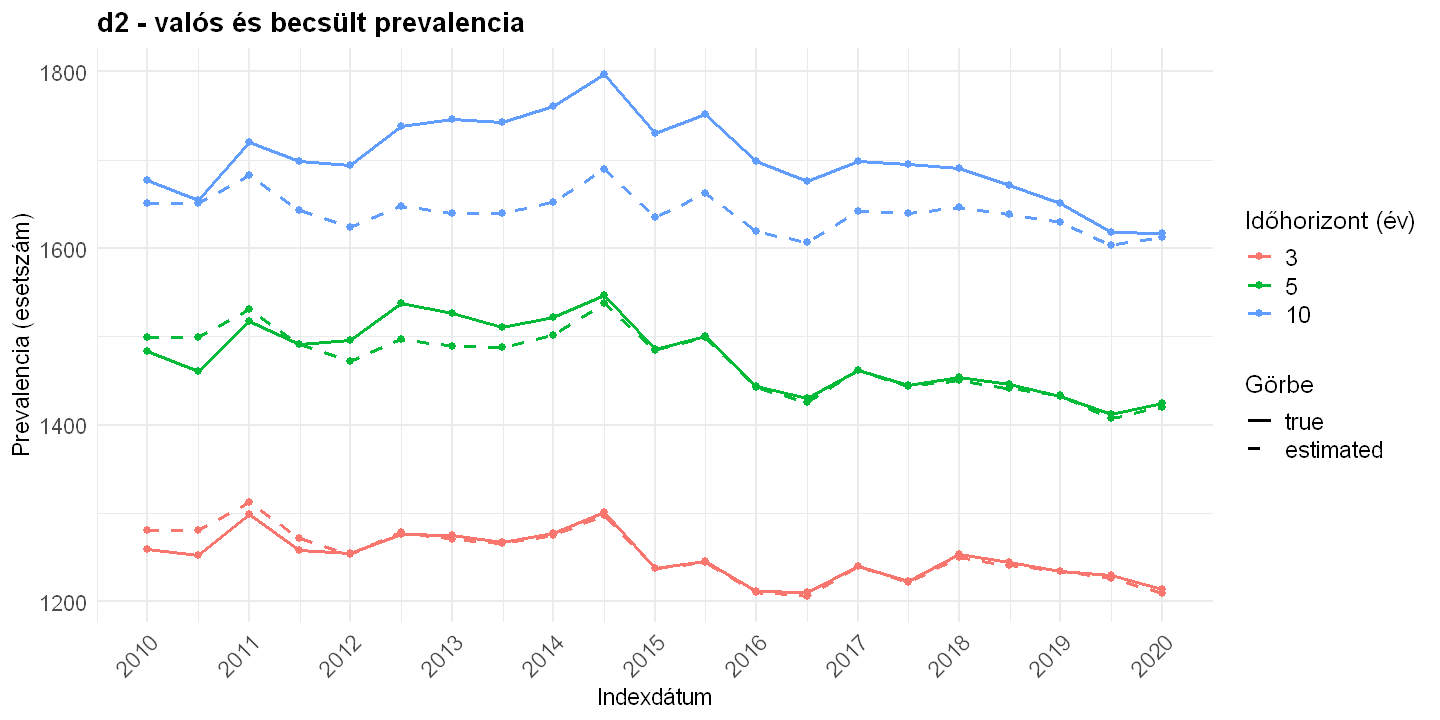

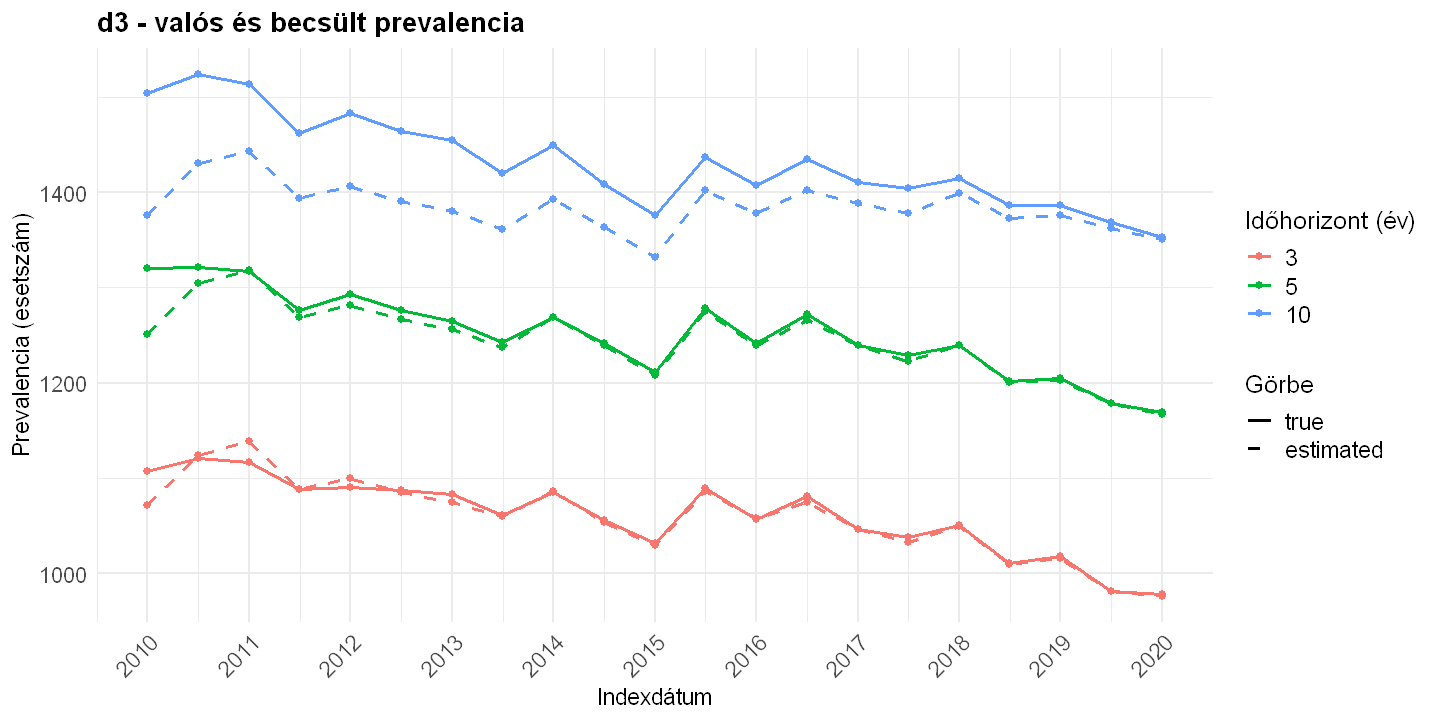

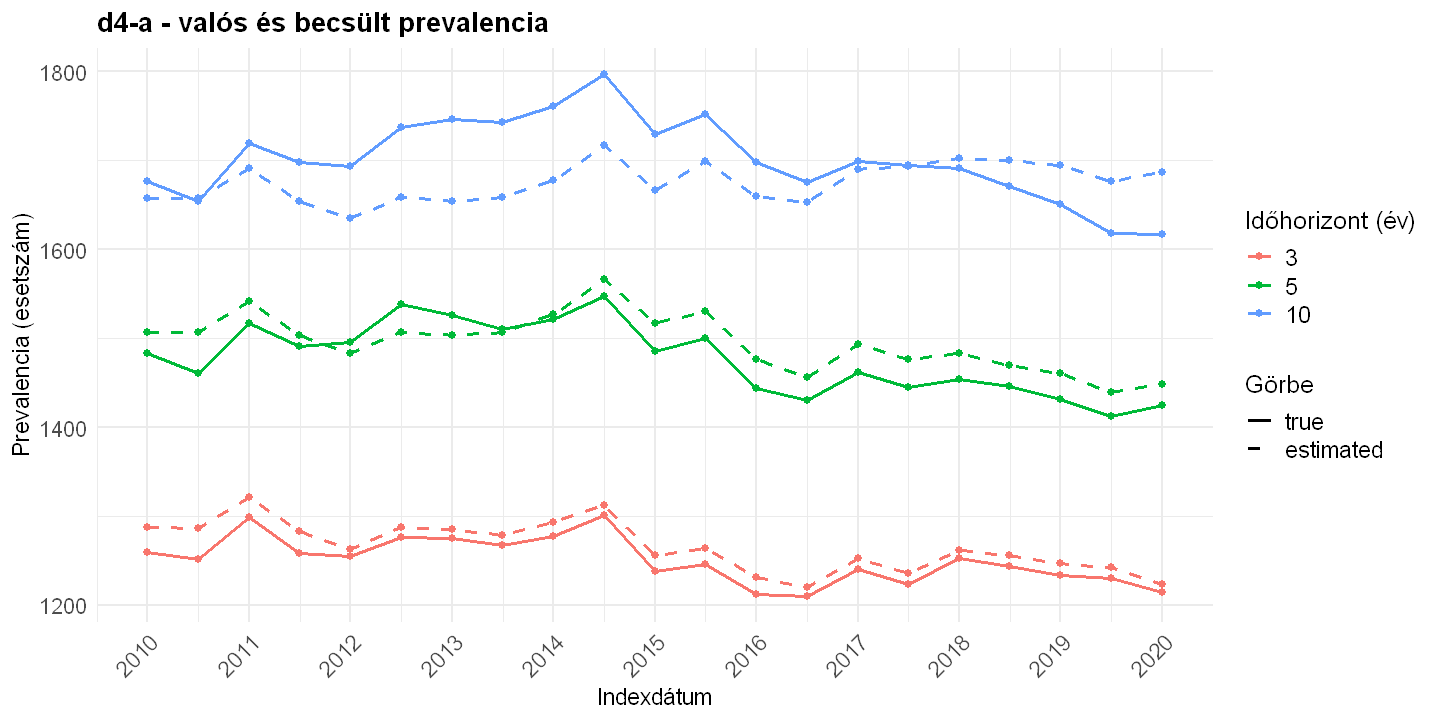

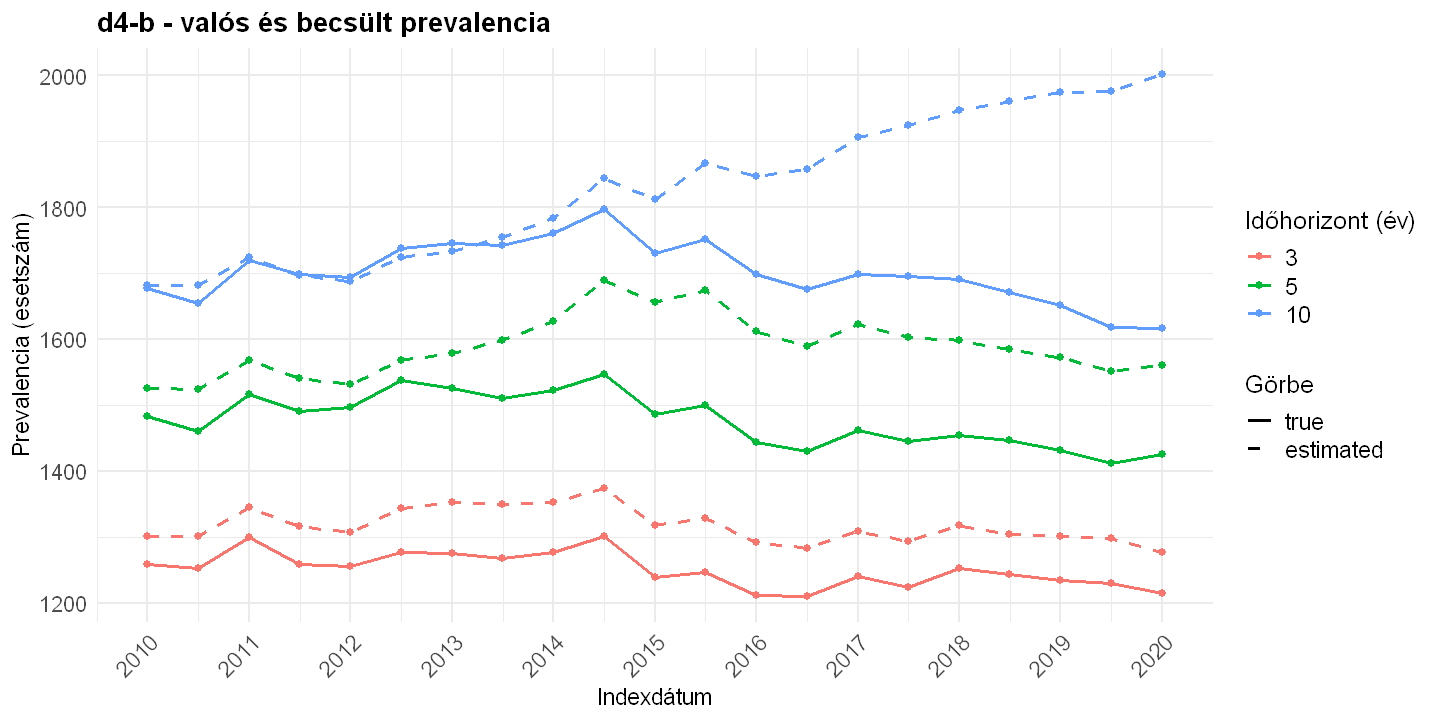

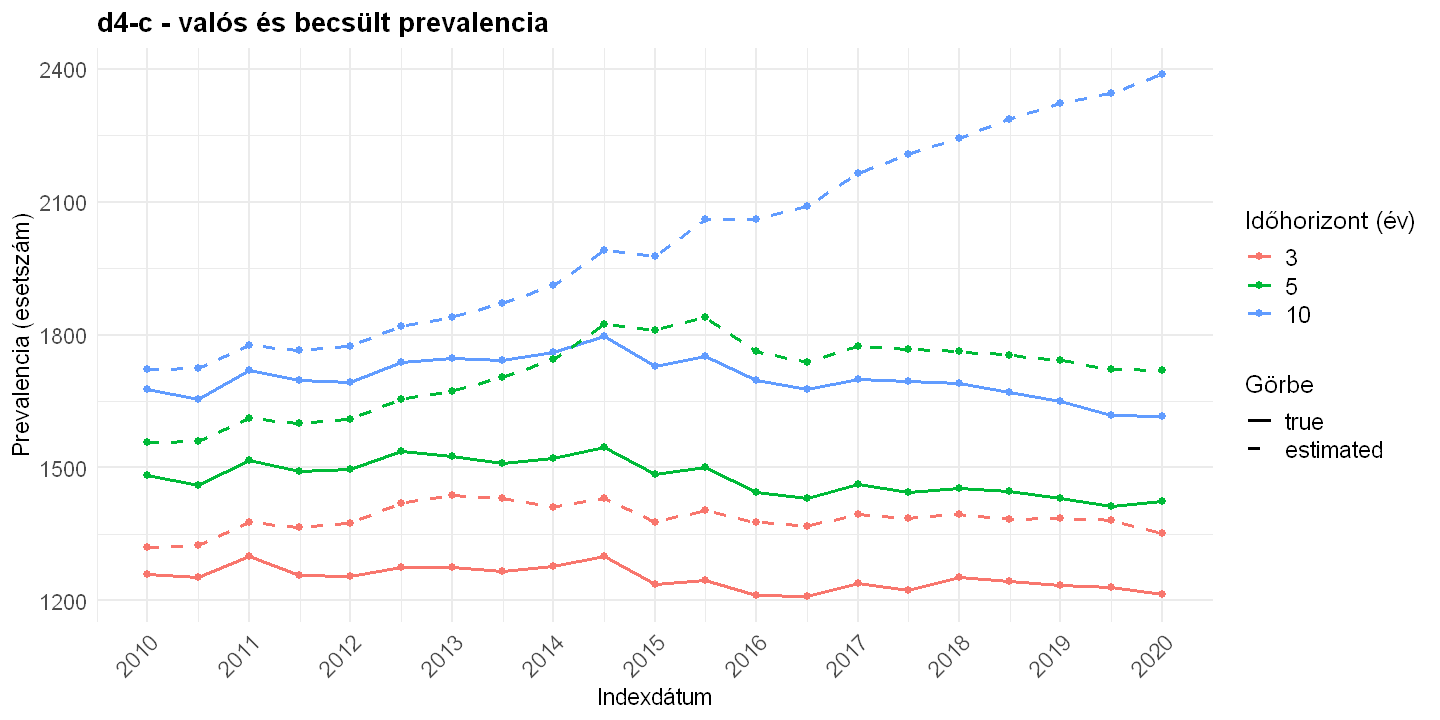

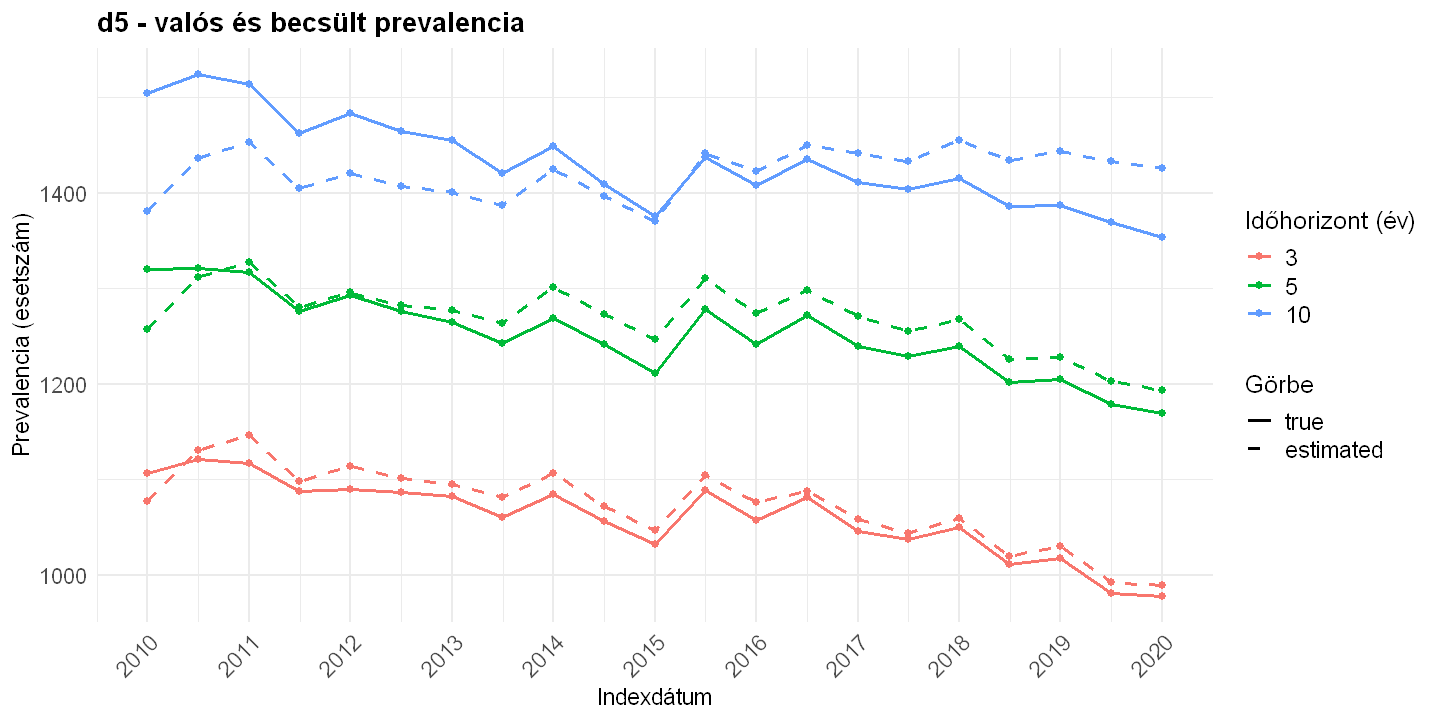

In [54]:
# Indexdátumonkénti prevalencia-összevető ábrák scenáriónként
plot_prevalence_lines_by_dataset <- function(summary_tbl) {

  # Ábrázolási tábla összeállítása a valós és becsült görbékhez
  n <- nrow(summary_tbl)
  plot_df <- data.frame(
    scenario_id = rep(summary_tbl$scenario_id, 2),
    index_date = rep(as.Date(summary_tbl$index_date), 2),
    time_horizon_years = factor(rep(summary_tbl$time_horizon_years, 2)),
    prevalence = c(summary_tbl$true_prevalence, summary_tbl$estimated_prevalence),
    curve_type = factor(rep(c("true", "estimated"), each = n), levels = c("true", "estimated"))
  )

  # Scenáriónkénti szeletelés és ábrák előállítása
  split_df <- split(plot_df, plot_df$scenario_id)

  out <- lapply(names(split_df), function(scn) {
    d <- split_df[[scn]]

    # Egy scenárió valós és becsült prevalenciagörbéi
    p <- ggplot2::ggplot(
      d,
      ggplot2::aes(
        x = index_date,
        y = prevalence,
        color = time_horizon_years,
        linetype = curve_type,
        group = interaction(time_horizon_years, curve_type)
      )
    ) +
      ggplot2::geom_line(linewidth = 1) +
      ggplot2::geom_point(size = 2) +
      ggplot2::scale_x_date(date_breaks = "1 year", date_labels = "%Y") +
      ggplot2::scale_linetype_manual(values = c("true" = "solid", "estimated" = "dashed")) +
      notebook_theme(base_size = analysis_config$base_size$small) +
      ggplot2::theme(axis.text.x = ggplot2::element_text(size = analysis_config$text_size$axis_text, angle = 45, hjust = 1)) +
      ggplot2::labs(
        title = paste0(scn, " - valós és becsült prevalencia"),
        x = "Indexdátum",
        y = "Prevalencia (esetszám)",
        color = "Időhorizont (év)",
        linetype = "Görbe"
      )

    # Ábra megjelenítése és eltárolása
    print(p)
    p
  })

  # Ábrák visszaadása scenáriónévenként
  names(out) <- names(split_df)
  out
}

# Ábrák előállítása az összegző táblából
prevalence_dataset_plots <- plot_prevalence_lines_by_dataset(prevalence_comparison_tbl)

#### Gördülőablakos validálás a `prevalence()` becslésére
- A kiértékelés célja annak mérése, hogy a `prevalence()` módszer milyen pontossággal becsli a prevalenciát abban a helyzetben, amikor csak korlátozott megfigyelési idejű regiszteradat áll rendelkezésre.
- A megbízható következtetés érdekében a pontosságot nem egyetlen időpontra, hanem több egymást követő indexdátumra értékeljük.
- Az összevethetőség biztosítására az indexdátum-sorozat minden eleméhez külön részregisztert képezünk, és az adott időpontnál minden számítást kizárólag ezen a rész-adathalmazon végzünk.
- A részregisztereket úgy definiáljuk, hogy a megfigyelési ablak hossza minden indexpontban azonos legyen: a részregiszter kezdete és vége az indexdátumhoz képest rögzített eltolással adódik, így az eredmények egységes feltételrendszer mellett állnak elő.
- Minden indexdátumnál ugyanazt az eljárást követjük: a részregiszter alapján újraillesztjük az incidenciamodellt és a túlélési modellt, majd ezekből állítjuk elő a prevalenciabecslést az előre rögzített időhorizontokon.
- Ugyanarra az időpontra két mennyiséget számolunk:
  - (i) a referencia-prevalenciát a teljes (szintetikus) regiszterállományból,
  - (ii) az adott részregiszterre épülő becslést, amely a megfigyelt esetekre illesztett modellek és a szimulált incidens populáció kombinációjából származik.
- A teljesítményt a d1-d7 scenáriónként hibamutatókkal (MAE, RMSE, MBE, MAPE), valamint a felül- és alulbecslés gyakoriságával foglaljuk össze

- Segédfüggvények: dátumeltolás években, valamint a (regiszterkezdet, indexdátum) párok előállítása az adott lépésközzel.

In [55]:
# Dátumeltolás években
add_years <- function(d, y) {
  lt <- as.POSIXlt(as.Date(d))
  lt$year <- lt$year + y
  as.Date(lt)
}
sub_years <- function(d, y) add_years(d, -y)

# (regiszterkezdet, indexdátum) párok képzése
make_registry_schedule <- function(registry_start_first, registry_end_date, observed_years, step = "month") {
  by <- if (step == "week") "1 week" else if (step == "month") "1 month" else step

  start_last <- sub_years(as.Date(registry_end_date), observed_years)
  registry_starts <- seq.Date(as.Date(registry_start_first), start_last, by = by)
  index_dates <- as.Date(
    sapply(registry_starts, function(s) as.numeric(add_years(s, observed_years))),
    origin = "1970-01-01"
  )

  list(registry_starts = registry_starts, index_dates = index_dates)
}

- Segédfüggvények: `prevalence()` bemenet előállítása és a `prevalence()` illesztés futtatása jelölt formulák/bootstrappal.

In [56]:
# prevalence() bemenet előállítása (megfigyelt követési idő + státusz + életkor + x3 kizárás)
prep_prev_input <- function(df_reg) {
  d <- df_reg
  d$age <- d$covariate_scaled_x2
  d$time <- as.numeric(d$last_followup_date_F - d$diagnosis_date_D)
  d$status <- d$event_observed_delta
  d$covariate_hidden_x3 <- NULL
  d
}

# prevalence() futtatása: túlélési formula és N_boot jelöltek próbálása
fit_prevalence_with_fallback <- function(d, idx, horizon_years, population_size, dist,
                                        surv_formulas, boot_candidates, reg_start) {
  prev_obj <- NULL
  for (f in surv_formulas) {
    for (nb in boot_candidates) {
      prev_obj <- tryCatch(
        suppressWarnings(
          prevalence(
            index = idx,
            num_years_to_estimate = horizon_years,
            data = d,
            inc_formula = diagnosis_date_D ~ 1,
            surv_formula = f,
            dist = dist,
            registry_start_date = reg_start,
            incident_column = "diagnosis_date_D",
            death_column = "last_followup_date_F",
            status_column = "status",
            age_column = "age",
            population_size = population_size,
            N_boot = nb
          )
        ),
        error = function(e) NULL
      )
      if (!is.null(prev_obj)) break
    }
    if (!is.null(prev_obj)) break
  }
  prev_obj
}

- Fő függvény: indexdátumonként részregiszter-képzés, referencia- és becsült prevalencia összevetése, majd hibamutatók előállítása.

In [57]:
# Metrics-only, rövidített gördülőablakos kiértékelés
rolling_backtest_metrics_only <- function(
  df_full,
  scenario_id,
  horizon_years = 10,
  observed_years = 3,
  registry_start_first = "2010-01-01",
  registry_end_date = "2020-01-01",
  step = "month",
  population_size = 10e3,
  N_boot = 50,
  dist = "weibull"
) {
  horizon_years <- sort(unique(as.integer(horizon_years)))

  # Indexdátumok és regiszterkezdetek előállítása
  sch <- make_registry_schedule(registry_start_first, registry_end_date, observed_years, step)
  registry_starts <- sch$registry_starts
  index_dates <- sch$index_dates

  # Jelölt túlélési formulák és bootstrap-méretek
  surv_formulas <- list(
    survival::Surv(time, status) ~ covariate_binary_x1 + age,
    survival::Surv(time, status) ~ age,
    survival::Surv(time, status) ~ covariate_binary_x1
  )
  boot_candidates <- unique(c(as.integer(N_boot), 50L, 20L, 10L))

  # Gyűjtők: becslések és számlált prevalenciasorok
  est_acc <- setNames(vector("list", length(horizon_years)), paste0("y", horizon_years))
  counted_rows <- list()

  for (i in seq_along(index_dates)) {
    reg_start <- registry_starts[i]
    idx <- index_dates[i]

    # Részregiszter képzése diagnózisdátum alapján
    d_diag <- as.Date(df_full$diagnosis_date_D)
    df_reg <- df_full[d_diag >= reg_start & d_diag <= idx, ]

    # Referencia-prevalencia a teljes állományból, valós követés alapján
    true_rows <- count_prevalence_at_index(
      df_full, index_date = idx, population_size = population_size,
      include_index_day = FALSE, num_years_to_estimate = horizon_years
    )
    true_rows <- true_rows[true_rows$followup_basis == "true_F", ]

    # Megfigyelt prevalencia a részregiszterből, megfigyelt követés alapján
    obs_rows <- count_prevalence_at_index(
      df_reg, index_date = idx, population_size = population_size,
      include_index_day = FALSE, num_years_to_estimate = horizon_years
    )
    obs_rows <- obs_rows[obs_rows$followup_basis == "observed_F", ]

    # Számlált sorok eltárolása
    counted_step <- rbind(true_rows, obs_rows)
    counted_step$scenario_id <- scenario_id
    counted_rows[[length(counted_rows) + 1]] <- counted_step

    # prevalence() bemenet előállítása és alap szűrés
    d <- prep_prev_input(df_reg)
    d <- d[is.finite(d$time) & d$time > 0 & !is.na(d$status) & !is.na(d$age), ]
    if (nrow(d) < 10 || length(unique(d$status)) < 2) next

    # prevalence() illesztés az adott indexdátumra
    prev_obj <- fit_prevalence_with_fallback(
      d = d, idx = idx, horizon_years = horizon_years,
      population_size = population_size, dist = dist,
      surv_formulas = surv_formulas, boot_candidates = boot_candidates,
      reg_start = reg_start
    )
    if (is.null(prev_obj)) next

    # Becslések akkumulálása időhorizontonként
    for (k in names(est_acc)) {
      x <- prev_obj$estimates[[k]]
      est_acc[[k]] <- if (is.null(est_acc[[k]])) x else rbind(est_acc[[k]], x)
    }
  }

  # Számlált prevalenciák összevonása a teljes indexdátum-sorozatra
  prevalence_summary_roll <- do.call(rbind, counted_rows)

  # A prevalence() becslések csomagolása az összegző táblához
  prevalence_est_list <- list()
  prevalence_est_list[[scenario_id]] <- list(estimates = est_acc)

  # Valós, megfigyelt és becsült prevalenciák összeillesztése
  cmp <- make_prevalence_summary_table(prevalence_summary_roll, prevalence_est_list, show_table = FALSE)

  # Hibatábla és metrikák előállítása időhorizontonként
  err <- cmp
  if (nrow(err) == 0) {
    return(data.frame(
      scenario_id = scenario_id,
      time_horizon_years = as.integer(horizon_years[1]),
      mae_est_vs_true = NA_real_,
      rmse_est_vs_true = NA_real_,
      mbe_est_vs_true = NA_real_,
      mape_est_vs_true = NA_real_,
      over_rate_pct = NA_real_,
      under_rate_pct = NA_real_
    ))
  }

  # Védőlépés: hiányzó időhorizont oszlop pótlása
  if (!"time_horizon_years" %in% names(err)) {
    err$time_horizon_years <- rep(as.integer(horizon_years[1]), nrow(err))
  }

  # Hiba- és segédmennyiségek előállítása
  err$err_est_vs_true <- err$estimated_prevalence - err$true_prevalence
  err$abs_err_est_vs_true <- abs(err$err_est_vs_true)
  err$sq_err_est_vs_true <- err$err_est_vs_true^2
  err$abs_pct_err_est_vs_true <- 100 * err$abs_err_est_vs_true / ifelse(err$true_prevalence == 0, NA, err$true_prevalence)
  err$over_flag <- as.numeric(err$err_est_vs_true > 0)
  err$under_flag <- as.numeric(err$err_est_vs_true < 0)

  # Metrikák aggregálása scenárió és időhorizont szerint
  metrics_tbl <- aggregate(
    cbind(
      mae_est_vs_true = abs_err_est_vs_true,
      rmse_sq = sq_err_est_vs_true,
      mbe_est_vs_true = err_est_vs_true,
      mape_est_vs_true = abs_pct_err_est_vs_true,
      over_rate_pct = over_flag,
      under_rate_pct = under_flag
    ) ~ scenario_id + time_horizon_years,
    data = err,
    FUN = function(z) mean(z, na.rm = TRUE)
  )

  # RMSE és arányok végső skálázása
  metrics_tbl$rmse_est_vs_true <- sqrt(metrics_tbl$rmse_sq)
  metrics_tbl$over_rate_pct <- 100 * metrics_tbl$over_rate_pct
  metrics_tbl$under_rate_pct <- 100 * metrics_tbl$under_rate_pct

  # Kimeneti oszloprend és részletes hibasorok
  metrics_tbl <- metrics_tbl[, c(
    "scenario_id", "time_horizon_years",
    "mae_est_vs_true", "rmse_est_vs_true", "mbe_est_vs_true", "mape_est_vs_true",
    "over_rate_pct", "under_rate_pct"
  )]

  error_paths <- err[, c(
    "scenario_id", "index_date", "time_horizon_years",
    "true_prevalence", "estimated_prevalence", "err_est_vs_true"
  )]

  list(metrics = metrics_tbl, error_paths = error_paths)
}

- Wrapper: a fenti metrika-számítás lefuttatása minden scenárióra, majd a sorok összevonása egy táblába.

In [58]:
rolling_backtest_metrics_only_all <- function(data_list, ...) {
  # Név nélküli lista esetén automatikus scenárióazonosítók
  if (is.null(names(data_list)) || any(names(data_list) == "")) {
    names(data_list) <- paste0("dataset_", seq_along(data_list))
  }

  # Scenáriónkénti futtatás és eredmények gyűjtése
  out <- lapply(names(data_list), function(nm) {
    rolling_backtest_metrics_only(df_full = data_list[[nm]], scenario_id = nm, ...)
  })

  # Scenáriók eredményeinek összevonása
  metrics_out <- do.call(rbind, lapply(out, function(x) x$metrics))
  error_out <- do.call(rbind, lapply(out, function(x) x$error_paths))
  rownames(metrics_out) <- NULL
  rownames(error_out) <- NULL
  list(metrics = metrics_out, error_paths = error_out)
}

- Példafuttatás: scenáriónkénti metrika-tábla előállítása a megadott paraméterezéssel.

In [59]:
# Példafuttatás: metrika-tábla előállítása a d1–d7 scenáriókra
bt_roll <- rolling_backtest_metrics_only_all(
  data_list = synthetic_registry_list,
  horizon_years = 10,
  observed_years = 3,
  registry_start_first = "2010-01-01",
  registry_end_date = "2020-01-01",
  step = "month",
  population_size = population_size,
  N_boot = 500,
  dist = "weibull"
)

bt_metrics_only <- bt_roll$metrics
bt_error_paths <- bt_roll$error_paths
bt_error_plot_10y <- subset(bt_error_paths, time_horizon_years == 10)
bt_error_plot_10y$scenario_label <- factor(bt_error_plot_10y$scenario_id, levels = c("d1", "d2", "d3", "d4-a", "d4-b", "d4-c", "d5"), labels = c("d1: idealis", "d2: non-Weibull + x3", "d3: non-Weibull + x3 + inhomogen", "d4: homogen + LTFU 1%", "d4: homogen + LTFU 5%", "d4: homogen + LTFU 10%", "d5: non-Weibull + x3 + inhomogen + LTFU 1%"))

bt_metrics_only

scenario_id,time_horizon_years,mae_est_vs_true,rmse_est_vs_true,mbe_est_vs_true,mape_est_vs_true,over_rate_pct,under_rate_pct
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
d1,10,62.66400,66.87739,-62.66400,1.971866,0.000000,100.00000
d2,10,74.07835,81.58092,-74.07835,4.330591,0.000000,100.00000
d3,10,37.85506,52.34099,-29.90941,2.726648,32.941176,67.05882
d4-a,10,57.23694,66.42830,-57.16776,3.340260,3.529412,96.47059
d4-b,10,30.35059,38.75088,15.41859,1.781584,62.352941,37.64706
d4-c,10,113.73741,119.09544,113.73741,6.691043,100.000000,0.00000
d5,10,37.58388,46.19733,-12.86200,2.696499,52.941176,47.05882


#### Illeszkedésvizsgálat: incidenciamodell
- A default incidenciamodell feltevése homogén Poisson-folyamat.
- Itt a `test_homogeneity()` beépített diagnosztikával ellenőrizzük, hogy a csonkolt regiszteradat éves incidenciája mennyire egyeztethető össze ezzel a feltevéssel.
- Az összegzés mellett az `rprev` incidenciadiagnosztikai ábráját is megjelenítjük.

#### Illeszkedésvizsgálat: túlélési modell
- A túlélési oldal ellenőrzéséhez a kiválasztott `prevalence()` objektumból származó bootstrapolt túlélési modelleket használjuk.
- A `validate_survival_model()` a modell technikai megfelelőségét és monotonitását ellenőrzi, a `survfit()` pedig az átlagos kovariánsértékek melletti bootstrapolt túlélési görbét adja vissza.
- Az összegzés és az ábra a túlélési modellek variabilitásának gyors ellenőrzését szolgálja.


#### Az illeszkedésvizsgálatok rövid értelmezése
- Az incidenciaoldali `test_homogeneity()` eredm?nyei a `d1_idealis` ?s `d2_referencia` scen?ri?kban a homog?n Poisson-feltev?ssel ?sszeegyeztethet? mint?zatot adnak. A `d3_referencia_LTFU`, `d4_inhomogen`, `d5_inhomogen_LTFU_5`, `d6_inhomogen_LTFU_10` ?s `d7_inhomogen_LTFU_1_rep` esetekben ezzel szemben az id?ben inhomog?n gener?l?si szerkezet jelenik meg.
- A túlélési oldalon a bootstrapolt túlélési görbék jól elkülönítik a négy scenáriót. A `d1_idealis` egyszerűbb, jól specifikált helyzetet képvisel, a `d2_referencia` és `d3_referencia_LTFU` a nem tökéletes túlélési specifikációt, míg a `d4_inhomogen` esetben az incidenciaoldali eltérés is megjelenik. Ez összhangban van azzal, hogy a szcenáriók között a generálási mechanizmus szándékosan eltér.
- Az `Incidenciamodell-validáció hiba` és `Túlélési modell validációs hiba` üzenetek nem az adatok módszertani értelmezésére, hanem az `rprev` belső validációs függvényeinek technikai hibájára utalnak többosztályú objektumok esetén. A diagnosztikai ábrák és összegzések ettől még lefutnak, ezért az érdemi értelmezést a `test_homogeneity()` és a `survfit()` kimeneteire érdemes alapozni.


### Gördülőablakos hibaábra
A \(10\) éves horizontra kapott becslési hiba indexdátum szerinti alakulása a `bt_error_plot_10y` objektum alapján.

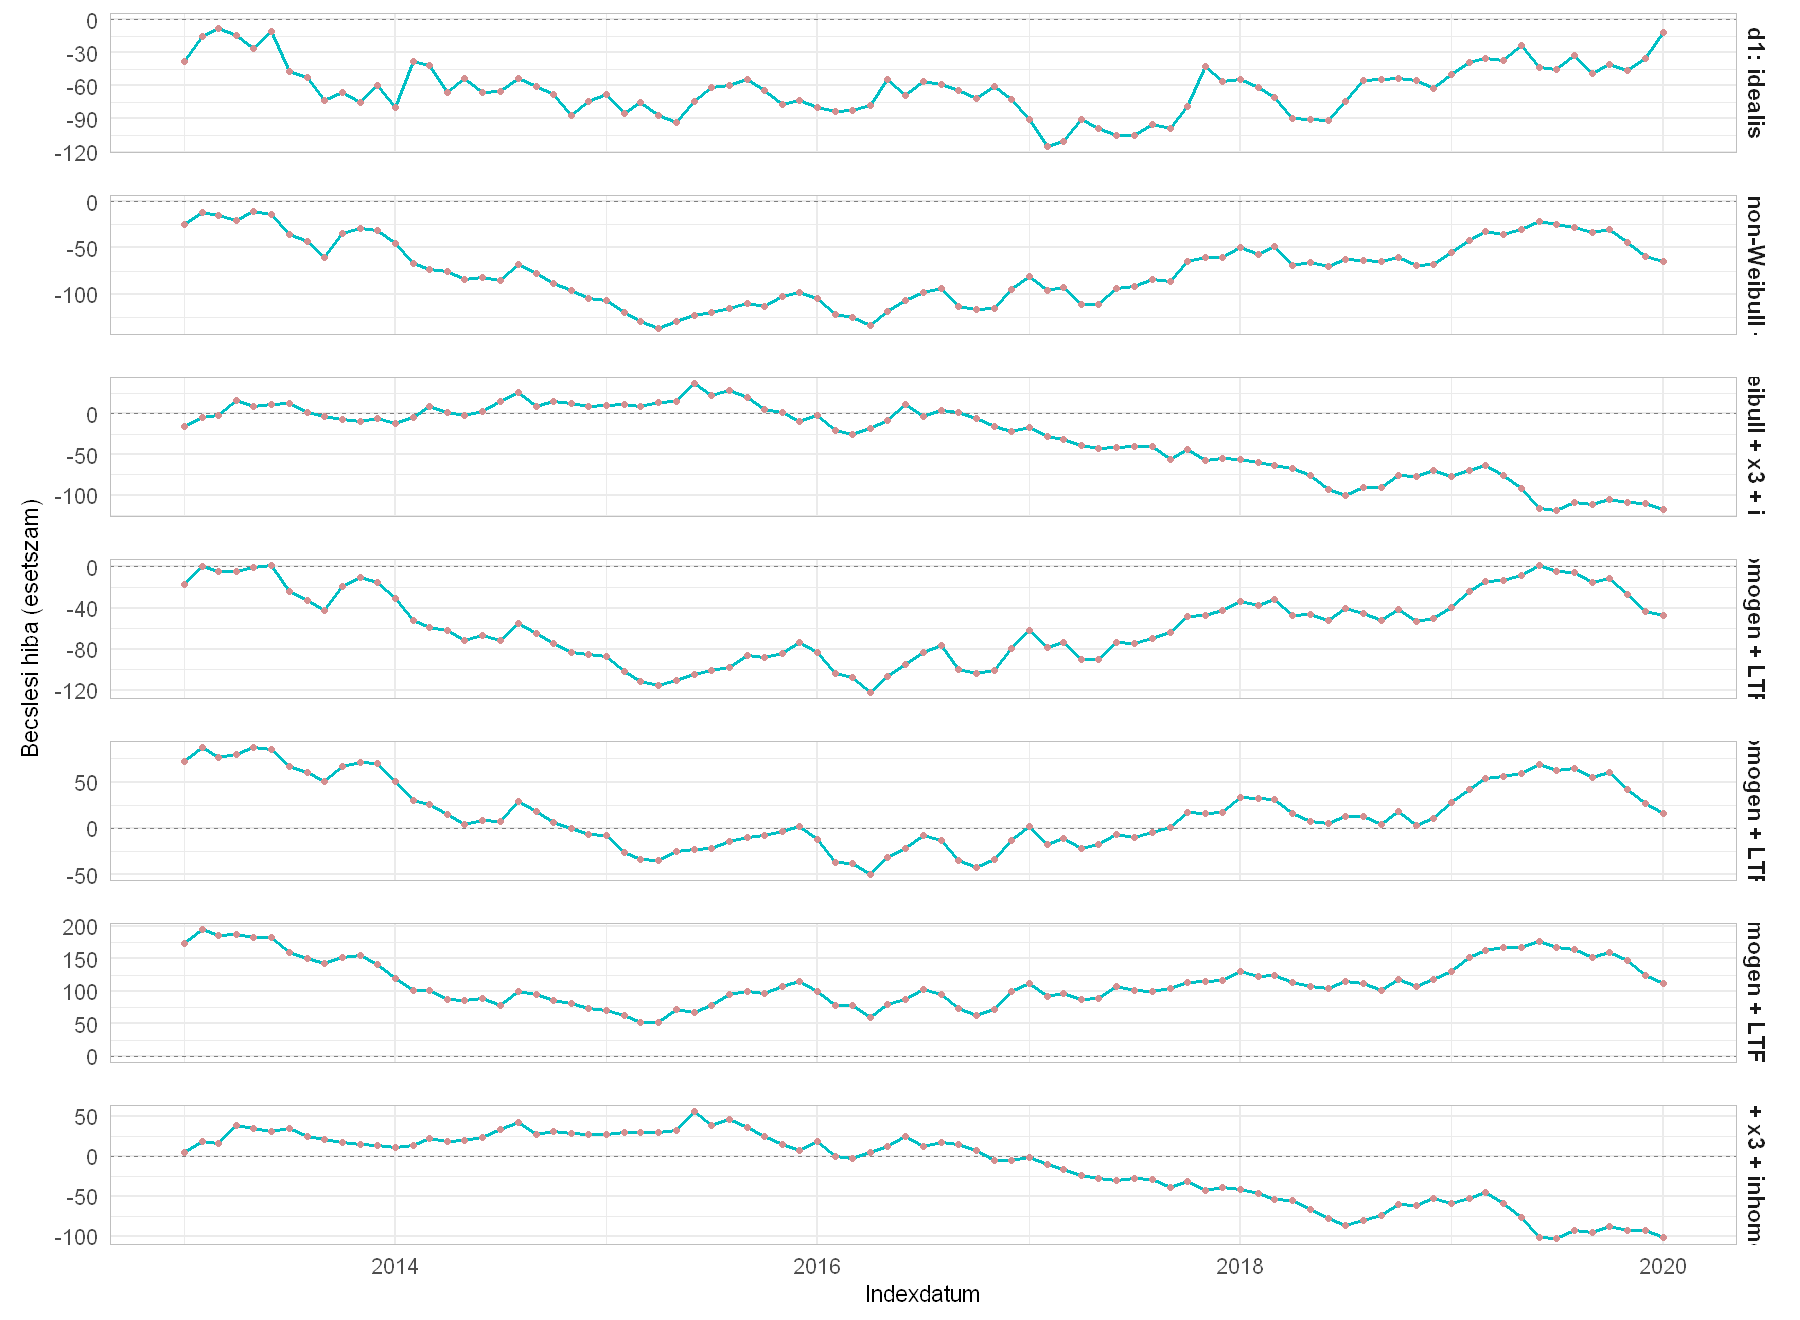

In [60]:
set_plot_size(15, 11)
ggplot2::ggplot(bt_error_plot_10y, ggplot2::aes(index_date, err_est_vs_true)) +
  ggplot2::geom_hline(yintercept = 0, linetype = "dashed", color = analysis_config$colors$neutral) +
  ggplot2::geom_line(color = analysis_config$colors$main, linewidth = 0.9) +
  ggplot2::geom_point(color = analysis_config$colors$alt, size = 1.5) +
  ggplot2::facet_grid(scenario_label ~ ., scales = "free_y") +
  ggplot2::labs(x = "Indexdatum", y = "Becslesi hiba (esetszam)") +
  notebook_theme(base_size = 16) +
  ggplot2::theme(panel.spacing.y = grid::unit(0.9, "cm"), panel.border = ggplot2::element_rect(color = "grey75", fill = NA, linewidth = 0.5), strip.background = ggplot2::element_blank(), strip.text.y = ggplot2::element_text(size = 14, face = "bold"), plot.margin = ggplot2::margin(8, 12, 8, 12))

`geom_smooth()` using formula = 'y ~ x'


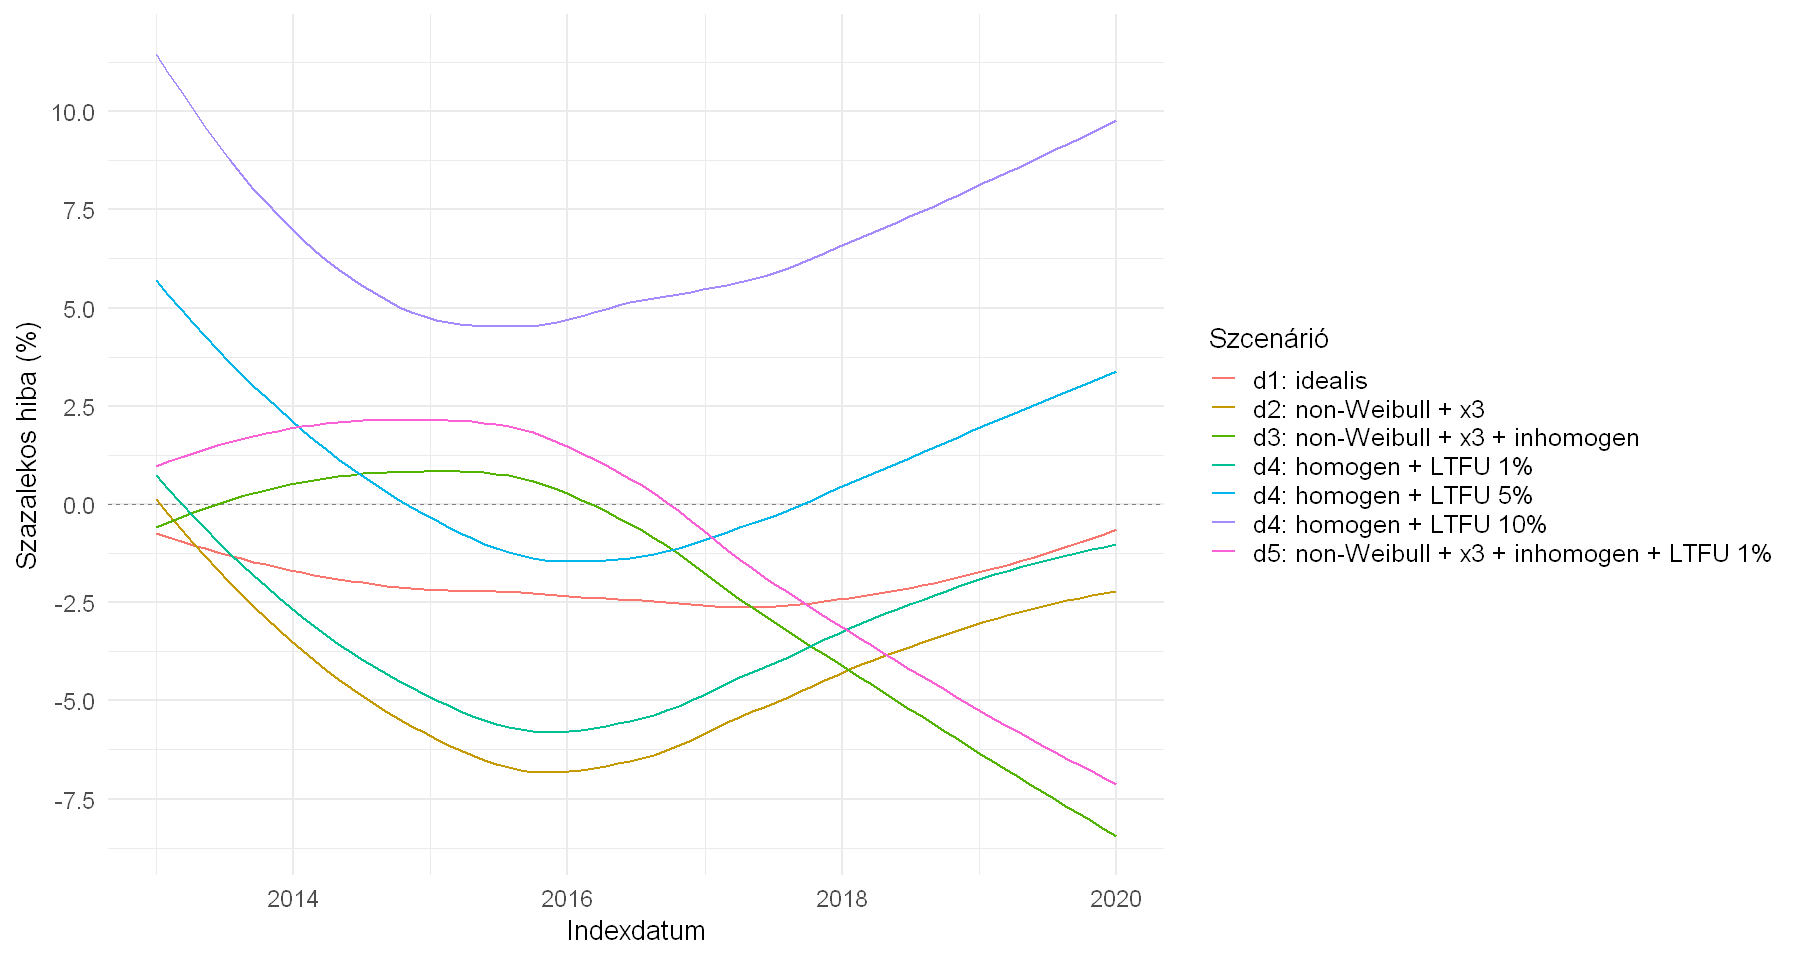

In [69]:
plot_mode <- "loess"  # "raw", "both", "loess"
datasets_to_plot <- c(
  "d1: idealis",
  "d2: non-Weibull + x3",
  "d3: non-Weibull + x3 + inhomogen",
  "d4: homogen + LTFU 1%",
  "d4: homogen + LTFU 5%",
  "d4: homogen + LTFU 10%",
  "d5: non-Weibull + x3 + inhomogen + LTFU 1%"
)

plot_df_pct <- bt_error_plot_10y
plot_df_pct$pct_err <- 100 * plot_df_pct$err_est_vs_true / plot_df_pct$true_prevalence
plot_df_pct <- plot_df_pct[plot_df_pct$scenario_label %in% datasets_to_plot, ]
plot_df_pct$scenario_label <- factor(plot_df_pct$scenario_label, levels = datasets_to_plot)

set_plot_size(15, 8)
p <- ggplot2::ggplot(plot_df_pct, ggplot2::aes(index_date, pct_err, color = scenario_label, group = scenario_label)) +
  ggplot2::geom_hline(yintercept = 0, linetype = "dashed", color = analysis_config$colors$neutral) +
  ggplot2::scale_y_continuous(n.breaks = 10) +
  ggplot2::labs(x = "Indexdatum", y = "Szazalekos hiba (%)", color = "Szcenárió") +
  notebook_theme(base_size = 18) +
  ggplot2::theme(legend.title = ggplot2::element_text(size = 16), legend.text = ggplot2::element_text(size = 15), axis.title = ggplot2::element_text(size = 16), axis.text = ggplot2::element_text(size = 14))

if (plot_mode %in% c("raw", "both")) {
  p <- p + ggplot2::geom_line(linewidth = 0.9) + ggplot2::geom_point(size = 1.6)
}

if (plot_mode %in% c("loess", "both")) {
  p <- p + ggplot2::geom_smooth(se = FALSE, method = "loess", linewidth = 0.6, linetype = "solid")
}

p

# értelmezés